# Load files

In [1]:
import json

with open("../CSVs/relations_final.json", "r") as f:
    relations = json.load(f)
print(len(relations))

360026


In [2]:
count = 0
for k, v in relations.items():
    count += 1
    if 10 < count and count < 20: 
        print(k, v)

@CHEMICAL_Phytol|Association|@CHEMICAL_Vitamin_K_1 {'r1': 'D010836', 'r2': 'D010837', 'type': 'Association', 'r1accession': '@CHEMICAL_Phytol', 'r2accession': '@CHEMICAL_Vitamin_K_1', 'pmids': ['38124486'], 'score': ['0.9721'], 'id': ['@CHEMICAL_Phytol', 'Association', '@CHEMICAL_Vitamin_K_1']}
@CHEMICAL_Homogentisic_Acid|Positive_Correlation|@CHEMICAL_Tocotrienols {'r1': 'D006713', 'r2': 'D024508', 'type': 'Positive_Correlation', 'r1accession': '@CHEMICAL_Homogentisic_Acid', 'r2accession': '@CHEMICAL_Tocotrienols', 'pmids': ['38124486'], 'score': ['0.7383'], 'id': ['@CHEMICAL_Homogentisic_Acid', 'Positive_Correlation', '@CHEMICAL_Tocotrienols']}
@CHEMICAL_Chlorophyll|Positive_Correlation|@CHEMICAL_Phytol {'r1': 'D002734', 'r2': 'D010836', 'type': 'Positive_Correlation', 'r1accession': '@CHEMICAL_Chlorophyll', 'r2accession': '@CHEMICAL_Phytol', 'pmids': ['40082754'], 'score': ['0.8202']}
@CHEMICAL_Tocopherols|Association|@GENE_VTE5 {'r1': 'D024505', 'r2': 830328, 'type': 'Association',

In [3]:
with open("../CSVs/entities_final.json", "r") as fe:
    entities = json.load(fe)
print(len(entities))

68702


In [4]:
count = 0
for k, v in entities.items():
    count += 1
    if count < 10: 
        print(k, v)

D001471 {'id': 'D001471', 'name': 'Barrett Esophagus', 'type': 'disease', 'pmids': ['40716632'], 'accession': '@DISEASE_Barrett_Esophagus', 'subtype': 'unknown', 'gene_ids': 'unknown'}
D000782 {'id': 'D000782', 'name': 'Aneuploidy', 'type': 'disease', 'pmids': ['40488668'], 'accession': '@DISEASE_Aneuploidy', 'subtype': 'unknown', 'gene_ids': 'unknown'}
C005072 {'id': 'C005072', 'name': '5-doxylstearic acid', 'type': 'chemical', 'pmids': ['40895728'], 'accession': '@CHEMICAL_5_doxylstearic_acid', 'subtype': 'unknown', 'gene_ids': 'unknown'}
D008228 {'id': 'D008228', 'name': 'Lymphoma Non-Hodgkin', 'type': 'disease', 'pmids': ['40484291', '40927528', '40654923', '40461678', '36572783', '40393126', '16930780', '39800921'], 'accession': '@DISEASE_Lymphoma_Non_Hodgkin', 'subtype': 'unknown', 'gene_ids': 'unknown'}
D015792 {'id': 'D015792', 'name': 'Retinal Dysplasia', 'type': 'disease', 'pmids': ['38621974', '40792210', '38612746'], 'accession': '@DISEASE_Retinal_Dysplasia', 'subtype': 'un

# Build extended graph

In [5]:
def prepareForVisualization(entitydict, relationdict):
    refinedrelations = dict()
    unique_relationtypes = set()
    unique_entitytypes = set()
    genesWithVariants = set()

    for trip, rel in relationdict.items():
        # print(rel) 
        r1 = (rel['r1'])
        r2 = (rel['r2'])
        rtype = rel['type']

        
        if not r1 or not r2:
            continue
        unique_relationtypes.add(rtype)
        
        r1main, r1gene, r1type = None, None, None
        try: 
            r1main = entitydict[str(r1)]['accession']
            if r1main == 'None' or r1main == None:
                continue
            r1type = entitydict[str(r1)]['type']
        except:
            print("Cannot find {} in list entities".format(r1))

        if not r1main or not r1type:
            continue

        if '#' in str(r1): # case of variant 
            try:
                r1geneid = str(entitydict[r1]['gene_ids'][0])
                r1gene = entitydict[r1geneid]['accession']
                if r1gene == 'None' or r1gene == None:
                    continue
                r1genetype = entitydict[r1geneid]['type']
                # unique_entitytypes.add(r1genetype)
                # print("Found gene {} associated with variant {}".format(r1geneid, r1main))
            except:
                print("Cannot find gene {} associated with variant {} in list entities".format(r1geneid, r1main))

        r2main, r2gene, r2type = None, None, None 
        try:
            r2main = entitydict[str(r2)]['accession']
            if r2main == 'None' or r2main == None:
                continue
            r2type = entitydict[str(r2)]['type']
        except:
            print("Cannot find {} in list entities".format(r2))
        
        if not r2main or not r2type:
            continue
        
        if "#" in str(r2): # in case of variant  
            try: 
                r2geneid = str(entitydict[r2]['gene_ids'][0])
                r2gene = entitydict[r2geneid]['accession']
                if r2gene == None or r2gene == 'None':
                    continue
                r2genetype = entitydict[r2geneid]['type']
                # unique_entitytypes.add(r2genetype)
                # print("Found gene {} associated with variant {}".format(r2geneid, r2main))
            except:
                print("Cannot find gene {} associated with variant {} in list entities".format(r2geneid, r2main))

        
        
        if r1gene: 
            r1main = r1gene
            r1type = r1genetype
        if r2gene:
            r2main = r2gene
            r2type = r2genetype 

        unique_entitytypes.add(r1type)
        unique_entitytypes.add(r2type)

        triplet = (r1main, rtype, r2main)

        scores = rel['score']
        scores = [float(x) for x in scores if float(x) <= 1.0]
        ascore = sum(scores)/len(scores)
        # scorecount  = len(scores)

        if triplet not in refinedrelations:
            # print(triplet)
            refinedrelations[triplet] = {
                'confidence': ascore,
                'pmid_count': len(rel['pmids']),
                'r1type': r1type,
                'r2type': r2type,
                'pmids': set(rel['pmids'])
            }
        else:
            refinedrelations[triplet]['pmids'] = refinedrelations[triplet]['pmids'].union(set(rel['pmids']))
            refinedrelations[triplet]['pmid_count'] = len(refinedrelations[triplet]['pmids'])
            refinedrelations[triplet]['confidence'] = ((refinedrelations[triplet]['confidence'])*len(refinedrelations[triplet]['pmids']) + \
                                                  ascore*len(scores))/(len(refinedrelations[triplet]['pmids']) + len(scores))
            # print("Append {} to set {}".format(rel['pmids'], refinedrelations[triplet]['pmids']))
            # refinedrelations[triplet]['score'] = (refinedrelations[triplet]['score'] + ascore)/2  # average score

        
        # if r1gene:
        #     genesWithVariants.add(r1gene)
        #     r1genetriplet = (r1gene, rtype, r2main)
        #     if r1genetriplet not in refinedrelations:
        #         refinedrelations[r1genetriplet] = {
        #             'score': ascore,
        #             'pmids': set(rel['pmids']), # originally a set 
        #             'r1type': r1genetype,
        #             'r2type': r2type
        #         }
        #     else:
        #         refinedrelations[r1genetriplet]['pmids'] = refinedrelations[r1genetriplet]['pmids'].union(set(rel['pmids']))
        #         # print("Append {} to set {}".format(rel['pmids'], refinedrelations[r1genetriplet]['pmids']))
        #         # refinedrelations[r1genetriplet]['score'] = (refinedrelations[r1genetriplet]['score'] + ascore)/2  # average score

        # if r2gene:
        #     genesWithVariants.add(r2gene)
        #     r2genetriple = (r1main, rtype, r2gene)
        #     if r2genetriple not in refinedrelations:
        #         refinedrelations[r2genetriple] = {
        #             'score': ascore,
        #             'pmids': set(rel['pmids']), # originally a set 
        #             'r1type': r1type,
        #             'r2type': r2genetype
        #         }
        #     else: 
        #         refinedrelations[r2genetriple]['pmids'] = refinedrelations[r2genetriple]['pmids'].union(set(rel['pmids']))
        #         # print("Append {} to set {}".format(rel['pmids'], refinedrelations[r2genetriple]['pmids']))
        #         # refinedrelations[r2genetriple]['score'] = (refinedrelations[r2genetriple]['score'] + ascore)/2  # average score



    # for pairid, pairinfo in refinedrelations.items():
    #     print(pairid)
    #     print(pairinfo['score'])
    #     print(pairinfo['pmids'])
    #     print(pairinfo['r1type'], pairinfo['r2type'])
        # print("="*50)
        
    print(unique_relationtypes)
    print(unique_entitytypes)

    return refinedrelations, unique_entitytypes, unique_relationtypes, genesWithVariants

In [6]:
refinedrelations, unique_entitytypes, unique_relationtypes, genesWithVariants = prepareForVisualization(entities, relations)

Cannot find 28913 in list entities
Cannot find 825516 in list entities
Cannot find 53902 in list entities
Cannot find 53901 in list entities
Cannot find 53901 in list entities
Cannot find 53901 in list entities
Cannot find 53901 in list entities
Cannot find 53902 in list entities
Cannot find 53902 in list entities
Cannot find 53902 in list entities
Cannot find 6200 in list entities
Cannot find 100358676 in list entities
Cannot find gene 22941 associated with variant @VARIANT_rs117985268 in list entities
Cannot find gene 22941 associated with variant @VARIANT_rs117985268 in list entities
Cannot find 22941 in list entities
Cannot find 22941 in list entities
Cannot find 170744 in list entities
Cannot find gene u associated with variant @VARIANT_rs11190870 in list entities
Cannot find 28927 in list entities
Cannot find 6124 in list entities
Cannot find gene 339622 associated with variant @VARIANT_rs928264 in list entities
Cannot find gene 339622 associated with variant @VARIANT_rs928264 in

In [7]:
print(len(refinedrelations))

347798


In [8]:
count = 0
for rel, data in refinedrelations.items():
    if '@CHEMICAL_Homogentisic_Acid' in rel and '@DISEASE_Alkaptonuria' in rel:
        print(rel, data)

('@CHEMICAL_Homogentisic_Acid', 'Association', '@DISEASE_Alkaptonuria') {'confidence': 0.8084896226415097, 'pmid_count': 106, 'r1type': 'chemical', 'r2type': 'disease', 'pmids': {'37354891', '27414279', '34504318', '13770605', '16788736', '25233259', '2758664', '24876668', '9056215', '35550814', '19085367', '16085442', '39351877', '16476288', '37404676', '16901704', '30341892', '1813514', '5559277', '10771134', '1647170', '25772318', '20726204', '20952450', '32822600', '34714010', '36684325', '29997987', '23430917', '17664775', '32642830', '35822095', '25733348', '38487984', '405402', '32348369', '2746590', '8188247', '32970271', '23085206', '8071207', '16078090', '31296884', '7821069', '17044384', '33452825', '39273071', '3731474', '31228435', '34941093', '36985595', '39769171', '2914385', '35152492', '37025736', '36465977', '39836193', '21308630', '9870204', '32395409', '2383921', '33344320', '25182962', '2835867', '39312502', '21876398', '24206226', '3810644', '40430165', '39435171'

In [9]:
unique_relationtypes.add("Multitype")

In [10]:
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import networkx as nx

def construct_relation_graph_with_legend(relation_dict, entity_types, relation_types, threshold, genesWithVariants=None):
    """
    Build a NetworkX graph from relation_dict with safe, consistent attributes.

    - Edge attribute 'rel_types' is a set of relation types (no 'type' name clash).
    - Edge attribute 'pmidlist' is a set of string PMIDs; 'pmid_count' is its size.
    - When the same edge appears again, PMIDs and rel_types are merged; 'confident' is averaged weighted by new PMIDs.
    - Keeps a special '@DISEASE_Alkaptonuria' node, and returns the connected component containing it.
    """

    G = nx.Graph()

    # Color maps
    cmap_entities = cm.get_cmap('tab20b', len(entity_types))
    cmap_relations = cm.get_cmap('Dark2', len(relation_types))

    entity_color_map = {
        etype: mcolors.to_hex(cmap_entities(i))
        for i, etype in enumerate(sorted(entity_types))
    }
    relation_color_map = {
        rtype: mcolors.to_hex(cmap_relations(i))
        for i, rtype in enumerate(sorted(relation_types))
    }

    # Color for multitype edges
    multitype_rgba = mcolors.to_rgba(relation_color_map.get("Multitype", "#000000"))
    mr, mg, mb = [int(c * 255) for c in multitype_rgba[:3]]
    multitype_edge_color_str = f"rgba({mr},{mg},{mb})"

    # Safe membership set for genes with variants
    has_var = set(genesWithVariants) if genesWithVariants else set()

    # Seed disease node
    G.add_node(
        '@DISEASE_Alkaptonuria',
        label='@DISEASE_Alkaptonuria',
        size=30,
        color=entity_color_map.get("disease", "#ff0000")
    )

    for (e1, rel_type, e2), data in relation_dict.items():
        # Basic guards
        if not e1 or not e2:
            continue
        if rel_type in {"Comparison", "None", None}:
            continue

        # Scores / PMIDs
        conf_score = float(data.get("confidence", 0.0))
        pmids = list(data.get("pmids", {}))  # could be set/list
        str_pmids = set(str(p) for p in pmids)
        if not str_pmids:
            continue

        # Entity types for node coloring
        type1 = data.get("r1type", "Unknown")
        type2 = data.get("r2type", "Unknown")

        # Edge color for this relation
        rr, rg, rb = [int(c * 255) for c in mcolors.to_rgba(relation_color_map.get(rel_type, "#000000"))[:3]]
        rgb_str = f"rgba({rr},{rg},{rb})"

        # Threshold logic
        if conf_score > threshold or (len(pmids) >= 3 and conf_score >= 0.5):

            # Ensure nodes exist with attributes
            if e1 not in G:
                if e1 in has_var:
                    G.add_node(e1, label=e1, size=15, type=type1, color=entity_color_map.get(type1, "#999999"))
                else:
                    G.add_node(e1, label=e1, type=type1, color=entity_color_map.get(type1, "#999999"))

            if e2 not in G:
                if e2 in has_var:
                    G.add_node(e2, label=e2, size=15, type=type2, color=entity_color_map.get(type2, "#999999"))
                else:
                    G.add_node(e2, label=e2, type=type2, color=entity_color_map.get(type2, "#999999"))

            if G.has_edge(e1, e2):
                # Merge PMIDs
                existing_pmids = set(G[e1][e2].get('pmidlist', set()))
                oldlen = len(existing_pmids)
                existing_pmids.update(str_pmids)
                G[e1][e2]['pmidlist'] = existing_pmids
                G[e1][e2]['pmid_count'] = len(existing_pmids)

                # Weighted average of confidence by new PMIDs count
                existing_conf = float(G[e1][e2].get('confident', 0.0))
                newlen = len(str_pmids)
                denom = max(oldlen + newlen, 1)
                ave_conf = (existing_conf * oldlen + conf_score * newlen) / denom
                G[e1][e2]['confident'] = ave_conf

                # Merge relation types
                oldrels = set(G[e1][e2].get('rel_types', set()))
                if rel_type not in oldrels:
                    oldrels.add(rel_type)
                    G[e1][e2]['rel_types'] = oldrels
                    G[e1][e2]['color'] = multitype_edge_color_str  # visually mark multitype

                # Recompute weight from merged PMID count
                G[e1][e2]['score'] = 1 - 2 ** (-(len(existing_pmids)))

            else:
                # New edge
                pmidcount = len(str_pmids)
                weight = 1 - 2 ** (-(pmidcount))
                G.add_edge(
                    e1, e2,
                    rel_types={rel_type},
                    score=weight,
                    confident=conf_score,
                    pmid_count=pmidcount,
                    pmidlist=set(str_pmids),
                    color=rgb_str
                )

    # Keep only the component containing the disease node
    if '@DISEASE_Alkaptonuria' in G:
        comp_nodes = nx.node_connected_component(G, '@DISEASE_Alkaptonuria')
        G = G.subgraph(comp_nodes).copy()

    return G, entity_color_map, relation_color_map


In [11]:
extendGraph, entity_color, relation_color = construct_relation_graph_with_legend(refinedrelations, unique_entitytypes, unique_relationtypes, 0.7, genesWithVariants)
print(extendGraph)

/var/folders/01/v0p4sfw945j32p3yvg67p6cc0000gn/T/ipykernel_27313/786236193.py:18: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap_entities = cm.get_cmap('tab20b', len(entity_types))
/var/folders/01/v0p4sfw945j32p3yvg67p6cc0000gn/T/ipykernel_27313/786236193.py:19: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap_relations = cm.get_cmap('Dark2', len(relation_types))


Graph with 27926 nodes and 283983 edges


In [ ]:
from pyvis.network import Network

def pyvis_subgraph_html(Gsub, fname, entity_color_map, relation_color_map, max_nodes=3000, max_edges=30000):
    H = Gsub.copy()

    # If still too big, slice by degree
    if H.number_of_nodes() > max_nodes:
        deg = dict(H.degree())
        keep_nodes = set(sorted(deg, key=deg.get, reverse=True)[:max_nodes])
        H = H.subgraph(keep_nodes).copy()

    # If still too many edges, keep top edges by (deg(u)+deg(v))
    if H.number_of_edges() > max_edges:
        deg = dict(H.degree())
        edges_sorted = sorted(H.edges(), key=lambda e: deg[e[0]]+deg[e[1]], reverse=True)[:max_edges]
        H = H.edge_subgraph(edges_sorted).copy()

    # Compute positions once and fix physics
    pos = nx.spring_layout(H, k=0.3, iterations=200, seed=42)

    net = Network(height="1960px", width="100%", notebook=False, directed=False)
    for n, d in H.nodes(data=True):
        x, y = pos[n]
        net.add_node(n,
                     label=str(d.get("label", n)) if len(str(n)) < 40 else str(n)[:37]+"…",
                     title=str(d),
                     x=float(x*1000), y=float(y*1000), physics=False)
        

    for u, v, d in H.edges(data=True):
        net.add_edge(u, v, title=str(d))
    
    for e in net.edges:
        rel = Gsub[e['from']][e['to']]['rel_types']
        weight = Gsub[e['from']][e['to']]['score']
        pmid_list = Gsub[e['from']][e['to']]['pmidlist']
        numpmid = Gsub[e['from']][e['to']]['pmid_count']
        e['title'] = f"{rel} \n weight: {weight:.2f} \n {numpmid} PMIDs: {pmid_list}"
        e['color'] = Gsub[e['from']][e['to']]['color']

    for n in net.nodes:
        node_data = Gsub.nodes[n['id']]
        n['color'] = node_data.get('color', '#999')
        n['title'] = f"Type: {node_data.get('type', 'Unknown')}"

    net.set_options("""
    var options = {
      "physics": { "enabled": false },
      "nodes": { "shape": "dot", "scaling": { "min": 1, "max": 20 } },
      "edges": { "smoothArithmeticError": false }
    }
    """)
    net.write_html(fname)
    # Inject a legend block manually
    with open(fname, "r", encoding="utf-8") as f:
        html = f.read()

    # Build legend HTML
    def dot(color):
        return f'<span style="display:inline-block;width:12px;height:12px;border-radius:6px;background:{color};margin-right:6px;"></span>'

    legend_html = "<div style='position:absolute;top:10px;right:10px;background:white;padding:10px;border:1px solid #ccc;border-radius:5px;font-family:sans-serif;font-size:14px;'>"
    legend_html += "<b>Legend</b><br><br><u>Entity Types:</u><br>"
    for etype, color in entity_color_map.items():
        legend_html += f"{dot(color)} {etype}<br>"

    legend_html += "<br><u>Relation Types:</u><br>"
    for rtype, color in relation_color_map.items():
        legend_html += f"{dot(color)} {rtype}<br>"

    legend_html += "</div>"

    # Inject just before closing </body> tag
    html = html.replace("</body>", legend_html + "\n</body>")

    # Save modified file
    with open(fname, "w", encoding="utf-8") as f:
        f.write(html)

    print(f"Graph with legend saved to {fname}")

In [ ]:
center = "@DISEASE_Alkaptonuria"
radius = 1
ego = nx.ego_graph(extendGraph, center, radius=radius)
print(ego)
pyvis_subgraph_html(ego, "../HTMLs/ego_alcaptonuria_r1.html", entity_color, relation_color, max_nodes=4000, max_edges=40000)


In [12]:
import networkx as nx
from pyvis.network import Network

def visualize_communitilized(G): # pass your full graph (undirected)

    # Communities (no extra deps)
    comms = list(nx.algorithms.community.greedy_modularity_communities(G))
    comm_id = {n:i for i,c in enumerate(comms) for n in c}
    print(f"Found {len(comm_id)} communities")

    # Build community-level graph (nodes=communities, edge weight=cross edges count)
    C = nx.Graph()
    C.add_nodes_from(range(len(comms)))
    for u,v in G.edges():
        cu, cv = comm_id[u], comm_id[v]
        if cu != cv:
            C.add_edge(cu, cv, weight=C.get_edge_data(cu, cv, {}).get('weight', 0) + 1)

    # PyVis (small, fast)
    netC = Network(height="800px", width="100%", notebook=False, directed=False)
    for i, c in enumerate(comms):
        netC.add_node(i, label=f"Comm {i} (n={len(c)})", title=f"{len(c)} nodes")

    for u,v,d in C.edges(data=True):
        netC.add_edge(u, v, value=float(d.get("weight", 1)))

    netC.set_options("""
    var options = {
    physics: { enabled: false, barnesHut: { gravitationalConstant: -30000, springLength: 120 } },
    nodes: { shape: "dot", scaling: { min: 3, max: 30 } },
    edges: { smooth: false }
    }
    """)
    netC.write_html("overview_communities.html")


In [ ]:
from pyvis.network import Network
import networkx as nx
import matplotlib.colors as mcolors

def _to_color_str(c):
    # Accept hex like "#aabbcc" or rgba tuple and return a string
    if isinstance(c, str):
        return c
    try:
        # e.g., (r,g,b,a) floats 0..1 or ints 0..255
        rgba = list(c)
        if all(isinstance(x, (int, float)) for x in rgba):
            # normalize to 0..255 ints
            if max(rgba) <= 1.0:
                rgba = [int(round(x*255)) for x in rgba[:3]]
            else:
                rgba = [int(round(x)) for x in rgba[:3]]
            return f"rgba({rgba[0]},{rgba[1]},{rgba[2]})"
    except Exception:
        pass
    # fallback: try matplotlib converter or string
    try:
        return mcolors.to_hex(c)
    except Exception:
        return "#999999"

def _sanitize_for_pyvis(Gin):
    """Return a copy with only JSON-serializable attrs (no sets/tuples/dicts)."""
    G = Gin.copy()

    # Nodes
    for n, d in G.nodes(data=True):
        if "color" in d:
            d["color"] = _to_color_str(d["color"])
        for k, v in list(d.items()):
            if isinstance(v, set):
                d[k] = ",".join(sorted(map(str, v)))
            elif isinstance(v, (list, tuple)):
                d[k] = list(map(str, v))  # lists are OK in titles if needed
            elif not isinstance(v, (str, int, float, bool)) and v is not None:
                d[k] = str(v)

    # Edges
    for u, v, d in G.edges(data=True):
        if "color" in d:
            d["color"] = _to_color_str(d["color"])
        # rel_types may be a set
        if "rel_types" in d and isinstance(d["rel_types"], set):
            # keep a readable string for the tooltip
            d["rel_types"] = ",".join(sorted(map(str, d["rel_types"])))
        # pmidlist may be set/list/tuple
        if "pmidlist" in d:
            pl = d["pmidlist"]
            if isinstance(pl, (set, list, tuple)):
                d["pmidlist"] = ",".join(sorted(map(str, pl)))
            else:
                d["pmidlist"] = str(pl)
        # ensure other attrs are JSON-safe
        for k, v in list(d.items()):
            if isinstance(v, set):
                d[k] = ",".join(sorted(map(str, v)))
            elif isinstance(v, tuple):
                d[k] = list(v)
            elif not isinstance(v, (str, int, float, bool)) and v is not None:
                d[k] = str(v)

    return G

def save_html_graph(graph, entity_color_map, relation_color_map, output_html="original.html", physics=True):
    # 1) Sanitize attributes (the key fix for your error)
    H = _sanitize_for_pyvis(graph)

    # 2) Build PyVis network
    net = Network(height="1946px", width="100%", notebook=False)
    # net.repulsion(
    #         node_distance=600,        # big spacing
    #         central_gravity=0.01,     # weak pull to center
    #         spring_length=600,        # long springs
    #         spring_strength=0.002,    # soft springs
    #         damping=0.9
    #     )
    net.from_nx(H)
    # physics options to loosen it up
    # net.force_atlas_2based(gravity=-50000, central_gravity=0.0005, spring_length=30000)


    # 3) Customize tooltips / styles safely
    # Access edge data from H, which is sanitized
    for e in net.edges:
        u, v = e['from'], e['to']
        data = H.get_edge_data(u, v) or {}
        rel = data.get('rel_types', '')
        weight = data.get('score', 0.0)
        pmid_list = data.get('pmidlist', '')
        numpmid = data.get('pmid_count', 0)
        e['title'] = f"{rel}\nweight: {float(weight):.2f}\n{numpmid} PMIDs: {pmid_list}"
        if 'color' in data:
            e['color'] = data['color']

    for n in net.nodes:
        d = H.nodes.get(n['id'], {})
        n['color'] = _to_color_str(d.get('color', '#999999'))
        n['title'] = f"Type: {d.get('type', 'Unknown')}"

    net.set_options("""
    var options = {
      "nodes": {
        "font": { "size": 20 },
        "scaling": { "min": 10, "max": 30 }
      },
      "edges": {
        "smooth": true
      },
      "physics": {
            "enabled": true,
            "stabilization": {
            "enabled": true,
            "iterations": 500,
            "fit": true
            }
        }
    }
    """)
    net.write_html(output_html)

    # 5) Inject legend
    with open(output_html, "r", encoding="utf-8") as f:
        html = f.read()
    with open(output_html, "r", encoding="utf-8") as f:
        html = f.read()
    html = html.replace(
        "network.on(\"stabilizationProgress\", function (params) {",
        'network.once("stabilizationIterationsDone", function(){ network.setOptions({physics:false}); });\n'
        'network.on("stabilizationProgress", function (params) {'
    )
    with open(output_html, "w", encoding="utf-8") as f:
        f.write(html)

    def dot(color):
        return f'<span style="display:inline-block;width:12px;height:12px;border-radius:6px;background:{_to_color_str(color)};margin-right:6px;"></span>'

    legend_html = "<div style='position:absolute;top:10px;right:10px;background:white;padding:10px;border:1px solid #ccc;border-radius:5px;font-family:sans-serif;font-size:14px;z-index:9999;'>"
    legend_html += "<b>Legend</b><br><br><u>Entity Types:</u><br>"
    for etype, color in entity_color_map.items():
        legend_html += f"{dot(color)} {etype}<br>"
    legend_html += "<br><u>Relation Types:</u><br>"
    for rtype, color in relation_color_map.items():
        legend_html += f"{dot(color)} {rtype}<br>"
    legend_html += "</div>"

    html = html.replace("</body>", legend_html + "\n</body>")
    with open(output_html, "w", encoding="utf-8") as f:
        f.write(html)

    print(f"Graph with legend saved to {output_html}")


### Load filtered files 

In [15]:
# load filter file for diseases 
import pandas as pd
dfdiseases = pd.read_csv('data/diseases_by_degree_filtered.csv', sep=';')
dfdiseases.fillna('unknown',inplace=True)
dfdiseases = dfdiseases.drop_duplicates()
print(len(dfdiseases))
print(dfdiseases.head(10))

4771
                             node_id                              label  \
0                 @DISEASE_Neoplasms                 @DISEASE_Neoplasms   
1              @DISEASE_Inflammation              @DISEASE_Inflammation   
2  @DISEASE_Carcinoma_Hepatocellular  @DISEASE_Carcinoma_Hepatocellular   
3      @DISEASE_Colorectal_Neoplasms      @DISEASE_Colorectal_Neoplasms   
4          @DISEASE_Breast_Neoplasms          @DISEASE_Breast_Neoplasms   
5                  @DISEASE_Fibrosis                  @DISEASE_Fibrosis   
6      @DISEASE_Carcinoma_Renal_Cell      @DISEASE_Carcinoma_Renal_Cell   
7       @DISEASE_Neoplasm_Metastasis       @DISEASE_Neoplasm_Metastasis   
8                    @DISEASE_Glioma                    @DISEASE_Glioma   
9         @DISEASE_Diabetes_Mellitus         @DISEASE_Diabetes_Mellitus   

      type  degree  
0  disease  4464.0  
1  disease  3612.0  
2  disease  1699.0  
3  disease  1223.0  
4  disease  1143.0  
5  disease  1070.0  
6  disease  1054.0  
7

In [16]:
diseasesfil = list(set(dfdiseases['node_id'].tolist()))
print(len(diseasesfil))

4771


In [17]:
alldiseases = [n for n in extendGraph.nodes if '@DISEASE' in n]
print(len(alldiseases))

4940


In [18]:
diseaseout = set(alldiseases).difference(set(diseasesfil))
print(len(diseaseout))

169


In [19]:
print(diseaseout)

{'@DISEASE_Sexual_Dysfunction_Physiological', '@DISEASE_Disease_Resistance', '@DISEASE_Toxoplasmosis_Congenital', '@DISEASE_Autoimmune_Diseases', '@DISEASE_Helicobacter_Infections', '@DISEASE_Obsessive_Compulsive_Disorder', '@DISEASE_Compulsive_Personality_Disorder', '@DISEASE_Mouth_Diseases', '@DISEASE_Fetal_Diseases', '@DISEASE_Sleep_Deprivation', '@DISEASE_Pneumonia_Staphylococcal', '@DISEASE_614878', '@DISEASE_Enterobacteriaceae_Infections', '@DISEASE_Apnea', '@DISEASE_Allergic_Fungal_Sinusitis', '@DISEASE_Coma', '@DISEASE_Pneumonia_Bacterial', '@DISEASE_Acute_Pain', '@DISEASE_Sleep_Wake_Disorders', '@DISEASE_Communicable_Diseases', '@DISEASE_Leishmaniasis_Visceral', '@DISEASE_300082', '@DISEASE_Disease', '@DISEASE_Placenta_Diseases', '@DISEASE_Alopecia', '@DISEASE_603933', '@DISEASE_Sudden_Infant_Death', '@DISEASE_Ovarian_Diseases', '@DISEASE_Diarrhea', '@DISEASE_Klebsiella_Infections', '@DISEASE_614389', '@DISEASE_615604', '@DISEASE_Abscess', '@DISEASE_601308', '@DISEASE_Stomach_

In [20]:
extendGraph.remove_nodes_from(list(diseaseout))
print(extendGraph)

Graph with 27757 nodes and 270897 edges


In [21]:
# load filter file for diseases 
import pandas as pd
dfchems = pd.read_csv('data/chemicals_by_degree_filtered.csv', sep=';')
dfchems.fillna('unknown',inplace=True)
dfchems = dfchems.drop_duplicates()
print(len(dfchems))
print(dfchems)

11022
                                 node_id                              label  \
0      @CHEMICAL_Reactive_Oxygen_Species  @CHEMICAL_Reactive_Oxygen_Species   
1               @CHEMICAL_Acetylcysteine           @CHEMICAL_Acetylcysteine   
2                    @CHEMICAL_Quercetin                @CHEMICAL_Quercetin   
3                      @CHEMICAL_Glucose                  @CHEMICAL_Glucose   
4                  @CHEMICAL_Glutathione              @CHEMICAL_Glutathione   
...                                  ...                                ...   
11017    @CHEMICAL_zirconium_oxychloride    @CHEMICAL_zirconium_oxychloride   
11018              @CHEMICAL_zoanthamine              @CHEMICAL_zoanthamine   
11019             @CHEMICAL_zolmitriptan             @CHEMICAL_zolmitriptan   
11020        @CHEMICAL_zopiclone_N_oxide        @CHEMICAL_zopiclone_N_oxide   
11021            @CHEMICAL_zosteric_acid            @CHEMICAL_zosteric_acid   

           type  degree  
0      chemical  18

In [22]:
chemfil = list(set(dfchems['node_id'].tolist()))
print(len(chemfil))

11022


In [23]:
allchems = [n for n in extendGraph.nodes if '@CHEMICAL' in n]
print(len(allchems))

11039


In [24]:
chemout = set(allchems).difference(set(chemfil))
print(len(chemout))

17


In [25]:
print(chemout)

{'@CHEMICAL_Sodium', '@CHEMICAL_Iron', '@CHEMICAL_Lipids', '@CHEMICAL_Oxygen', '@CHEMICAL_Nitrogen', '@CHEMICAL_Fats', '@CHEMICAL_Metals', '@CHEMICAL_Salts', '@CHEMICAL_Bio_Oil', '@CHEMICAL_Water', '@CHEMICAL_Alcohols', '@CHEMICAL_Hydrogen', '@CHEMICAL_Agar', '@CHEMICAL_Oils', '@CHEMICAL_Carbon', '@CHEMICAL_Copper', '@CHEMICAL_Minerals'}


In [26]:
extendGraph.remove_nodes_from(list(chemout))
print(extendGraph)

Graph with 27740 nodes and 261748 edges


In [27]:
component = nx.node_connected_component(extendGraph, "@DISEASE_Alkaptonuria")
extendGraph = extendGraph.subgraph(component).copy()

### Remove selfloop

In [28]:
extendGraph.remove_edges_from(nx.selfloop_edges(extendGraph))

# Build high-confidence graph

In [29]:
import networkx as nx

# Suppose G is your existing graph
highconfgraph = nx.Graph()

# Keep nodes and edges that satisfy the condition
for u, v, data in extendGraph.edges(data=True):
    if data.get("pmid_count", 0) > 2:
        highconfgraph.add_edge(u, v, **data)

# Preserve node attributes from the original graph
for n, d in extendGraph.nodes(data=True):
    if n in highconfgraph:
        highconfgraph.nodes[n].update(d)

if '@DISEASE_Alkaptonuria' in highconfgraph:
        comp_nodes = nx.node_connected_component(highconfgraph, '@DISEASE_Alkaptonuria')
        highconfgraph = highconfgraph.subgraph(comp_nodes).copy()


print(f"Original: {extendGraph.number_of_nodes()} nodes, {extendGraph.number_of_edges()} edges")
print(f"Filtered: {highconfgraph.number_of_nodes()} nodes, {highconfgraph.number_of_edges()} edges")


Original: 27252 nodes, 261649 edges
Filtered: 1450 nodes, 3307 edges


In [30]:
save_html_graph(highconfgraph, entity_color, relation_color, "../HTMLs/highconfidence.html")

Graph with legend saved to ../HTMLs/highconfidence.html


# Communities detection

## Modularity-based communities

In [31]:
"""
leiden_networkx.py
Run Leiden community detection on a NetworkX graph (undirected).

Features:
- Convert networkx.Graph -> igraph.Graph (preserves 'weight' edge attribute if present)
- Run Leiden with choice of objective:
  - 'modularity' -> ModularityVertexPartition (no resolution param)
  - 'cpm' -> CPMVertexPartition (requires resolution_parameter)
- Returns: partition (dict node -> community_id), community_list (list of sets), modularity_score
- Optionally writes 'community' node attribute into the original NetworkX graph

Usage example at bottom.
"""

from typing import Tuple, Dict, List, Set, Optional
import networkx as nx

def nx_to_igraph(G: nx.Graph, weight_attr: str = "score"):
    """Convert NetworkX graph to igraph.Graph, preserving weights if present."""
    try:
        import igraph as ig
    except Exception as e:
        raise ImportError("python-igraph is required: pip install python-igraph") from e

    # Create igraph from edge list with optional weights
    # igraph prefers integer vertex ids; we'll keep mapping to original node labels.
    mapping = {n: i for i, n in enumerate(G.nodes())}
    inv_mapping = {i: n for n, i in mapping.items()}

    edges = [(mapping[u], mapping[v]) for u, v in G.edges()]
    # build graph
    ig_g = ig.Graph(len(mapping), edges, directed=False)

    # handle edge weights if present
    weights = []
    has_weight = False
    for u, v in G.edges():
        w = G[u][v].get(weight_attr, 1.0)
        weights.append(float(w))
        if 'score' in G[u][v]:
            has_weight = True
    if has_weight:
        ig_g.es['score'] = weights

    # store original node labels as vertex attribute for mapping back
    ig_g.vs['name'] = [inv_mapping[i] for i in range(len(inv_mapping))]

    return ig_g, mapping, inv_mapping

def run_leiden_on_networkx(G: nx.Graph,
                           objective: str = "modularity",
                           resolution_parameter: float = 1.0,
                           weight_attribute: str = "score",
                           random_state: Optional[int] = 42,
                           return_igraph_partition: bool = False
                           ) -> Tuple[Dict, List[Set], float]:
    """
    Run Leiden on networkx graph G.

    Parameters
    ----------
    G : networkx.Graph
        Undirected graph to cluster.
    objective : {"modularity","cpm"}
        Objective function: "modularity" (maximize modularity) or "cpm" (Constant Potts Model).
    resolution_parameter : float
        Resolution parameter for CPM (ignored for modularity). Larger -> more, smaller communities.
    weight_attribute : str
        Edge attribute name to use as weight. If missing, edges are treated unweighted.
    random_state : Optional[int]
        Random seed for deterministic runs.
    return_igraph_partition : bool
        If True, also return the raw igraph partition object (for advanced use).

    Returns
    -------
    partition_map : dict
        Mapping original node -> community id (int)
    community_list : list of sets
        Communities as list of sets of original nodes
    score : float
        Quality score (modularity for modularity objective, CPM score for CPM objective)
    """
    try:
        import leidenalg as la
        import igraph as ig
    except Exception as e:
        raise ImportError("leidenalg and python-igraph are required: pip install leidenalg python-igraph") from e

    # convert
    ig_g, mapping, inv_mapping = nx_to_igraph(G, weight_attr=weight_attribute)

    # choose partition type
    if objective == "modularity":
        partition_type = la.ModularityVertexPartition
        partition_kwargs = {}
    elif objective == "cpm":
        partition_type = la.CPMVertexPartition
        partition_kwargs = {"resolution_parameter": resolution_parameter}
    else:
        raise ValueError("objective must be 'modularity' or 'cpm'")

    # decide weights parameter
    weights = ig_g.es['score'] if 'score' in ig_g.edge_attributes() else None

    # run leiden
    # tiny wrapper to ensure deterministic behavior via seed
    rng = random_state if random_state is not None else None
    part = la.find_partition(ig_g,
                             partition_type,
                             weights=weights,
                             seed=rng,
                             **partition_kwargs)

    # Build mapping node->community
    # part is an object with .membership list indexed by igraph vertex id
    membership = part.membership  # list of ints
    partition_map = {}
    community_to_nodes = {}
    for vid, cid in enumerate(membership):
        orig_node = inv_mapping[vid]
        partition_map[orig_node] = cid
        community_to_nodes.setdefault(cid, set()).add(orig_node)

    # compute quality score
    if objective == "modularity":
        score = part.quality()
    else:
        # for CPM, the `quality()` returns the chosen objective value for CPM as well
        score = part.quality()

    # optionally annotate original networkx graph with community attribute
    nx.set_node_attributes(G, partition_map, name="community")

    # return as requested
    communities = [community_to_nodes[cid] for cid in sorted(community_to_nodes.keys())]
    if return_igraph_partition:
        return partition_map, communities, score, part
    return partition_map, communities, score

# -----------------------
# Visualization helper (small)
# -----------------------
def plot_communities_nx(G: nx.Graph, community_attr: str = "community", figsize=(8,6), seed=42):
    """
    Simple matplotlib visualization: color nodes by community attribute (int).
    Works for moderate-size graphs. Uses spring_layout.
    """
    import matplotlib.pyplot as plt
    import matplotlib.cm as cm
    # get communities
    comms = {}
    for n, d in G.nodes(data=True):
        cid = d.get(community_attr, -1)
        comms.setdefault(cid, []).append(n)
    # layout - for stability use seed
    pos = nx.spring_layout(G, seed=seed)
    # create color map
    ncomms = len(comms)
    # use tab20 or viridis if many
    cmap = cm.get_cmap("tab20") if ncomms <= 20 else cm.get_cmap("viridis")
    plt.figure(figsize=figsize)
    for i, (cid, nodes) in enumerate(sorted(comms.items(), key=lambda x: x[0])):
        color = cmap(i % cmap.N)
        nx.draw_networkx_nodes(G, pos, nodelist=nodes, node_size=80, node_color=[color], label=f"c{cid}")
    nx.draw_networkx_edges(G, pos, alpha=0.3)
    plt.axis("off")
    plt.legend(markerscale=2)
    plt.show()

# # -----------------------
# # Example usage
# # -----------------------
# if __name__ == "__main__":
#     # small demo on karate club
#     import networkx as nx
#     G = nx.karate_club_graph()

#     # Run Leiden (modularity)
#     part_map, communities, score = run_leiden_on_networkx(G, objective="modularity", random_state=123)
#     print("Found", len(communities), "communities. modularity score =", score)
#     for i, c in enumerate(communities):
#         print(i, sorted(c))

#     # plot
#     plot_communities_nx(G)


### Extended network

In [290]:
part_map, communities, score = run_leiden_on_networkx(extendGraph, objective="modularity", random_state=1001)
print("Found", len(communities), "communities. modularity score =", score)
for i, c in enumerate(communities):
    print(i, sorted(c))

Found 34 communities. modularity score = 0.33585106742276655
0 ['@CHEMICAL_((3Z)_N_(3_chlorophenyl)_3_((3_5_dimethyl_4_((4_methylpiperazin_1_yl)carbonyl)_1H_pyrrol_2_yl)methylene)_N_methyl_2_oxo_2_3_dihydro_1H_indole_5_sulfonamide)', '@CHEMICAL_(18)F_P3BZA', '@CHEMICAL_(18F)fluoroethyltyrosine', '@CHEMICAL_(1_2_4)Triazolo(4_3_a)pyridine', '@CHEMICAL_(4_toluoyl_3_nitro)piperazine', '@CHEMICAL_(5_(2_4_bis((3S)_3_methylmorpholin_4_yl)pyrido(2_3_d)pyrimidin_7_yl)_2_methoxyphenyl)methanol', '@CHEMICAL_(S)_ethyl_1_(3_(4_chlorophenoxy)_2_hydroxypropyl)_3_(4_methoxyphenyl)_1H_pyrazole_5_carboxylate', '@CHEMICAL_(Tyr(3))octreotate', '@CHEMICAL_10_hydroxyaloin_B', '@CHEMICAL_11_(2_pyrrolidin_1_ylethoxy)_14_19_dioxa_5_7_26_triazatetracyclo(19.3.1.1(2_6).1(8_12))heptacosa_1(25)_2(26)_3_5_8_10_12(27)_16_21_23_decaene', '@CHEMICAL_11_12_epoxy_5_8_14_eicosatrienoic_acid', '@CHEMICAL_11_deoxy_16_16_dimethyl_prostaglandin_E(2)', '@CHEMICAL_11_methoxytabersonine', '@CHEMICAL_12_hydroxydodecanoic_acid', 

In [291]:
print(len(communities[0]))

6674


In [295]:
moduwithAl = []
for i, c in enumerate(communities):
    if '@DISEASE_Alkaptonuria' in c:
        print("Alkaptonuria is in community:")
        print(i)
        moduwithAl = c
    if '@GENE_HGD' in c:
        print("HGD is in community:")
        print(i)
    if '@CHEMICAL_Homogentisic_Acid' in c:
        print("Homogentisic_Acid is in community:")
        print(i)
print(len(moduwithAl))

Alkaptonuria is in community:
1
HGD is in community:
1
Homogentisic_Acid is in community:
1
4008


### High-confidence graph

In [296]:
hipart_map, hicommunities, hiscore = run_leiden_on_networkx(highconfgraph, objective="modularity", random_state=123)
print("Found", len(hicommunities), "communities. modularity score =", hiscore)
for i, c in enumerate(hicommunities):
    print(i, len(c))

Found 17 communities. modularity score = 0.5461104496176056
0 174
1 157
2 144
3 127
4 115
5 96
6 95
7 93
8 87
9 84
10 58
11 53
12 49
13 46
14 41
15 25
16 6


In [311]:
himodulwithAl = []
for i, c in enumerate(hicommunities):
    if '@DISEASE_Alkaptonuria' in c:
        print(i)
        himodulwithAl = c
print(len(himodulwithAl))

9
84


In [298]:
print(len(set(himodulwithAl).intersection(set(moduwithAl))))
print(set(himodulwithAl).intersection(set(moduwithAl)))
print(set(himodulwithAl).difference(set(moduwithAl)))

21
{'@CHEMICAL_Homogentisic_Acid', '@GENE_CRYGD', '@CHEMICAL_Tocopherols', '@CHEMICAL_Porphyrins', '@CHEMICAL_Ubiquinone', '@CHEMICAL_Carbon_13', '@DISEASE_Ochronosis', '@DISEASE_Alkaptonuric_ochronosis', '@CHEMICAL_4_hydroxyphenylpyruvic_acid', '@CHEMICAL_pyomelanin', '@CHEMICAL_Amino_Acids', '@GENE_HGD', '@DISEASE_AA_amyloidosis', '@DISEASE_Alkaptonuria', '@CHEMICAL_quinone', '@DISEASE_Hemolysis', '@CHEMICAL_Plastoquinone', '@CHEMICAL_4_hydroxyphenylacetic_acid', '@DISEASE_Tendinopathy', '@CHEMICAL_phenylacetic_acid', '@GENE_PDS1'}
{'@DISEASE_Polyneuropathies', '@GENE_TAT', '@DISEASE_Corneal_Dystrophy_Band_Shaped', '@DISEASE_Pigmentation_Disorders', '@CHEMICAL_Threonine', '@CHEMICAL_Phenylalanine', '@DISEASE_Phenylketonurias', '@CHEMICAL_Tyrosine', '@CHEMICAL_phenylpyruvic_acid', '@DISEASE_Amyloidosis_Hereditary_Transthyretin_Related', '@DISEASE_Autonomic_Nervous_System_Diseases', '@GENE_GOT1', '@CHEMICAL_geranylgeranyl_pyrophosphate', '@CHEMICAL_succinylacetoacetate', '@DISEASE_Hype

In [299]:
modulecommonnodes = list(set(himodulwithAl).intersection(set(moduwithAl)))

In [312]:
def visualizeModule(graph, nodesinmodule, color_map, relation_map, name='module.html'):
    subgraph = graph.subgraph(nodesinmodule)
    save_html_graph(subgraph, color_map, relation_map, name)

In [313]:
visualizeModule(extendGraph, moduwithAl, entity_color, relation_color, 'docs/module.html')

KeyError: 'relation'

In [ ]:
visualizeModule(highconfgraph, himodulwithAl, entity_color, relation_color, 'docs/visualizations/himodule.html')

Graph with legend saved to docs/himodule.html


In [ ]:
visualizeModule(extendGraph, modulecommonnodes, entity_color, relation_color, 'docs/visualizations/commonmodule.html')

Graph with legend saved to docs/commonmodule.html


## Role-based communities

In [ ]:
"""
Role-based community extraction.

Dependencies:
  pip install networkx numpy pandas scikit-learn python-louvain  # python-louvain optional

Usage:
  roles, features_df = extract_role_communities(G, n_roles=4)
  # roles: dict {node: role_label (0..n_roles-1)}
  # features_df: pandas.DataFrame indexed by node with computed features and assigned role
"""

import networkx as nx
import numpy as np
import pandas as pd

# Clustering / scaling
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Optional louvain (fast modularity communities)
try:
    import community as community_louvain  # python-louvain package
    _HAS_LOUVAIN = True
except Exception:
    _HAS_LOUVAIN = False

def _detect_modules(G, communities):
    """Return module assignment dict: node -> module_id (int)."""
    node2comm = {}
    for i, comm in enumerate(communities):
        for n in comm:
            node2comm[n] = i
    # nodes not assigned? greedy assigns all nodes, but keep safe
    for n in G.nodes():
        node2comm.setdefault(n, -1)
    return node2comm

def _within_module_z_score(G, node, module_nodes):
    """
    Within-module degree z-score of `node` relative to module_nodes.
    k_i_in = degree of node restricted to module_nodes.
    z = (k_i_in - mean_k_in) / std_k_in
    If std == 0, z = 0.
    """
    k_in = 0
    for nbr in G.neighbors(node):
        if nbr in module_nodes:
            k_in += 1
    # compute k_in for all in module
    k_ins = []
    for m in module_nodes:
        ki = sum(1 for nbr in G.neighbors(m) if nbr in module_nodes)
        k_ins.append(ki)
    mean_k = np.mean(k_ins) if len(k_ins) > 0 else 0.0
    std_k = np.std(k_ins, ddof=0) if len(k_ins) > 0 else 0.0
    if std_k == 0:
        return 0.0
    return (k_in - mean_k) / std_k

def _participation_coefficient(G, node, node2module, node_degree=None):
    """
    Participation coefficient P_i = 1 - sum_s (k_is / k_i)^2
    k_is = number of links of node i to module s
    If degree == 0, return 0.
    """
    k_i = node_degree if node_degree is not None else G.degree(node)
    if k_i == 0:
        return 0.0
    # count links by module
    counts = {}
    for nbr in G.neighbors(node):
        m = node2module.get(nbr, -1)
        counts[m] = counts.get(m, 0) + 1
    s = 0.0
    for c in counts.values():
        frac = c / k_i
        s += frac * frac
    return 1.0 - s

def extract_role_communities(Gori,
                             communities,
                             n_roles=4,
                             use_features=None,
                             scale=True,
                             clustering_algo='kmeans',
                             random_state=42,
                             return_models=False):
    """
    Extract role-based communities (structural roles) from undirected graph G.

    Parameters
    ----------
    G : networkx.Graph
        Undirected graph (if directed, a undirected view is used).
    n_roles : int
        Number of role clusters to produce (K in KMeans).
    use_features : list[str] or None
        Which features to compute/cluster on. Default set below.
        Supported names: 'degree','coreness','clustering','betweenness',
                         'pagerank','eigenvector','wmd_z','participation'
    scale : bool
        If True, standardize features before clustering.
    clustering_algo : {'kmeans'} (future: add GMM, spectral)
        Currently only 'kmeans' is implemented.
    random_state : int
        Random seed for reproducibility.
    return_models : bool
        If True, return (roles, features_df, clustering_model, scaler)

    Returns
    -------
    roles : dict
        Mapping node -> role_label (int in [0, n_roles-1]).
    features_df : pandas.DataFrame
        DataFrame indexed by node with feature columns and assigned 'role' column.
    """
    G = Gori.copy()
    G.remove_edges_from(nx.selfloop_edges(G))
    if G.is_directed():
        Gu = G.to_undirected()
    else:
        Gu = G

    nodes = list(Gu.nodes())
    if len(nodes) == 0:
        return {}, pd.DataFrame()

    # default features
    default_features = ['degree', 'coreness', 'clustering', 'betweenness',
                        'pagerank', 'eigenvector', 'wmd_z', 'participation']
    if use_features is None:
        use_features = default_features
    else:
        # validate
        for f in use_features:
            if f not in default_features:
                raise ValueError(f"Unsupported feature '{f}'. Supported: {default_features}")

    # detect modules for within-module features
    node2module = _detect_modules(Gu, communities)

    # compute core numbers
    core_number = nx.core_number(Gu)

    # compute centrality measures (some can be expensive on large graphs)
    # degree
    degree_dict = dict(Gu.degree())
    # clustering
    clustering_dict = nx.clustering(Gu)
    # betweenness (approx if very large? we compute full; user can precompute if needed)
    betweenness = nx.betweenness_centrality(Gu, normalized=True)
    # pagerank
    pagerank = nx.pagerank(Gu)
    # eigenvector centrality (may fail on some graphs; fallback to degree if it does)
    try:
        eigenvector = nx.eigenvector_centrality_numpy(Gu)
    except Exception:
        # fallback
        eigenvector = {n: float(degree_dict.get(n, 0)) for n in nodes}

    # prepare per-module node sets
    module2nodes = {}
    for n, m in node2module.items():
        module2nodes.setdefault(m, set()).add(n)

    # build feature rows
    rows = []
    for n in nodes:
        row = {'node': n}
        if 'degree' in use_features:
            row['degree'] = float(degree_dict.get(n, 0))
        if 'coreness' in use_features:
            row['coreness'] = float(core_number.get(n, 0))
        if 'clustering' in use_features:
            row['clustering'] = float(clustering_dict.get(n, 0.0))
        if 'betweenness' in use_features:
            row['betweenness'] = float(betweenness.get(n, 0.0))
        if 'pagerank' in use_features:
            row['pagerank'] = float(pagerank.get(n, 0.0))
        if 'eigenvector' in use_features:
            row['eigenvector'] = float(eigenvector.get(n, 0.0))
        if 'wmd_z' in use_features:
            m = node2module.get(n, -1)
            module_nodes = module2nodes.get(m, {n})
            row['wmd_z'] = float(_within_module_z_score(Gu, n, module_nodes))
        if 'participation' in use_features:
            row['participation'] = float(_participation_coefficient(Gu, n, node2module, node_degree=degree_dict.get(n,0)))
        rows.append(row)

    features_df = pd.DataFrame(rows).set_index('node')

    # fill NaNs (defensive)
    features_df = features_df.fillna(0.0)

    # scaling
    scaler = None
    X = features_df.values
    if scale:
        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(X)
    else:
        X_scaled = X

    # clustering
    if clustering_algo == 'kmeans':
        model = KMeans(n_clusters=n_roles, random_state=random_state)
        labels = model.fit_predict(X_scaled)
    else:
        raise ValueError("Only 'kmeans' implemented for clustering_algo currently.")

    features_df['role'] = labels
    roles = {n: int(l) for n, l in zip(features_df.index.tolist(), labels)}

    if return_models:
        return roles, features_df, model, scaler
    else:
        return roles, features_df

# Optional helper: visualize roles in 2D via PCA
def plot_roles_2d(features_df, role_col='role', annotate_nodes=None, figsize=(7,6), show=True):
    """
    Scatter plot of nodes in 2D PCA space colored by role.
    annotate_nodes: list of node labels to annotate (optional)
    """
    feat_cols = [c for c in features_df.columns if c != role_col]
    X = features_df[feat_cols].values
    pca = PCA(n_components=2, random_state=0)
    coords = pca.fit_transform(X)
    roles = features_df[role_col].values
    unique_roles = np.unique(roles)

    fig, ax = plt.subplots(figsize=figsize)
    for r in unique_roles:
        mask = roles == r
        ax.scatter(coords[mask, 0], coords[mask, 1], label=f'role {int(r)}', alpha=0.7, s=40)
    if annotate_nodes:
        for node in annotate_nodes:
            if node in features_df.index:
                i = features_df.index.get_loc(node)
                ax.annotate(str(node), (coords[i,0], coords[i,1]), fontsize=9)
    ax.set_xlabel('PCA 1')
    ax.set_ylabel('PCA 2')
    ax.set_title('Role clustering (PCA projection)')
    ax.legend()
    if show:
        plt.tight_layout(); plt.show()
    return fig, ax


In [ ]:
def label_roles(features_df):
    summary = features_df.groupby('role').mean()
    labels = {}
    for role, row in summary.iterrows():
        if row['participation'] > 0.6 and row['degree'] > summary['degree'].mean():
            labels[role] = 'Connector hub'
        elif row['wmd_z'] > 1 and row['degree'] > summary['degree'].mean():
            labels[role] = 'Provincial hub'
        elif row['degree'] < summary['degree'].quantile(0.3):
            labels[role] = 'Peripheral node'
        else:
            labels[role] = 'Intermediate / non-hub'
    return labels


### Extended network

In [ ]:
roles, feature_df = extract_role_communities(extendGraph, communities, n_roles=3)


In [ ]:
feature_df.groupby('role').mean()

In [ ]:
print(roles['@DISEASE_Alkaptonuria'])
print(roles['@CHEMICAL_Homogentisic_Acid'])
print(roles['@GENE_HGD'])

In [ ]:
role_labels = label_roles(feature_df)
print(role_labels)

### High-confidence network

In [ ]:
hiroles, hifeature_df = extract_role_communities(highconfgraph, hicommunities, n_roles=3)
print(len(hiroles))


In [ ]:
hifeature_df.groupby('role').mean()

In [ ]:
hirole_lables = label_roles(hifeature_df)
print(hirole_lables)

In [ ]:
print(hiroles['@DISEASE_Alkaptonuria'])
print(hiroles['@CHEMICAL_Homogentisic_Acid'])
print(hiroles['@GENE_HGD']) 

## Cliques 

In [69]:
import networkx as nx
def maximumCliques(graph, node_of_interest = "@DISEASE_Alkaptonuria"):
    # Suppose G is your undirected NetworkX graph
    # node_of_interest = "@DISEASE_Alkaptonuria"

    # Find all maximal cliques first
    all_maximal_cliques = list(nx.find_cliques(graph))  # returns list of lists of nodes

    # Filter to keep only cliques that contain the node of interest
    cliques_with_node = [clique for clique in all_maximal_cliques if node_of_interest in clique]

    # Optionally, find the maximum-size clique(s) among them
    if cliques_with_node:
        max_size = max(len(c) for c in cliques_with_node)
        max_cliques_with_node = [c for c in cliques_with_node if len(c) == max_size]
    else:
        max_cliques_with_node = []

    print(f"Number of maximal cliques containing {node_of_interest}: {len(cliques_with_node)}")
    print(f"Maximum-size cliques containing {node_of_interest}: {max_cliques_with_node}")
    return max_cliques_with_node

### Extend graph

In [70]:
maxcliques = maximumCliques(extendGraph)

Number of maximal cliques containing @DISEASE_Alkaptonuria: 173
Maximum-size cliques containing @DISEASE_Alkaptonuria: [['@DISEASE_Alkaptonuria', '@CHEMICAL_Ascorbic_Acid', '@CHEMICAL_Homogentisic_Acid', '@CHEMICAL_Tyrosine', '@CHEMICAL_ferulic_acid', '@GENE_TYR', '@CHEMICAL_Melanins'], ['@DISEASE_Alkaptonuria', '@CHEMICAL_Ascorbic_Acid', '@CHEMICAL_Homogentisic_Acid', '@CHEMICAL_Tyrosine', '@CHEMICAL_Vitamin_E', '@CHEMICAL_Acetylcysteine', '@CHEMICAL_Melanins'], ['@DISEASE_Alkaptonuria', '@CHEMICAL_Ascorbic_Acid', '@CHEMICAL_Homogentisic_Acid', '@CHEMICAL_Tyrosine', '@CHEMICAL_Acetylcysteine', '@CHEMICAL_Melanins', '@CHEMICAL_Taurine'], ['@DISEASE_Alkaptonuria', '@CHEMICAL_Ascorbic_Acid', '@CHEMICAL_Homogentisic_Acid', '@CHEMICAL_Tyrosine', '@CHEMICAL_Acetylcysteine', '@CHEMICAL_Melanins', '@GENE_TYR'], ['@DISEASE_Alkaptonuria', '@CHEMICAL_Ascorbic_Acid', '@CHEMICAL_Homogentisic_Acid', '@CHEMICAL_Tyrosine', '@CHEMICAL_Phenylalanine', '@CHEMICAL_Taurine', '@CHEMICAL_Asparagine'], ['@DI

In [71]:
print(len(maxcliques))

15


In [72]:
print(len(maxcliques[0]))

7


In [73]:
maxcliquesnodes = set()
for c in maxcliques:
    maxcliquesnodes = maxcliquesnodes.union(c)
print(len(maxcliquesnodes))


17


In [74]:
visualizeModule(extendGraph, list(maxcliquesnodes), entity_color, relation_color, '../HTMLs/maxcliques.html')

Graph with legend saved to ../HTMLs/maxcliques.html


### High-confidence graph 

In [75]:
himaxcliques = maximumCliques(highconfgraph)

Number of maximal cliques containing @DISEASE_Alkaptonuria: 6
Maximum-size cliques containing @DISEASE_Alkaptonuria: [['@DISEASE_Alkaptonuria', '@CHEMICAL_Homogentisic_Acid', '@CHEMICAL_Tyrosine', '@CHEMICAL_Phenylalanine', '@CHEMICAL_nitisinone'], ['@DISEASE_Alkaptonuria', '@CHEMICAL_Homogentisic_Acid', '@CHEMICAL_Tyrosine', '@CHEMICAL_Phenylalanine', '@GENE_HGD']]


In [76]:
print(len(himaxcliques))

2


In [77]:
print(len(himaxcliques[0]))

5


In [78]:
himaxcliquesnodes = set() 
for c in himaxcliques:
    himaxcliquesnodes = himaxcliquesnodes.union(c)
print(len(himaxcliquesnodes))

6


In [79]:
visualizeModule(highconfgraph, list(himaxcliquesnodes), entity_color, relation_color, '../HTMLs/himaxcliques.html')

Graph with legend saved to ../HTMLs/himaxcliques.html


## k-core 

# Statistics

## Diameter

In [43]:
import networkx as nx

def network_diameter_and_distance(G, node_of_interest):
    """
    Compute the diameter of the graph and the distance of a node from the graph center(s).

    Parameters:
    - G: networkx.Graph
    - node_of_interest: str (the node you want to check distance from center)

    Returns:
    - diameter: int, the diameter of the graph
    - center_nodes: list, nodes in the graph center
    - distance_to_center: int or dict, distance from node_of_interest to closest center node
    """
    # Compute the diameter
    diameter = nx.diameter(G)
    
    # Find the center of the graph (nodes with minimal eccentricity)
    center_nodes = nx.center(G)
    
    # Compute distance from node_of_interest to all center nodes
    distances = [nx.shortest_path_length(G, source=node_of_interest, target=center) for center in center_nodes]
    distance_to_center = min(distances)  # distance to the nearest center node

    return diameter, center_nodes, distance_to_center

# Example usage:
# G = nx.karate_club_graph()
# diameter, center_nodes, dist = network_diameter_and_distance(G, 0)
# print(diameter, center_nodes, dist)


### Extended graph 

In [44]:
diameter, center_nodes, distance_to_center = network_diameter_and_distance(extendGraph, '@DISEASE_Alkaptonuria')

In [45]:
print(diameter)
print(center_nodes)
print(distance_to_center)

10
['@GENE_TP53', '@DISEASE_Neoplasms', '@CHEMICAL_Melanins', '@CHEMICAL_Calcium', '@CHEMICAL_Phosphorus', '@CHEMICAL_Superoxides', '@DISEASE_Colorectal_Neoplasms', '@GENE_CTNNB1', '@CHEMICAL_Reactive_Oxygen_Species', '@DISEASE_Inflammation', '@CHEMICAL_Glucose', '@CHEMICAL_Nickel', '@GENE_TNF', '@GENE_IL6', '@GENE_IL1B', '@CHEMICAL_Flavonoids', '@CHEMICAL_Gallium', '@DISEASE_Nerve_Degeneration', '@CHEMICAL_Dopamine', '@CHEMICAL_Triglycerides', '@GENE_VEGFA', '@CHEMICAL_Lignin', '@CHEMICAL_Succinic_Acid', '@CHEMICAL_Gallic_Acid', '@CHEMICAL_gamma_Aminobutyric_Acid', '@GENE_AKT1', '@DISEASE_Fibrosis', '@GENE_IL10', '@CHEMICAL_Free_Radicals', '@CHEMICAL_Lactic_Acid', '@CHEMICAL_Fatty_Acids', '@CHEMICAL_Hydrogen_Peroxide', '@CHEMICAL_Uric_Acid', '@CHEMICAL_Platinum', '@DISEASE_Osteoporosis', '@GENE_AHR', '@CHEMICAL_Glutathione', '@GENE_NFKB1', '@GENE_ACSL4', '@CHEMICAL_Niacinamide', '@CHEMICAL_Urea', '@CHEMICAL_purine', '@CHEMICAL_Malondialdehyde', '@CHEMICAL_Rutin', '@GENE_HMOX1', '@GENE

### High confidence network

In [46]:
hidiameter, hicenter_nodes, hidistance_to_center = network_diameter_and_distance(highconfgraph, '@DISEASE_Alkaptonuria')

In [47]:
print(hidiameter)
print(hicenter_nodes)
print(hidistance_to_center)

10
['@DISEASE_Neoplasms']
2


## Node degree distribution

### Extended network

In [42]:
dcount, ccount, gcount, other = 0, 0, 0, 0
exdi, exchem, exgene = [], [], []
for anode in extendGraph.nodes:
    if '@DISEASE' in anode:
        dcount += 1
        exdi.append(anode)
    elif '@CHEMICAL' in anode:
        ccount += 1
        exchem.append(anode)
    elif '@GENE' in anode:
        gcount += 1
        exgene.append(anode)
    else:
        # print(anode)
        other += 1
print(f'{dcount} diseases \n{ccount} chemicals \n{gcount} genes\n{other} others')


4754 diseases 
10792 chemicals 
11534 genes
172 others


In [48]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
from collections import defaultdict, Counter
from matplotlib import ticker

def plot_degree_distributions_by_prefix(
    G: nx.Graph,
    prefixes: dict[str, tuple[str, ...]] | None = None,
    y_log: bool = True,
    max_degree_display: int | None = None,
    weight: str | None = None,
    directed_mode: str = "total",
    x_tick_step: int | None = None,
    max_xticks: int = 15,
    figsize: tuple[int, int] = (16, 18),
):
    if prefixes is None:
        prefixes = {
            "disease": ("@DISEASE",),
            "gene": ("@GENE",),
            "chemical": ("@CHEMICAL",),
        }

    # Degrees
    if G.is_directed():
        if directed_mode == "in":
            deg = dict(G.in_degree(weight=weight))
        elif directed_mode == "out":
            deg = dict(G.out_degree(weight=weight))
        else:
            indeg = dict(G.in_degree(weight=weight))
            outdeg = dict(G.out_degree(weight=weight))
            deg = {n: float(indeg.get(n, 0) or 0) + float(outdeg.get(n, 0) or 0) for n in G.nodes()}
    else:
        deg = {n: float(d) for n, d in G.degree(weight=weight)}

    # Categorize by name prefix
    def categorize(node) -> str:
        s = str(node).strip().lower()
        for cat, pfxs in prefixes.items():
            for p in pfxs:
                if s.startswith(p.lower()):
                    return cat
        return "other"

    categories = ["all", "disease", "gene", "chemical", "other"]
    titles = {
        "all": "All nodes",
        "disease": "Diseases (@DISEASE...)",
        "gene": "Genes (@GENE...)",
        "chemical": "Chemicals (@CHEMICAL...)",
        "other": "Other (e.g., variants/unknown)",
    }

    deg_by_cat = defaultdict(list)
    for n in G.nodes():
        d = float(deg.get(n, 0) or 0)
        cat = categorize(n)
        deg_by_cat["all"].append(d)
        deg_by_cat[cat].append(d)

    overall_max = int(max(deg.values(), default=0))
    if max_degree_display is not None:
        overall_max = min(overall_max, int(max_degree_display))
    bins = np.arange(0, overall_max + 2) - 0.5

    fig, axes = plt.subplots(5, 1, figsize=figsize, sharex=True, constrained_layout=True)
    stats = {"counts": {}, "sizes": {}}

    # Decide tick step
    if x_tick_step is None:
        step = max(1, int(np.ceil((overall_max + 1) / max_xticks))) if overall_max > 0 else 1
    else:
        step = max(1, int(x_tick_step))
    major_locator = ticker.MultipleLocator(step)

    for ax, cat in zip(axes, categories):
        data = deg_by_cat.get(cat, [])
        stats["sizes"][cat] = len(data)
        stats["counts"][cat] = Counter(int(x) for x in data)

        if len(data) == 0:
            ax.text(0.5, 0.5, "No nodes", ha="center", va="center", transform=ax.transAxes)
            ax.set_title(f"{titles[cat]} (n=0)")
            ax.set_ylabel("Count")
            if y_log:
                ax.set_yscale("log")
            continue

        if max_degree_display is not None:
            data = [min(int(x), max_degree_display) for x in data]
        else:
            data = [int(x) for x in data]

        ax.hist(data, bins=bins)
        ax.set_title(f"{titles[cat]} (n={len(data)})")
        ax.set_ylabel("Count")
        if y_log:
            ax.set_yscale("log")
        ax.xaxis.set_major_locator(major_locator)
        ax.grid(axis="y", alpha=0.25)

    axes[-1].set_xlabel("Degree")
    axes[-1].set_xlim(bins[0], bins[-1])

    return fig, axes, stats


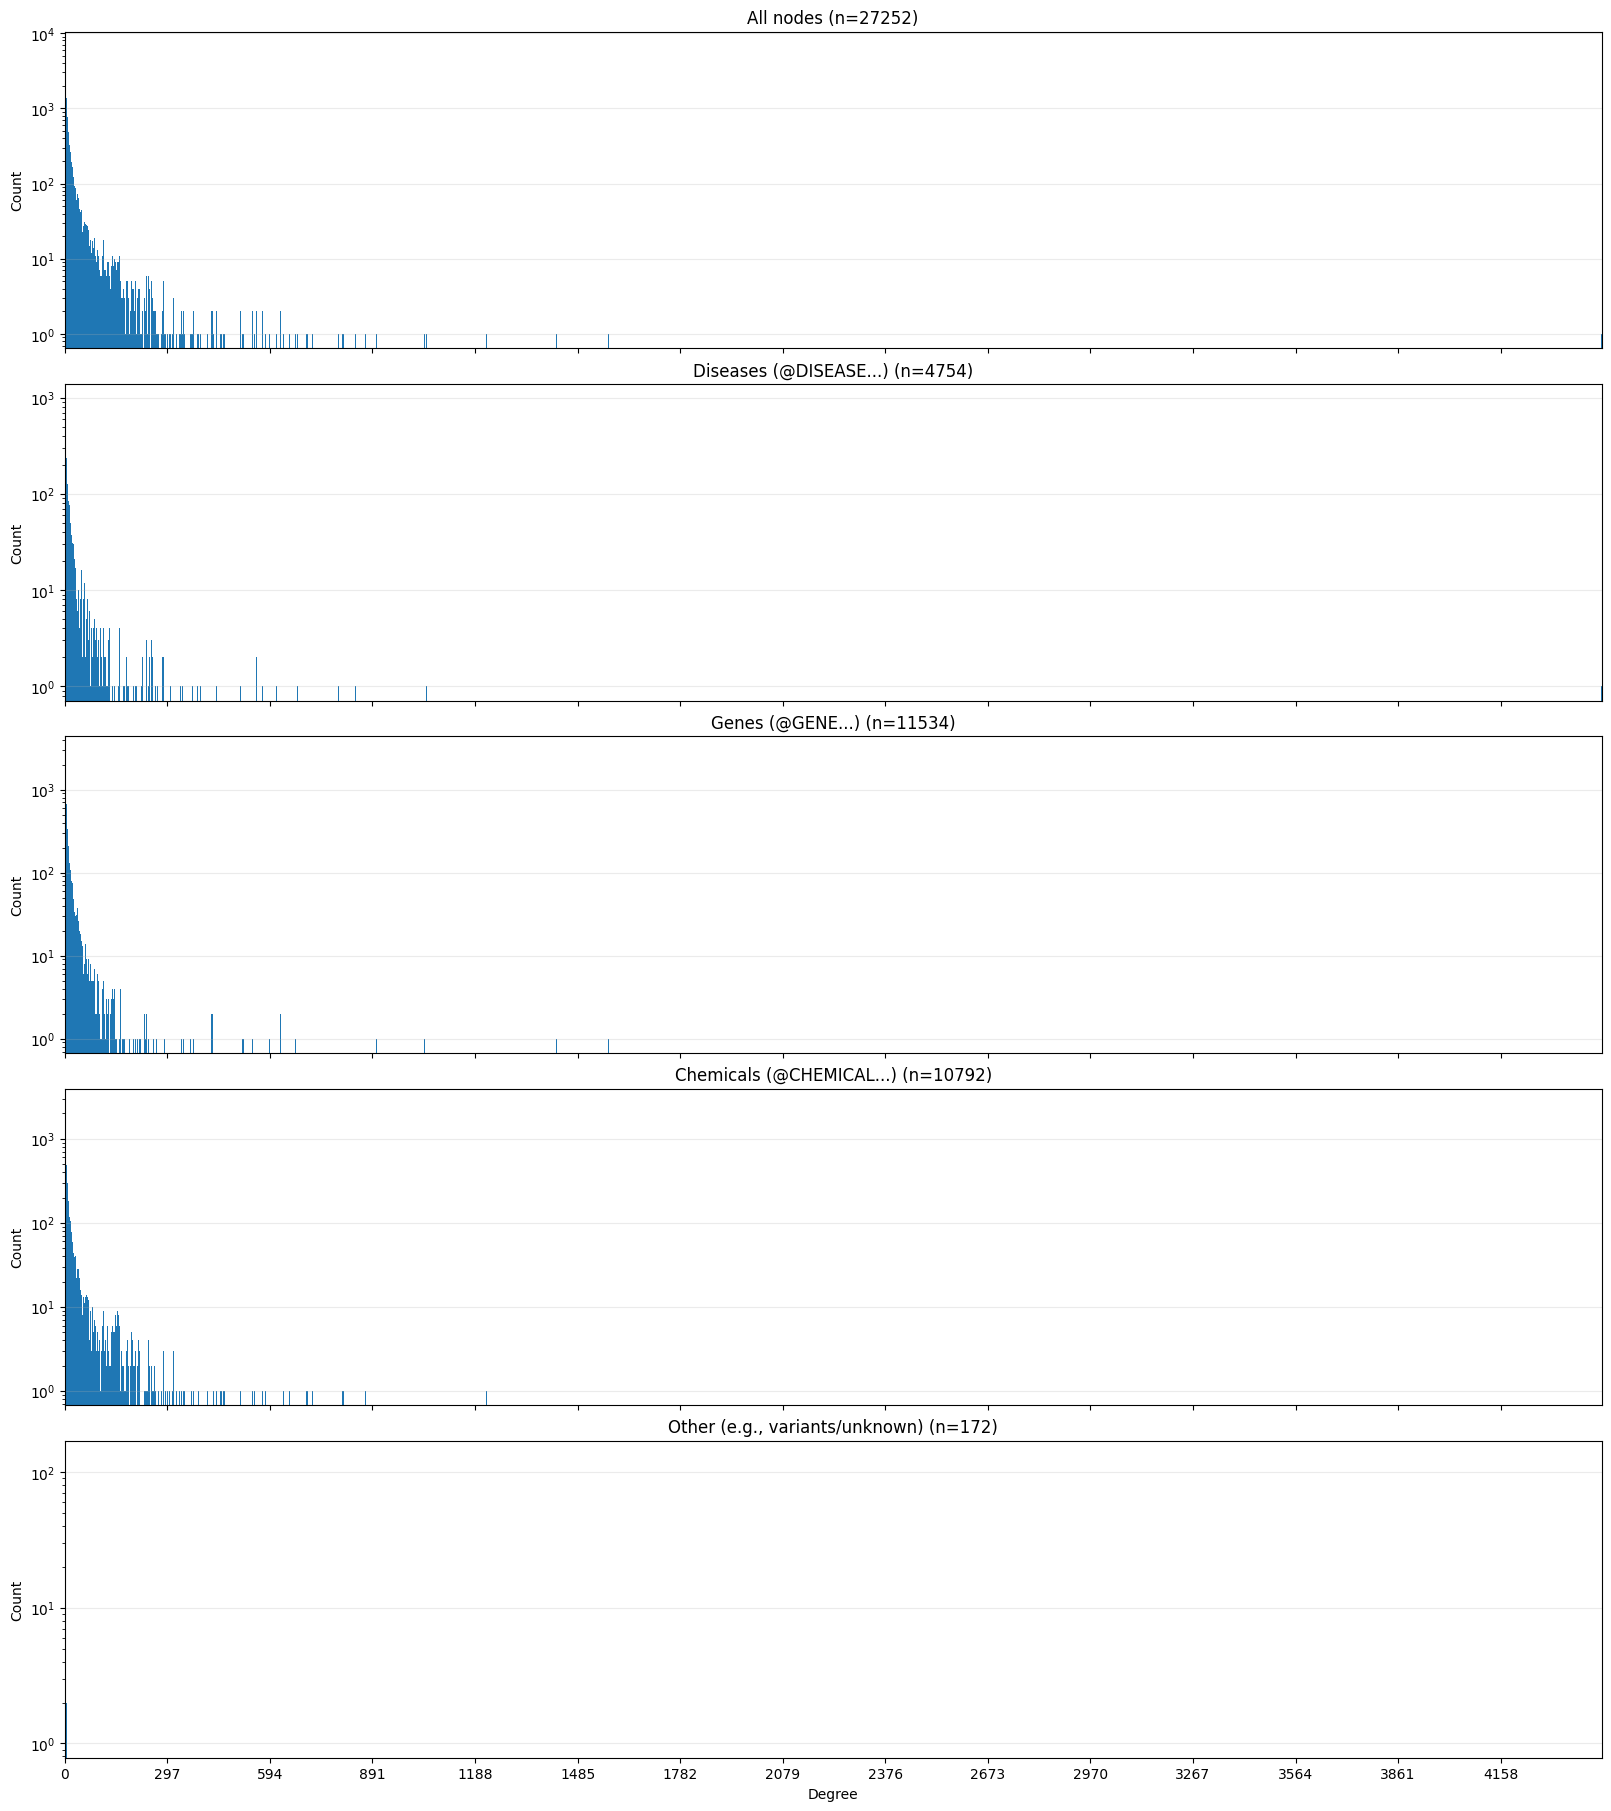

In [49]:
fig, axes, stats = plot_degree_distributions_by_prefix(extendGraph, y_log=True)

In [ ]:
import csv
from pathlib import Path
import networkx as nx

def export_degree_csvs(
    G: nx.Graph,
    out_dir: str = ".",
    type_attr: str = "type",          # node attribute with {'disease','gene','chemical',...}
    weight: str | None = None,        # edge attribute for weighted degree (e.g., "weight")
    directed_mode: str = "total",     # 'total' (in+out), 'in', or 'out' for DiGraph/MultiDiGraph
    name_attrs = ("name", "label"),   # optional node attrs to use as human-readable label
):
    """
    Create 3 CSV files (diseases, chemicals, genes) listing nodes sorted by degree (desc).

    Returns
    -------
    dict: {'disease': '/path/diseases_by_degree.csv', 'chemical': ..., 'gene': ...}
    """
    out_path = Path(out_dir)
    out_path.mkdir(parents=True, exist_ok=True)

    # --- degree computation (supports directed + weighted)
    if G.is_directed():
        if directed_mode == "in":
            deg = dict(G.in_degree(weight=weight))
        elif directed_mode == "out":
            deg = dict(G.out_degree(weight=weight))
        else:
            indeg = dict(G.in_degree(weight=weight))
            outdeg = dict(G.out_degree(weight=weight))
            deg = {n: (indeg.get(n, 0) or 0) + (outdeg.get(n, 0) or 0) for n in G.nodes()}
    else:
        deg = dict(G.degree(weight=weight))

    # --- node type resolution (attribute first, then prefix fallback)
    def resolve_type(n, data):
        t = str(data.get(type_attr, "")).strip().lower()
        if t in {"disease", "gene", "chemical"}:
            return t
        s = str(n)
        if s.startswith("@DISEASE"):
            return "disease"
        if s.startswith("@GENE"):
            return "gene"
        if s.startswith("@CHEMICAL"):
            return "chemical"
        return None  # skip all other types

    def resolve_label(n, data):
        for k in name_attrs:
            if k in data and data[k] is not None:
                return str(data[k])
        return str(n)

    buckets = {"disease": [], "gene": [], "chemical": []}
    for n, data in G.nodes(data=True):
        t = resolve_type(n, data)
        if t is None:
            continue
        buckets[t].append({
            "node_id": n,
            "label": resolve_label(n, data),
            "type": t,
            "degree": float(deg.get(n, 0) or 0)
        })

    # --- sort (degree desc, then node_id as tie-breaker) and write CSVs
    outfiles = {}
    for t, rows in buckets.items():
        rows.sort(key=lambda r: (-r["degree"], str(r["node_id"])))
        fname = out_path / f"{t}s_by_degree.csv"  # diseases_by_degree.csv, etc.
        with open(fname, "w", newline="", encoding="utf-8") as f:
            writer = csv.DictWriter(f, fieldnames=["node_id", "label", "type", "degree"])
            writer.writeheader()
            writer.writerows(rows)
        outfiles[t] = str(fname)

    return outfiles


In [ ]:
paths = export_degree_csvs(extendGraph, out_dir='../CSVs/')

In [ ]:
import csv
with open("../CSVs/exDisease.csv", "w", newline="", encoding="utf-8") as f:
    writer = csv.writer(f)
    for item in exdi:
        writer.writerow([item])

In [ ]:
with open("../CSVs/exChemical.csv", "w", newline="", encoding="utf-8") as f:
    writer = csv.writer(f)
    for item in exchem:
        writer.writerow([item])

### High confidence graph

In [41]:
dcount, ccount, gcount, other = 0, 0, 0, 0
hidi, hichem, higene = [], [], []
for anode in highconfgraph.nodes:
    if '@DISEASE' in anode:
        dcount += 1
        hidi.append(anode)
    elif '@CHEMICAL' in anode:
        ccount += 1
        hichem.append(anode)
    elif '@GENE' in anode:
        gcount += 1
        higene.append(anode)
    else:
        print(anode)
        other += 1
print(f'{dcount} diseases \n{ccount} chemicals \n{gcount} genes\n{other} others')


366 diseases 
602 chemicals 
482 genes
0 others


In [ ]:
fig, axes, stats = plot_degree_distributions_by_prefix(highconfgraph, y_log=True)

## Degree histogram

In [50]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt

def plot_degree_histogram(G,
                          bins='degree',
                          log=False,
                          cumulative=False,
                          title=None,
                          xlabel='Degree',
                          ylabel='Number of nodes',
                          show=True):
    """
    Plot a degree histogram for an undirected NetworkX graph G.
    
    Parameters
    ----------
    G : networkx.Graph
        Undirected graph.
    bins : 'degree' | int | sequence, optional
        If 'degree' (default) creates integer-aligned bins for each degree value.
        Otherwise passed through to matplotlib.hist as bins.
    log : bool, optional
        If True use a logarithmic y-axis.
    cumulative : bool, optional
        If True plot the cumulative histogram.
    title, xlabel, ylabel : str, optional
        Plot labels.
    show : bool, optional
        If False, returns the figure and axis rather than calling plt.show().
    """
    if G.is_directed():
        raise ValueError("Graph must be undirected. Use G.to_undirected() or provide an undirected graph.")
    
    degrees = [d for _, d in G.degree()]
    if len(degrees) == 0:
        raise ValueError("Graph has no nodes.")
    
    min_deg = min(degrees)
    max_deg = max(degrees)
    
    if bins == 'degree':
        # integer-centered bins so each integer degree gets its own bar
        bin_edges = np.arange(min_deg - 0.5, max_deg + 1.5, 1.0)
    else:
        bin_edges = bins
    
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.hist(degrees, bins=bin_edges, log=log, cumulative=cumulative)
    
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    if title is None:
        title = "Degree histogram (#nodes ={}, #edges={})".format(G.number_of_nodes(), G.number_of_edges())
    ax.set_title(title)
    ax.grid(axis='y', alpha=0.4)
    
    if bins == 'degree':
        ax.set_xticks(np.arange(min_deg, max_deg + 1))
    
    plt.tight_layout()
    if show:
        plt.show()
    else:
        return fig, ax


# # Example usage:
# if __name__ == "__main__":
#     G = nx.erdos_renyi_graph(500, 0.02, seed=42)  # undirected random graph
#     plot_degree_histogram(G, bins='degree', log=False, title="Example: ER(500, 0.02) Degree Histogram")


### Extended network

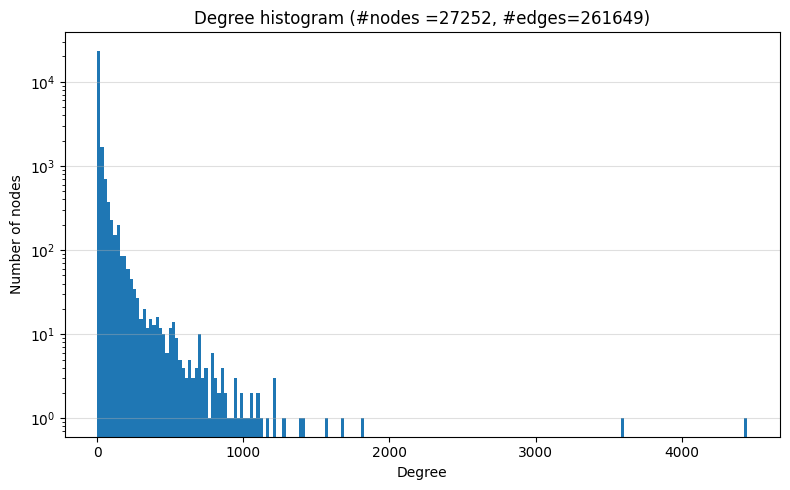

In [51]:
plot_degree_histogram(extendGraph, bins=200, log=True)

### High confidence network

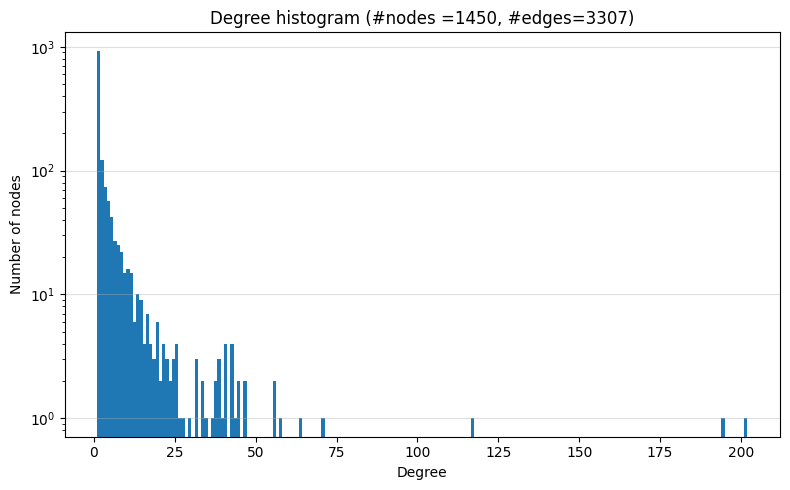

In [52]:
plot_degree_histogram(highconfgraph, bins=200, log=True)

## Clustering coefficients

In [53]:
# Retry: compute clustering stats and plot distribution highlighting the target node.
# This version avoids using caas_jupyter_tools to reduce dependency issues.
# It will print global stats and display the plot.
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
import math

def compute_clustering_stats(G):
    """
    Returns:
      local_clustering: dict {node: clustering_coefficient}
      avg_clustering: float (average of local clustering)
      transitivity: float (global transitivity)
    """
    if len(G) == 0:
        raise ValueError("Graph is empty.")
    local_clustering = nx.clustering(G)
    avg_clustering = nx.average_clustering(G)
    transitivity = nx.transitivity(G)
    return local_clustering, avg_clustering, transitivity

def plot_local_clustering_distribution(local_clustering,
                                       target_node='@DISEASE_Alkaptonuria',
                                       bandwidth=None,
                                       bins=30,
                                       show=True,
                                       save_path=None):
    """
    Plot histogram of local clustering coefficients and overlay a KDE curve.
    Highlights the clustering value of `target_node` if present.
    """
    values = np.array(list(local_clustering.values()))
    if values.size == 0:
        raise ValueError("No clustering values to plot. Is the graph empty?")
    
    # KDE (requires values not all identical)
    unique_vals = np.unique(values)
    use_kde = unique_vals.size > 1
    if use_kde:
        kde = gaussian_kde(values, bw_method=bandwidth)
        x_grid = np.linspace(0.0, 1.0, 400)  # clustering coefficients lie in [0,1]
        kde_vals = kde(x_grid)
    else:
        x_grid = None
        kde_vals = None

    fig, ax = plt.subplots(figsize=(8, 5))
    # Histogram -- do not set explicit color so defaults are used
    ax.hist(values, bins=bins, density=True, alpha=0.6, edgecolor='black')
    
    # Overlay KDE if available
    if use_kde:
        ax.plot(x_grid, kde_vals, linewidth=2)
    
    # Mark target node if present
    if target_node in local_clustering:
        target_val = local_clustering[target_node]
        ax.axvline(target_val, linestyle='--', linewidth=1.5, color='red', label=f"{target_node}: {target_val:.3f}")
        if use_kde:
            y_marker = float(kde(target_val))
            ax.plot([target_val], [y_marker], marker='o', markersize=6, color='red')
        else:
            counts, edges = np.histogram(values, bins=bins, density=True)
            bin_index = np.searchsorted(edges, target_val) - 1
            bin_index = max(0, min(len(counts)-1, bin_index))
            y_marker = counts[bin_index]
            ax.plot([target_val], [y_marker], marker='o', markersize=6, color='red')
        ax.legend()
    else:
        target_val = None
    
    ax.set_xlabel("Local clustering coefficient")
    ax.set_ylabel("Density")
    ax.set_title("Distribution of local clustering coefficients")
    ax.grid(alpha=0.3)
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300)
    if show:
        plt.show()
    else:
        return fig, ax, target_val

def plot_ecdf(local_clust, target_node='@DISEASE_Alkaptonuria', show=True):
    values = np.sort(np.array(list(local_clust.values())))
    n = len(values)
    y = np.arange(1, n+1) / n  # fraction ≤ x

    plt.step(values, y, where='post')
    plt.xlabel('Local clustering coefficient')
    plt.ylabel('Fraction of nodes (≤ x)')
    plt.title('Empirical CDF of local clustering coefficients')

    # mark target with percentile
    if target_node in local_clust:
        v = local_clust[target_node]
        # percentile = fraction ≤ v
        pct = float((values <= v).sum()) / n
        plt.axvline(v, color='red', linestyle='--', linewidth=1.2)
        plt.axhline(pct, color='gray', linestyle=':', linewidth=0.8)
        plt.scatter([v], [pct], color='red')
        plt.annotate(f'{pct*100:.1f}th percentile\n({v:.3f})', xy=(v, pct),
                     xytext=(v+0.02, max(0.05, pct-0.15)),
                     arrowprops=dict(arrowstyle='->', lw=0.8), fontsize=9)
    if show:
        plt.tight_layout(); plt.show()

### Extended network

In [54]:
local_clust, avg_clust, transitivity = compute_clustering_stats(extendGraph)
print(f"average_local_clustering = {avg_clust:.4f}")
print(f"transitivity = {transitivity:.4f}")
print(f"local_clustering['{'@DISEASE_Alkaptonuria'}'] = {local_clust.get('@DISEASE_Alkaptonuria', None)}")

average_local_clustering = 0.2184
transitivity = 0.0731
local_clustering['@DISEASE_Alkaptonuria'] = 0.15412186379928317


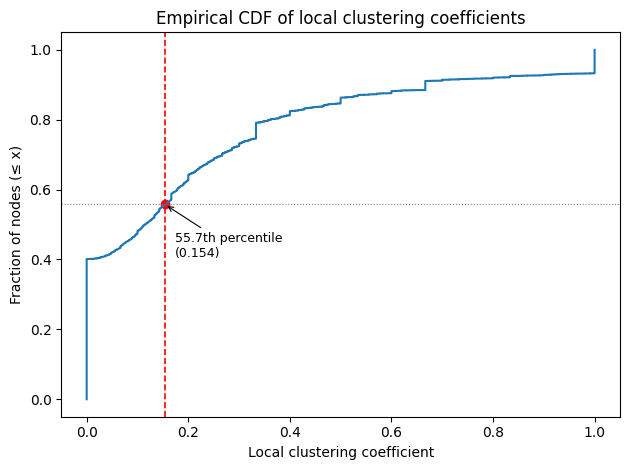

In [55]:
plot_ecdf(local_clust, target_node='@DISEASE_Alkaptonuria')

### High-confidence network

In [56]:
hilocal_clust, hiavg_clust, hitransitivity = compute_clustering_stats(highconfgraph)
print(f"average_local_clustering = {hiavg_clust:.4f}")
print(f"transitivity = {hitransitivity:.4f}")
print(f"local_clustering['{'@DISEASE_Alkaptonuria'}'] = {hilocal_clust.get('@DISEASE_Alkaptonuria', None)}")

average_local_clustering = 0.1137
transitivity = 0.0576
local_clustering['@DISEASE_Alkaptonuria'] = 0.3888888888888889


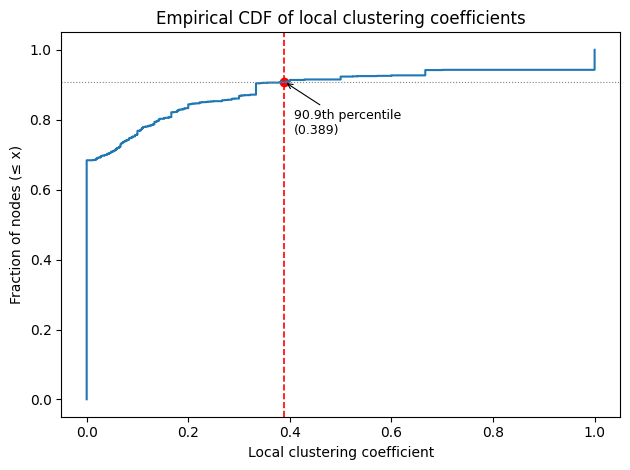

In [57]:
plot_ecdf(hilocal_clust)

# Validation

### Define functions 

In [251]:
from itertools import combinations

def comparewithconnectionlist(stringlist, undirectedgraph, addPrefix = False):
    pathsnet = nx.Graph()
    stringdbnet = nx.Graph() 
    numpath = 0.0
    notfoundgenes = set ()
    foundgenes = set ()
    stringpairs = set() 
    nonstringpairs = set()
    length = 0.0
    # numnonpath = 0.0
    # nonlength = 0.0
    nopathcount = 0.0
    alreadyinpathnet = set()
    numrededges = 0
    numgreenedges = 0
    numblueedges = 0
        
    for gene1, gene2 in stringlist:
        if undirectedgraph.has_node(gene1) and undirectedgraph.has_node(gene2):
            stringdbnet.add_node(gene1, **undirectedgraph.nodes[gene1])
            stringdbnet.add_node(gene2, **undirectedgraph.nodes[gene2])
            pathsnet.add_node(gene1, **undirectedgraph.nodes[gene1])
            pathsnet.add_node(gene2, **undirectedgraph.nodes[gene2])

            stringpairs.add((gene1, gene2))
            foundgenes.add(gene1)
            foundgenes.add(gene2) 
            if undirectedgraph.has_edge(gene1, gene2) or undirectedgraph.has_edge(gene2, gene1):
                stringdbnet.add_edge(gene1, gene2, color='green')
                pathsnet.add_edge(gene1, gene2, color='green')
                numgreenedges += 1
                alreadyinpathnet.add((gene1, gene2))
            # if  undirectedgraph.has_edge(gene2, gene1):
            #     stringdbnet.add_edge(gene2, gene1, color='green', width=3)
            else:
                stringdbnet.add_edge(gene1, gene2, color='blue')
                numblueedges += 1
                try:
                    paths = nx.all_shortest_paths(undirectedgraph, source=gene1, target=gene2)
                    # print(paths)
                except:
                    print(f"\tNo path between {gene1} and {gene2}")
                    nopathcount += 1
                    continue 
                try:
                    for path in paths:
                        # for node in path:
                            # if node.startswith("@GENE") and node != gene1 and node != gene2:
                            #     continue
                        for node in path:
                            pathsnet.add_node(node, **undirectedgraph.nodes[node])
                        # Add the path to the subgraph
                        for i in range(len(path) - 1):
                            u, v = path[i], path[i+1]
                            # Check for both directions because G is directed
                            if undirectedgraph.has_edge(u, v):
                                if (u,v) not in alreadyinpathnet:
                                    pathsnet.add_edge(u, v, color='lightblue')
                            elif undirectedgraph.has_edge(v, u):
                                if (v,u) not in alreadyinpathnet:
                                    pathsnet.add_edge(u, v, color='lightblue')
                            length += 1.0
                        numpath += 1.0
                except:
                    print(f"\tNo path between {gene1} and {gene2}")
                    continue 

        else: 
            if not undirectedgraph.has_node(gene1):
                notfoundgenes.add(gene1)
                pathsnet.add_node(gene1, label=gene1, shape="diamond", color = 'grey')
                stringdbnet.add_node(gene1, label=gene1, shape="diamond", color = 'grey')
                # subnet.nodes(gene1)['shape'] = 'diamond'
            else:
                pathsnet.add_node(gene1, **undirectedgraph.nodes[gene1])
                stringdbnet.add_node(gene1, **undirectedgraph.nodes[gene1])

            if not undirectedgraph.has_node(gene2):
                notfoundgenes.add(gene2)
                pathsnet.add_node(gene2, label=gene2, shape="diamond", color = 'grey')
                stringdbnet.add_node(gene2, label=gene2, shape="diamond", color = 'grey')
                # subnet.nodes(gene2)['shape'] = 'diamond'
            else:
                pathsnet.add_node(gene2, **undirectedgraph.nodes[gene2])
                stringdbnet.add_node(gene2, **undirectedgraph.nodes[gene2])
            # subnet.add_edge(gene1, gene2, color='#000000')
            
            stringdbnet.add_edge(gene2, gene1, color='grey')

    print(numpath)
    print("Not found gene list: {}".format(notfoundgenes))

    all_pairs = list(combinations(foundgenes, 2))
    print('Start analysing unexpected connection')
    for pair in all_pairs:
        # print(pair)
        if (pair[0], pair[1]) not in stringpairs and (pair[1], pair[0]) not in stringpairs: 
            if undirectedgraph.has_edge(pair[0], pair[1]) or undirectedgraph.has_edge(pair[1], pair[0]):
                print("Found unexpected connection between {} and {}".format(pair[0], pair[1]))
                stringdbnet.add_edge(pair[0], pair[1], color='red')
                pathsnet.add_edge(pair[0], pair[1], color='red')
                numrededges += 1
            # if undirectedgraph.has_edge(pair[1], pair[0]):
            #     print("Found unexpected connection between {} and {}".format(pair[0], pair[1]))
            #     stringdbnet.add_edge(pair[1], pair[0], color='red')
            #     pathsnet.add_edge(pair[1], pair[0], color='red')
            nonstringpairs.add((pair[0], pair[1]))
            # paths = nx.all_shortest_paths(undirectedgraph, source=pair[0], target=pair[1])
            # try:
            #     for path in paths:
            #         for node in path:
            #             if node.startswith("@GENE") and node not in pair:
            #                 continue
            #         for node in path:
            #             subnet.add_node(node, **graph.nodes[node])
            #         # Add the path to the subgraph
            #         for i in range(len(path) - 1):
            #             u, v = path[i], path[i+1]
            #             subnet.add_edge(u, v, color='#9D00FF', width = 2)
            #             nonlength += 1.0
            #         numnonpath += 1.0
            # except:
            #     print(f"\tNo path between {gene1} and {gene2}")
            #     continue 
        else:
            print("Existed already the connection between {} and {}".format(pair[0], pair[1]))

    # print(nonstringpairs)
    try:
        print("Average length of expected paths is {}".format(length/numpath))
    except:
        print("No expected path found")
    print("Number of connections having no path is {}".format(nopathcount))
    print("Number of red edges is {}".format(numrededges))
    print("Number of green edges is {}".format(numgreenedges))
    print("Number of blue edges is {}".format(numblueedges))
    # if numnonpath > 0:  
    #     print("Average length of unexpected paths is {}".format(nonlength/numnonpath))
    # else:
    #     print("No unexpected path found")
    pathsnet.remove_nodes_from(list(nx.isolates(pathsnet)))
    return stringdbnet, pathsnet

In [245]:
def visualizeCompareGraphs(comparegraph, pathsgraph, tovalidategraph, pathsgraphname, comparename):
    pathsnetpv = Network(height="1960px", width="100%", notebook=False, directed=False)
    pathsnetpv.repulsion()
    # Load nodes and edges into the Pyvis network
    pathsnetpv.from_nx(pathsgraph)

    pathsnetpv.repulsion(node_distance=120, central_gravity=0.2)

    for e in pathsnetpv.edges:
            # rel = tovalidategraph[e['from']][e['to']]['relation']
            # avg_score = tovalidategraph[e['from']][e['to']]['score']
            pmidlist = tovalidategraph[e['from']][e['to']]['pmidlist']
            e['title'] = f"PMIDs: {pmidlist}"
            e['color'] = pathsgraph[e['from']][e['to']]['color']
            e['width'] = 2

    for n in pathsnetpv.nodes:
        node_data = pathsgraph.nodes[n['id']]
        # n['color'] = node_data.get('color', '#999')
        # n['title'] = f"Type: {node_data.get('type', 'Unknown')}"


    # Render to HTML file and open in browser
    pathsnetpv.write_html(f"{pathsgraphname}.html")


    stringdbnetpv = Network(height="1960px", width="100%", notebook=False, directed=False)
    stringdbnetpv.repulsion()
    stringdbnetpv.from_nx(comparegraph)
    for e in stringdbnetpv.edges:
        if tovalidategraph.has_edge(e['from'], e['to']):
            pmidlist = tovalidategraph[e['from']][e['to']]['pmidlist']
            e['title'] = f"PMIDs: {pmidlist}"
            e['width'] = 2
        # e['color'] = subnet[e['from']][e['to']]['color']
    for n in stringdbnetpv.nodes:
        node_data = comparegraph.nodes[n['id']]
        n['color'] = node_data.get('color', '#999')
        n['title'] = f"Type: {node_data.get('type', 'Unknown')}"
    stringdbnetpv.write_html(f"{comparename}.html")

## StringDB

### Extended network 

In [ ]:
print(len(communities[5]))

2877


In [237]:
almodulefromex = extendGraph.subgraph(communities[5])

In [238]:
print(almodulefromex)

Graph with 2877 nodes and 11463 edges


In [231]:
count = 0
for agene in communities[5]:
    if agene.startswith("@GENE_"):
        count += 1
        print(agene.replace("@GENE_",""))
print(count)

ME1
PHEA
TAS2R146_PS1
PIK3R5
SARDH
METTL9.L
RBCS
MYEOV
103910021
SLC2A1A
NFE2L1
TAS2R38
NUDT2
CBS
GGPS1
RPS6KB1
S100A10B
CALML3
MEIKIN
SPP2
ITGBL1
SIMA
ARH1
LOC542258
LOC105940029
AGPAT4
RAPGEF1
SNF3
SPIN1
DUS1L
SLC44A3
OPN4
MMP20
CAT5
UGP2
LMF1
CCPA
TICAM2
ADSL
LOC548177
SLC25A51
CRNDE
FADS1
ABCD3
ACE_1
FABP6
ABCD4
GYPA
OTUB1
RAB11FIP3
TMEM232
NAT16
PPR1
SUCLA2
AKT3
692126
GAS_1
SPATA24
DDI2
GAD1B
COMTB
ANKRD33
DYRK1B
LINC01194
LOC542727
SERA
FNDC5
LOC101219166
PPIG
OSBPL2
ZPR1
D616_P117009
DUSP5
PTER
PGLS
PCSK9
LOC542375
ALPK3
DBI
DAO
NADK2
FAM107A
ACSS2
GPAM
CYP_34A1
HM13
SYCP3
TEAD3
ATP2A1
AASS
PRIMPOL
PSME3
CIAO2A
PAND1
QRFPR
SIRT5
MPP5
ISN1
LOC100759100
OSBPL10
F7
INHBC
LRRTM3
GPD1
NXT2
PGD
OTC
SOAT2
RACGAP1
COQ6
ANO5
P3H3
SLC30A8
BTD
MIR542_3
IVD
NID2
DBIL5
GYS1
GCGR
MIR490
XYLC
DNAJB1
ABCG8
LOC113807086
SLC27A5
ACOD1
BLAZ
PLPPR2
BSCL2
ACVR2B
FDFT1
INSM2
KCTD7
CBLC
INS
YARS
YARS2
DHODH
ACADVL
HOT5
MCCC2
STAC3
MTR
MYH7
MUT
PFKM
ABCB1A
MVD
CLEC11A
GLYAT
PNPLA2
BCL2L13
OLFR734
SGCA

In [234]:
import pandas as pd
exstring = "data/string_interactions_expart.tsv"
exstringdf = pd.read_csv(exstring, sep='\t', header=0)
print(exstringdf.head())

  #node1   node2       node1_string_id       node2_string_id  \
0   AACS   OXCT1  9606.ENSP00000324842  9606.ENSP00000196371   
1   AACS  EHHADH  9606.ENSP00000324842  9606.ENSP00000231887   
2   AACS   ACAT1  9606.ENSP00000324842  9606.ENSP00000265838   
3   AACS   HMGCL  9606.ENSP00000324842  9606.ENSP00000363614   
4   AASS     BTD  9606.ENSP00000403768  9606.ENSP00000500193   

   neighborhood_on_chromosome  gene_fusion  phylogenetic_cooccurrence  \
0                           0            0                          0   
1                           0            0                          0   
2                           0            0                          0   
3                           0            0                          0   
4                           0            0                          0   

   homology  coexpression  experimentally_determined_interaction  \
0       0.0             0                                    0.0   
1       0.0             0               

In [235]:
stringexdict = exstringdf.to_dict('records')
print(len(stringexdict))

698


In [236]:
stringexlist = []
for record in stringexdict:
    gene1 = "@GENE_" + record['#node1']
    gene2 = "@GENE_" + record['node2']
    stringexlist.append((gene1, gene2))

In [ ]:
exstringdbgraph, exceptpathgraph = comparewithconnectionlist(stringexlist, almodulefromex , True)

4536.0
Not found gene list: {'@GENE_GADL1', '@GENE_ALDH18A1', '@GENE_YARS1', '@GENE_MT-ATP6', '@GENE_MARC1', '@GENE_MT-CYB'}
Start analysing unexpected connection
Existed already the connection between @GENE_INHBB and @GENE_FST
Existed already the connection between @GENE_INHBB and @GENE_ACVR2B
Existed already the connection between @GENE_LPA and @GENE_APOA1
Existed already the connection between @GENE_LPA and @GENE_DBI
Existed already the connection between @GENE_LPA and @GENE_APOC2
Existed already the connection between @GENE_LPA and @GENE_PLA2G7
Existed already the connection between @GENE_LPA and @GENE_APOB
Existed already the connection between @GENE_LPA and @GENE_APOC3
Existed already the connection between @GENE_LPA and @GENE_APOA5
Existed already the connection between @GENE_LPA and @GENE_APOC4
Existed already the connection between @GENE_LPA and @GENE_CETP
Existed already the connection between @GENE_ARG2 and @GENE_ASL
Existed already the connection between @GENE_ARG2 and @GEN

In [ ]:
visualizeCompareGraphs(exstringdbgraph, exceptpathgraph, almodulefromex, "HTMLs/exstringpaths", "HTMLS/exstringdb")

#### HGD community

In [261]:
hgdCom = communities[2]
if '@GENE_HGD' in hgdCom:
    print("HGD is in community 2")

HGD is in community 2


In [262]:
hgdmodulefromex = extendGraph.subgraph(hgdCom)

In [263]:
print(hgdmodulefromex)

Graph with 3695 nodes and 14065 edges


In [271]:
count = 0
for agene in hgdCom:
    if agene.startswith("@GENE_"):
        count += 1
        print(agene.replace("@GENE_",""))
print(count)

LBFABP
RAB18
PER2.L
CTT1
LOC107807966
HOG1
MR1
NBPF10
IPMK
DAZL
CYP2B9
SQOR
GSTF2
GSH1
LOC406081
AT3G14780
RBR1
IAA7
107419956
HCT
ACA1
ATXN1
PRESTIN
SLC39A3
BETA_OHASE_2
NADK
NEK4
PSY2
LOC100534483
TMTC2
CPIPJ_CPIJ005173
UMOD
HK1
PPC1
STRBP
RBM38
SUOX
SYP121
BIN2
AOS
PTP2
LOC100274012
KAT8
LOC394274
RBOHD
LOC101251136
GOX1
BGL2
TMX3
XET2
MDH
GUCY2C
APY2
WOL
PAD3
OPS
AGMAT
PTP3
LOC781146
MB
H16_RS03295
PARA
PRODH
PCS2
MASE_RS16065
MAD2L1BP
SNRPA1
NPR3
RAD50
GA3OX4
SLT
MDAR1
GST
PRX7
ELOB
LOC406142
NACH
APX1
LOC100303688
LOC103440008
POX2
GABRA1
TEAD2
LOC107788038
GOLS2
CKI1
PMS2P1
LOC107420772
LHA1
RNPS1
POBA
RAP2.7
SLC13A5
PPOX
STB3
PHYB
FBA1
AP2
MPK3
LOC103429376
LOC106762083
EDS5
ADI1
ANKS1A
LOC107840564
MRE11
MNP
LOC103419899
TAH11
OXR1
MTMR3
SIAE
LOC101246087
MFGE8
MDT_15
YIA6
LOC108342994
GGP1
WRKY1
LOC105318968
DMR6
MYC3
HPV18I2
ADR1
LOC107871140
AOX2
TMEM201
PAFAH1B1
AFLM
SOX9A
LOC406144
GSH2
LOC102585026
LOC102596056
FC2
GLCAK
SLC39A5
AT5G40153
LOX1.1
UGT71B1
OXDC
LOC101202931

In [265]:
import pandas as pd
hgdstring = "data/string_interactions_short_hgd.tsv"
hgdstringdf = pd.read_csv(hgdstring, sep='\t', header=0)
print(hgdstringdf.head())

   #node1  node2       node1_string_id       node2_string_id  \
0   AGMAT   FAAH  9606.ENSP00000364986  9606.ENSP00000243167   
1   AGMAT   AOC1  9606.ENSP00000364986  9606.ENSP00000411613   
2  AGPAT2   CDS1  9606.ENSP00000360761  9606.ENSP00000295887   
3  AGPAT2   CDS2  9606.ENSP00000360761  9606.ENSP00000419879   
4   AKAP5  ROBO3  9606.ENSP00000378207  9606.ENSP00000380903   

   neighborhood_on_chromosome  gene_fusion  phylogenetic_cooccurrence  \
0                           0            0                          0   
1                           0            0                          0   
2                           0            0                          0   
3                           0            0                          0   
4                           0            0                          0   

   homology  coexpression  experimentally_determined_interaction  \
0       0.0             0                                    0.0   
1       0.0             0               

In [266]:
stringhgddict = hgdstringdf.to_dict('records')
print(len(stringhgddict))

120


In [267]:
stringhgdlist = []
for record in stringhgddict:
    gene1 = "@GENE_" + record['#node1']
    gene2 = "@GENE_" + record['node2']
    stringhgdlist.append((gene1, gene2))

In [268]:
hgdstringdbgraph, hgdpathgraph = comparewithconnectionlist(stringhgdlist, hgdmodulefromex , True)

1081.0
Not found gene list: {'@GENE_MDH2', '@GENE_LRP5', '@GENE_TMEM189', '@GENE_FAAH'}
Start analysing unexpected connection
Existed already the connection between @GENE_RBFOX2 and @GENE_ATXN1
Existed already the connection between @GENE_RBFOX2 and @GENE_RBM38
Existed already the connection between @GENE_RAB18 and @GENE_PAFAH1B1
Existed already the connection between @GENE_PAG1 and @GENE_SLC9A3R1
Existed already the connection between @GENE_MFGE8 and @GENE_LYZ
Existed already the connection between @GENE_KLK8 and @GENE_CARD16
Existed already the connection between @GENE_CHPF2 and @GENE_CHSY1
Existed already the connection between @GENE_PLA2G10 and @GENE_PAFAH1B1
Existed already the connection between @GENE_SPSB4 and @GENE_ELOB
Existed already the connection between @GENE_GPR68 and @GENE_GPR4
Existed already the connection between @GENE_ARF5 and @GENE_ARFIP2
Existed already the connection between @GENE_ARF5 and @GENE_USO1
Existed already the connection between @GENE_SPSB1 and @GENE_ELO

In [269]:
visualizeCompareGraphs(hgdstringdbgraph, hgdpathgraph, hgdmodulefromex, "HTMLs/hgdstringpaths", "HTMLS/hgdstringdb")

### High-confidence

In [253]:
hialtergenename = {'SAA1': 'SAA@',
                   'SAA4': 'SAA@',
                   'CDH17': 'HPT1',
                   'CYP27B1': 'VDR',
                   'HLA-A': 'HLA_A',
                   'HLA-B': 'HLA_B',
                   'STING1': 'TMEM173', 
                   'IFNA2': 'IFNA',
                   'IFNA17': 'IFNA',
                   'NLRP3': 'DFNA34',
                   'CDSN':'S',
                   'MT-CO2':'COX2',
                   'SLC2A1': 'CSE',
                   'HLA-DRB1':'HLA_DRB1'}

In [255]:
import pandas as pd
histring = "data/string_interactions_hiconf.tsv"
stringhidf = pd.read_csv(histring, sep='\t', header=0)
print(stringhidf.head())

  #node1   node2       node1_string_id       node2_string_id  \
0   ABL1     RB1  9606.ENSP00000361423  9606.ENSP00000267163   
1   ABL1    EGFR  9606.ENSP00000361423  9606.ENSP00000275493   
2   ABL1   NTRK2  9606.ENSP00000361423  9606.ENSP00000277120   
3   ABL1     ATM  9606.ENSP00000361423  9606.ENSP00000278616   
4   ABL1  STAT5A  9606.ENSP00000361423  9606.ENSP00000341208   

   neighborhood_on_chromosome  gene_fusion  phylogenetic_cooccurrence  \
0                           0            0                          0   
1                           0            0                          0   
2                           0            0                          0   
3                           0            0                          0   
4                           0            0                          0   

   homology  coexpression  experimentally_determined_interaction  \
0     0.000             0                                  0.736   
1     0.591             0               

In [256]:
stringhidict = stringhidf.to_dict('records')
print(stringhidf)

        #node1     node2       node1_string_id       node2_string_id  \
0         ABL1       RB1  9606.ENSP00000361423  9606.ENSP00000267163   
1         ABL1      EGFR  9606.ENSP00000361423  9606.ENSP00000275493   
2         ABL1     NTRK2  9606.ENSP00000361423  9606.ENSP00000277120   
3         ABL1       ATM  9606.ENSP00000361423  9606.ENSP00000278616   
4         ABL1    STAT5A  9606.ENSP00000361423  9606.ENSP00000341208   
..         ...       ...                   ...                   ...   
916        TNF  TNFRSF1A  9606.ENSP00000398698  9606.ENSP00000162749   
917  TNFRSF11A   TNFSF11  9606.ENSP00000465500  9606.ENSP00000381775   
918  TNFRSF11A     TRAF6  9606.ENSP00000465500  9606.ENSP00000433623   
919  TNFRSF11B   TNFSF11  9606.ENSP00000297350  9606.ENSP00000381775   
920   TNFRSF1A     TRAF6  9606.ENSP00000162749  9606.ENSP00000433623   

     neighborhood_on_chromosome  gene_fusion  phylogenetic_cooccurrence  \
0                             0            0                

In [257]:
stringhilist = []
for con in stringhidict:
    if con['#node1'] in hialtergenename:
        gene1 = "@GENE_" + hialtergenename[con['#node1']]
    else:
        gene1 = "@GENE_" + con['#node1']
    if con['node2'] in hialtergenename:
        gene2 = "@GENE_" + hialtergenename[con['node2']]
    else:
        gene2 = "@GENE_" + con['node2']
        
    stringhilist.append((gene1, gene2))

In [258]:
print(len(stringhilist))

921


In [259]:
stringhi, stringhipaths = comparewithconnectionlist(stringhilist, highconfgraph, addPrefix = False)

3245.0
Not found gene list: {'@GENE_HAMP', '@GENE_ALDH2', '@GENE_SREBF1'}
Start analysing unexpected connection
Existed already the connection between @GENE_ACSL4 and @GENE_FASN
Existed already the connection between @GENE_ELN and @GENE_LOX
Existed already the connection between @GENE_CYBB and @GENE_MAPK1
Existed already the connection between @GENE_CYBB and @GENE_MMP2
Existed already the connection between @GENE_CYBB and @GENE_NAMPT
Existed already the connection between @GENE_CYBB and @GENE_MMP9
Existed already the connection between @GENE_GSTZ1 and @GENE_FAH
Existed already the connection between @GENE_GSTZ1 and @GENE_HGD
Existed already the connection between @GENE_GPC3 and @GENE_WNT2
Existed already the connection between @GENE_GPC3 and @GENE_WNT3A
Existed already the connection between @GENE_GPC3 and @GENE_IHH
Existed already the connection between @GENE_GPC3 and @GENE_SHH
Existed already the connection between @GENE_GPC3 and @GENE_WNT1
Existed already the connection between @GEN

In [260]:
visualizeCompareGraphs(stringhi, stringhipaths, highconfgraph, '../HTMLs/stringhipaths', '../HTMLs/stringhi')

## DGIdb

In [276]:
import requests
import time
def mapsdrug2pub(gene_drug_dict, drugccode):
    gene_drug_relations = set()
    for rel in gene_drug_dict:
        pubtatorname1 = '@GENE_' + rel['gene']
        pubtatorname2 = None
        
        if rel['drug'] not in drugccode:
            nnode2 = rel["drug"].replace(" ", "%20")
            entity_type = "Chemical"
            pt_url2 = f"https://www.ncbi.nlm.nih.gov/research/pubtator3-api/entity/autocomplete/?query={nnode2}&concept={entity_type}&limit=1"
            # pt_url2 = f"https://www.ncbi.nlm.nih.gov/research/pubtator3-api/entity/autocomplete/?query={nnode2}&limit=1"
            print(pt_url2)
            pt_response2 = requests.get(pt_url2)
            if pt_response2.status_code != 200 or not pt_response2.json():
                print(f"Cannot find pubtator name for {nnode2}")

            else:
                entity_data2 = pt_response2.json()[0]
                pubtator3_label2 = entity_data2.get("_id")
                pubtator3_name2 =  entity_data2.get("name")
                pubtator3_type2 = entity_data2.get("biotype")
                print( pubtator3_label2)
                pubtatorname2 = pubtator3_label2
            drugccode[rel['drug']] = pubtatorname2
            time.sleep(0.3)
        else:
            pubtatorname2 = drugccode[rel['drug']]
        
        if pubtatorname1 and pubtatorname2:
            print(pubtatorname1, pubtatorname2)
            gene_drug_relations.add((pubtatorname1, pubtatorname2))
        elif pubtatorname1:
            gene_drug_relations.add((pubtatorname1, rel['drug']))
    return gene_drug_relations, drugccode

### HGD module 

In [274]:
# import pandas as pd

# Replace with your actual file path
dgidbhgd = 'data/dgidb_hgd.tsv'

# Read the TSV file into a DataFrame
dgidbhgddf = pd.read_csv(dgidbhgd, sep='\t')

# Display the first few rows
print(dgidbhgddf.head(5))

    gene                         drug regulatory approval  \
0  CRYGD                     DOXAPRAM            Approved   
1  CRYGD                       HE3235        Not Approved   
2   AOC1  OXYMETAZOLINE HYDROCHLORIDE            Approved   
3   AOC1               CHLORPROMAZINE            Approved   
4   AOC1                     RX821002        Not Approved   

             indication  interaction score  
0                   NaN          26.101899  
1  antineoplastic agent          13.050950  
2             analgesic           0.056743  
3                   NaN           0.030672  
4                   NaN           0.283716  


In [275]:
dgihgd_dicts = dgidbhgddf.to_dict('records')
print(len(dgihgd_dicts))

1554


In [277]:
drugccode = dict()

In [ ]:
drugccode["METHACYCLINE%20HYDROCHLORIDE"] = '@CHEMICAL_Methacycline'
drugccode["@CHEMICAL_N_arachidonylglycine"] = '@CHEMICAL_N_arachidonylglycine'


In [278]:
dgihgdrelset, drugccode = mapsdrug2pub(dgihgd_dicts, drugccode)

https://www.ncbi.nlm.nih.gov/research/pubtator3-api/entity/autocomplete/?query=DOXAPRAM&concept=Chemical&limit=1
@CHEMICAL_Doxapram
@GENE_CRYGD @CHEMICAL_Doxapram
https://www.ncbi.nlm.nih.gov/research/pubtator3-api/entity/autocomplete/?query=HE3235&concept=Chemical&limit=1
@CHEMICAL_17_ethynylandrostane_3_17_diol
@GENE_CRYGD @CHEMICAL_17_ethynylandrostane_3_17_diol
https://www.ncbi.nlm.nih.gov/research/pubtator3-api/entity/autocomplete/?query=OXYMETAZOLINE%20HYDROCHLORIDE&concept=Chemical&limit=1
@CHEMICAL_Oxymetazoline
@GENE_AOC1 @CHEMICAL_Oxymetazoline
https://www.ncbi.nlm.nih.gov/research/pubtator3-api/entity/autocomplete/?query=CHLORPROMAZINE&concept=Chemical&limit=1
@CHEMICAL_Chlorpromazine
@GENE_AOC1 @CHEMICAL_Chlorpromazine
https://www.ncbi.nlm.nih.gov/research/pubtator3-api/entity/autocomplete/?query=RX821002&concept=Chemical&limit=1
@CHEMICAL_2_methoxyidazoxan
@GENE_AOC1 @CHEMICAL_2_methoxyidazoxan
https://www.ncbi.nlm.nih.gov/research/pubtator3-api/entity/autocomplete/?query=

In [279]:
hgddgirellist = []
for rel in dgihgdrelset:
    if '@CHEMICAL' in rel[1]:
        hgddgirellist.append((rel[0], rel[1]))
print(len(hgddgirellist))

1008


In [280]:
hgddgidbgraph, hgddgidbpaths = comparewithconnectionlist(hgddgirellist, hgdmodulefromex , False)

230.0
Not found gene list: {'@CHEMICAL_propazine', '@CHEMICAL_grosheimin', '@CHEMICAL_ansuvimab', '@CHEMICAL_ML012', '@CHEMICAL_Ephedrine', '@CHEMICAL_Trimipramine', '@CHEMICAL_Ellagic_Acid', '@CHEMICAL_CGA_protein_human', '@CHEMICAL_morin', '@CHEMICAL_Medetomidine', '@CHEMICAL_Gabapentin', '@CHEMICAL_(4_(m_Chlorophenylcarbamoyloxy)_2_butynyl)trimethylammonium_Chloride', '@CHEMICAL_sandaracopimaric_acid', '@CHEMICAL_Phenoxybenzamine', '@CHEMICAL_isoguvacine', '@CHEMICAL_ecabet', '@CHEMICAL_Baclofen', '@CHEMICAL_L_162313', '@CHEMICAL_fangchinoline', '@CHEMICAL_Saquinavir', '@CHEMICAL_hexahydrosiladifenidol', '@CHEMICAL_Furosemide', '@CHEMICAL_plecanatide', '@CHEMICAL_lofexidine', '@CHEMICAL_pyrithione_zinc', '@CHEMICAL_3_(2_hydroxy_4_(1_1_dimethylheptyl)phenyl)_4_(3_hydroxypropyl)cyclohexanol', '@CHEMICAL_AQ_RA_741', '@CHEMICAL_Olanzapine', '@CHEMICAL_MRK_016', '@CHEMICAL_methyl_gallate', '@CHEMICAL_Pregabalin', '@CHEMICAL_vanoxerine', '@CHEMICAL_Dextran_Sulfate', '@CHEMICAL_Pentobarbit

In [281]:
visualizeCompareGraphs(hgddgidbgraph, hgddgidbpaths, hgdmodulefromex, "HTMLs/hgddgidbpaths", "HTMLS/hgddgidb")

## KEGG Pathway

# Analysis

## Define general functions 

In [207]:
import matplotlib.pyplot as plt

def plot_top_and_specific_entities(score_dict, specific_entities=None, top_n=10, title="Entity Score Comparison"):
    """
    Plots a bar chart of the top N entities by score, plus any specific entities.
    
    Parameters:
    - score_dict: dict {entity_name: score}
    - specific_entities: list of entity names to always include
    - top_n: number of top scoring entities to include
    - title: title of the plot
    """
    if specific_entities is None:
        specific_entities = []

    # Get top N entities by score
    top_entities = sorted(score_dict.items(), key=lambda x: x[1], reverse=True)[:top_n]
    
    # Add specified entities if not already in the top
    for entity in specific_entities:
        if entity in score_dict and entity not in dict(top_entities):
            top_entities.append((entity, score_dict[entity]))

    # Remove duplicates while preserving order
    seen = set()
    filtered_entities = []
    for e, s in top_entities:
        if e not in seen:
            if len(e) > 50:
                e = e[:47] + "..."
            filtered_entities.append((e, s))
            seen.add(e)

    # Prepare data for plotting
    labels, values = zip(*filtered_entities)
    
    # Plot
    plt.figure(figsize=(7, 5))
    bars = plt.bar(labels, values)
    plt.xticks(rotation=45, ha='right')
    plt.ylabel("Score")
    plt.title(title)
    plt.tight_layout()
    plt.show()


In [81]:
def separateTypes(commondict):
    genedict, chemdict, didict = dict(), dict(), dict()
    for node, score in commondict.items():
        if '@GENE' in node:
            genedict[node] = score 
        if '@CHEMICAL' in node:
            chemdict[node] = score 
        if '@DISEASE' in node:
            didict[node] = score 
    return genedict, chemdict, didict 

In [82]:
import matplotlib.pyplot as plt

def plot_top_20_entities_3dicts(dict1, dict2, dict3):
    # Example dictionaries
    # dict1 = {"a": 5, "b": 2, "c": 7, "d": 0, "e": 3}
    # dict2 = {"x": 10, "y": 0, "z": 8, "w": 4, "v": 6}
    # dict3 = {"p": 1, "q": 9, "r": 0, "s": 2, "t": 5}
    dicts = [dict1, dict2, dict3]
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))  # 1 row, 3 columns

    for i, (d, ax) in enumerate(zip(dicts, axes), start=1):
        # Filter and sort
        filtered = {k: v for k, v in d.items() if v > 0.0}
        sorted_items = sorted(filtered.items(), key=lambda x: x[1], reverse=True)[:20]

        keys, values = zip(*sorted_items) if sorted_items else ([], [])
        
        ax.bar(keys, values)
        if i == 1:
            ax.set_title(f"GENE - Top 20")
        if i == 2:
            ax.set_title(f"CHEMICAL - Top 20")
        if i == 3:
            ax.set_title(f"DISEASE - Top 20")
        ax.set_xticklabels(keys, rotation=45, ha="right")

    plt.tight_layout()
    plt.show()


In [83]:
import matplotlib.pyplot as plt

def plot_top_per_type(dict1, dict2, dict3, labels=("Genes", "Chemicals", "Diseases"), top_n=20):
    """
    Plot a grouped bar chart where x-axis keys are ordered by *interleaved ranks* across dicts:
    1st place of each type, then 2nd place of each type, etc.
    
    Rules:
    - Select top_n non-zero entries per dictionary.
    - Build the x-axis by interleaving ranks across the three dicts.
    - If a key appears in multiple dicts, keep it only once (first time it appears in the interleaving).
    - If a dict has fewer entries than rank r, skip for that rank.
    - Omit any dictionary series that has no non-zero values overall.
    
    Parameters
    ----------
    dict1, dict2, dict3 : dict
        Mapping of {key: score}.
    labels : tuple(str, str, str)
        Labels for the 3 dictionaries.
    top_n : int
        Number of top keys to select *per dictionary* before interleaving.
    """
    # Filter zeros for selection
    d1 = {k: v for k, v in dict1.items() if v > 0.0001}
    d2 = {k: v for k, v in dict2.items() if v > 0.0001}
    d3 = {k: v for k, v in dict3.items() if v > 0.0001}
    
    if not (d1 or d2 or d3):
        print("No non-zero elements found among the dictionaries.")
        return
    
    # Take top_n per dictionary
    top1 = sorted(d1.items(), key=lambda x: x[1], reverse=True)[:top_n]
    top2 = sorted(d2.items(), key=lambda x: x[1], reverse=True)[:top_n]
    top3 = sorted(d3.items(), key=lambda x: x[1], reverse=True)[:top_n]
    
    top1_dict, top2_dict, top3_dict = dict(top1), dict(top2), dict(top3)
    
    # Interleave by rank
    ranked_lists = [top1, top2, top3]
    interleaved_keys, seen = [], set()
    max_len = max(len(top1), len(top2), len(top3))
    
    for r in range(max_len):
        for lst in ranked_lists:
            if r < len(lst):
                k = lst[r][0]
                if k not in seen:
                    interleaved_keys.append(k)
                    seen.add(k)
    
    if not interleaved_keys:
        print("No keys to plot after interleaving.")
        return
    
    # Values aligned to keys
    v1 = [top1_dict.get(k, 0) for k in interleaved_keys]
    v2 = [top2_dict.get(k, 0) for k in interleaved_keys]
    v3 = [top3_dict.get(k, 0) for k in interleaved_keys]
    
    any1, any2, any3 = any(v1), any(v2), any(v3)
    series_count = sum([any1, any2, any3])
    if series_count == 0:
        print("All series are zero after filtering.")
        return
    
    # Plot
    x = list(range(len(interleaved_keys)))
    width = 0.9 / series_count  # total group width = 0.6, divided among series
    
    plt.figure(figsize=(max(12, min(30, 0.45*len(interleaved_keys) + 6)), 7))
    
    offsets = []
    if series_count == 1:
        offsets = [0]
    elif series_count == 2:
        offsets = [-width/2, width/2]
    else:  # 3 series
        offsets = [-width, 0, width]
    
    idx = 0
    # print(width)
    if any1:
        plt.bar([i + offsets[idx] for i in x], v1, width=width*1.5, label=labels[0]); idx += 1
    if any2:
        plt.bar([i + offsets[idx] for i in x], v2, width=width*1.5, label=labels[1]); idx += 1
    if any3:
        plt.bar([i + offsets[idx] for i in x], v3, width=width*1.5, label=labels[2]); idx += 1
    
    # X-axis ticks centered under groups
    plt.xticks(x, interleaved_keys, rotation=45, ha="right")
    plt.ylabel("Score")
    # plt.title(f"Interleaved Ranks (Top {top_n} per type)")
    plt.legend()
    plt.tight_layout()
    plt.show()

In [114]:
import networkx as nx
from heapq import nlargest
from collections import defaultdict
from typing import Dict, Iterable, Tuple, Union, Set

def topk_subgraph_by_prefix(
    G: nx.Graph,
    scores: Dict[str, float],
    k: Union[int, Dict[str, int]] = 10,
    prefixes: Iterable[str] = ("@CHEMICAL", "@GENE", "@DISEASE"),
    node_of_interest: str = None,
) -> Tuple[nx.Graph, Dict[str, Set[str]]]:
    """
    Build a subgraph containing the top-k nodes for each prefix.
    
    Parameters
    ----------
    G : nx.Graph
        Your full graph.
    scores : dict[str, float]
        Mapping node -> score/value used for ranking.
    k : int | dict[str, int]
        If int, use same k for all prefixes.
        If dict, per-prefix k, e.g. {"@CHEMICAL": 30, "@GENE": 50, "@DISEASE": 20}.
    prefixes : iterable[str]
        Prefixes to group by, e.g. ("@CHEMICAL", "@GENE", "@DISEASE").
    
    Returns
    -------
    subG : nx.Graph
        Node-induced subgraph on the selected nodes.
    selected_by_prefix : dict[str, set[str]]
        The chosen nodes per prefix.
    """
    # Helper to detect a node's prefix
    prefix_set = tuple(prefixes)  # ensure tuple for startswith
    def node_prefix(n: str) -> Union[str, None]:
        for p in prefix_set:
            if n.startswith(p):
                return p
        return None

    # Group nodes by prefix (only nodes that exist in G and have a score)
    grouped = defaultdict(list)  # prefix -> list[(node, score)]
    for n, val in scores.items():
        if n in G:
            p = node_prefix(n)
            if p is not None:
                grouped[p].append((n, val))

    # Select top-k for each prefix
    selected_by_prefix: Dict[str, Set[str]] = {}
    selected_nodes: Set[str] = set()

    for p, items in grouped.items():
        k_p = k[p] if isinstance(k, dict) else k
        if k_p <= 0:
            selected_by_prefix[p] = set()
            continue
        top_p = nlargest(k_p, items, key=lambda x: x[1])
        chosen = {n for n, _ in top_p}
        selected_by_prefix[p] = chosen
        selected_nodes.update(chosen)
    selected_nodes.add(node_of_interest)

    # Induced subgraph
    subG = G.subgraph(selected_nodes).copy()
    return subG, selected_by_prefix


## PPR

### Define function

In [ ]:
# page rank 
import networkx as nx
def ppr(graph):
    # Define the node of interest
    node_of_interest = '@DISEASE_Alkaptonuria'

    # Personalized PageRank vector: only the node of interest has nonzero weight
    personalization = {n: 0 for n in graph.nodes()}
    personalization[node_of_interest] = 1.0

    # Compute Personalized PageRank
    pagerank_scores = nx.pagerank(graph, alpha=0.85, personalization=personalization, weight='score')

    # Sort nodes by their PageRank score (descending)

    ppr = dict(sorted(pagerank_scores.items(), key=lambda item: item[1], reverse=True))
    del ppr['@DISEASE_Alkaptonuria']
    pprGene = dict()
    pprChem = dict()
    pprDi = dict()

    # Display top connected nodes to 'A'
    # print("Top nodes most connected to node @DISEASE_Alkaptonuria (via PageRank):")
    for node, score in ppr.items():
        if '@GENE' in node:
            pprGene[node] = score

        if '@CHEMICAL' in node:
            pprChem[node] = score

        if '@DISEASE' in node and node != '@DISEASE_Alkaptonuria':
            pprDi[node] = score
            
    plot_top_20_entities_3dicts(pprGene, pprChem, pprDi)
    return ppr 

In [179]:
def plot_top_k(resdict, k=20, title="Top-k Entities by Score"):
    topgenes, topchems, topdis = dict(), dict(), dict()
    for node, score in resdict.items():
        if '@GENE' in node:
            topgenes[node] = score

        if '@CHEMICAL' in node:
            if len(node) > 50:
                newnname = node.replace('@CHEMICAL_', '')
                newnname = newnname[0:30] + '...'
                topchems[newnname] = score
            else:
                topchems[node] = score

        if '@DISEASE' in node:
            topdis[node] = score
    plot_top_20_entities_3dicts(topgenes, topchems, topdis)

### Extend graph

/var/folders/01/v0p4sfw945j32p3yvg67p6cc0000gn/T/ipykernel_27313/2491794532.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(keys, rotation=45, ha="right")
/var/folders/01/v0p4sfw945j32p3yvg67p6cc0000gn/T/ipykernel_27313/2491794532.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(keys, rotation=45, ha="right")
/var/folders/01/v0p4sfw945j32p3yvg67p6cc0000gn/T/ipykernel_27313/2491794532.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(keys, rotation=45, ha="right")


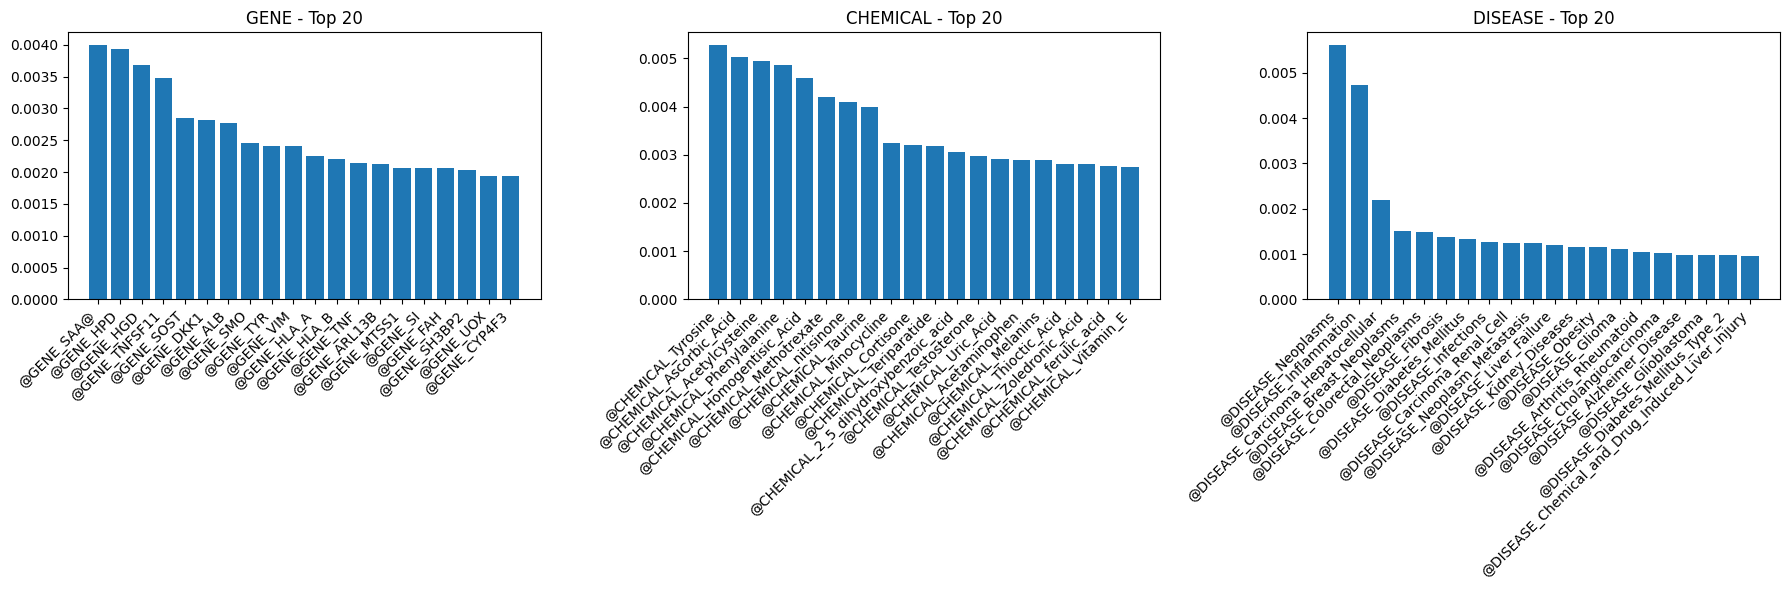

In [85]:
exPPR = ppr(extendGraph)

In [86]:
print(len(exPPR))

27251


In [142]:
pprexgraph, pprexselected = topk_subgraph_by_prefix(
    extendGraph,
    exPPR,
    k={"@CHEMICAL": 20, "@GENE": 20, "@DISEASE": 20},
    prefixes=("@CHEMICAL", "@GENE", "@DISEASE"),
    node_of_interest='@DISEASE_Alkaptonuria'
)

In [146]:
save_html_graph(pprexgraph, entity_color, relation_color, '../HTMLs/exPPRsubgraph.html')

Graph with legend saved to ../HTMLs/exPPRsubgraph.html


### High confidence 

/var/folders/01/v0p4sfw945j32p3yvg67p6cc0000gn/T/ipykernel_27313/2491794532.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(keys, rotation=45, ha="right")
/var/folders/01/v0p4sfw945j32p3yvg67p6cc0000gn/T/ipykernel_27313/2491794532.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(keys, rotation=45, ha="right")
/var/folders/01/v0p4sfw945j32p3yvg67p6cc0000gn/T/ipykernel_27313/2491794532.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(keys, rotation=45, ha="right")


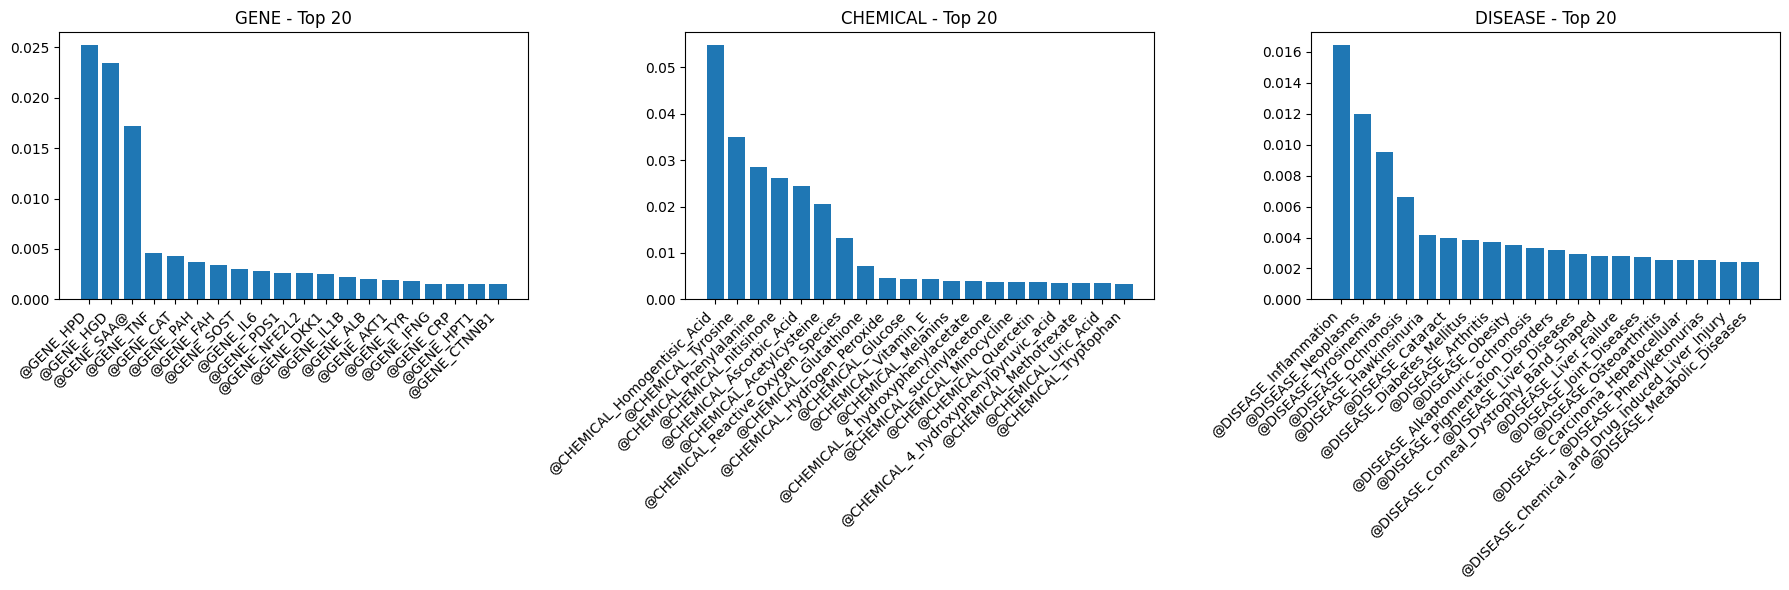

In [87]:
hiPPR = ppr(highconfgraph)

In [144]:
pprhigraph, pprhiselected = topk_subgraph_by_prefix(
    highconfgraph,
    hiPPR,
    k={"@CHEMICAL": 20, "@GENE": 20, "@DISEASE": 20},
    prefixes=("@CHEMICAL", "@GENE", "@DISEASE"),
    node_of_interest='@DISEASE_Alkaptonuria'
)

In [148]:
save_html_graph(pprhigraph, entity_color, relation_color, '../HTMLs/hiPPRsubgraph.html')

Graph with legend saved to ../HTMLs/hiPPRsubgraph.html


## Degree corrected Personalized Pagerank 

In [ ]:
import networkx as nx

def degree_corrected_ppr(G, source, alpha=0.15, weight=None, eps=1e-12):
    """
    Compute degree-corrected Personalized PageRank (PPR).

    Parameters
    ----------
    G : networkx.Graph
        The input graph (can be directed or undirected).
    source : node
        Node of interest.
    alpha : float, optional (default=0.15)
        Teleport probability. 1 - alpha = damping factor.
    weight : str or None, optional (default=None)
        Edge attribute for weights. None means unweighted.
    eps : float, optional
        Small constant to avoid division by zero.

    Returns
    -------
    dict
        Mapping of node -> degree-corrected PPR score.
    """
    # regular personalized PageRank
    pr = nx.pagerank(G, alpha=1 - alpha, personalization={source: 1.0}, weight=weight)

    # degree for correction
    deg = dict(G.degree(weight=weight))

    # degree-corrected score
    corrected = {v: pr[v] / (deg[v]** 0.5+ eps) for v in G if v in pr}

    # optional: renormalize to sum to 1
    total = sum(corrected.values())
    if total > 0:
        corrected = {v: val / total for v, val in corrected.items()}

    return corrected


### Extended graph 

In [158]:
excorPPR = degree_corrected_ppr(extendGraph, source='@DISEASE_Alkaptonuria', alpha=0.15, weight='score')

In [162]:
print(len(excorPPR))
del excorPPR['@DISEASE_Alkaptonuria']

27252


/var/folders/01/v0p4sfw945j32p3yvg67p6cc0000gn/T/ipykernel_27313/2491794532.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(keys, rotation=45, ha="right")
/var/folders/01/v0p4sfw945j32p3yvg67p6cc0000gn/T/ipykernel_27313/2491794532.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(keys, rotation=45, ha="right")
/var/folders/01/v0p4sfw945j32p3yvg67p6cc0000gn/T/ipykernel_27313/2491794532.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(keys, rotation=45, ha="right")


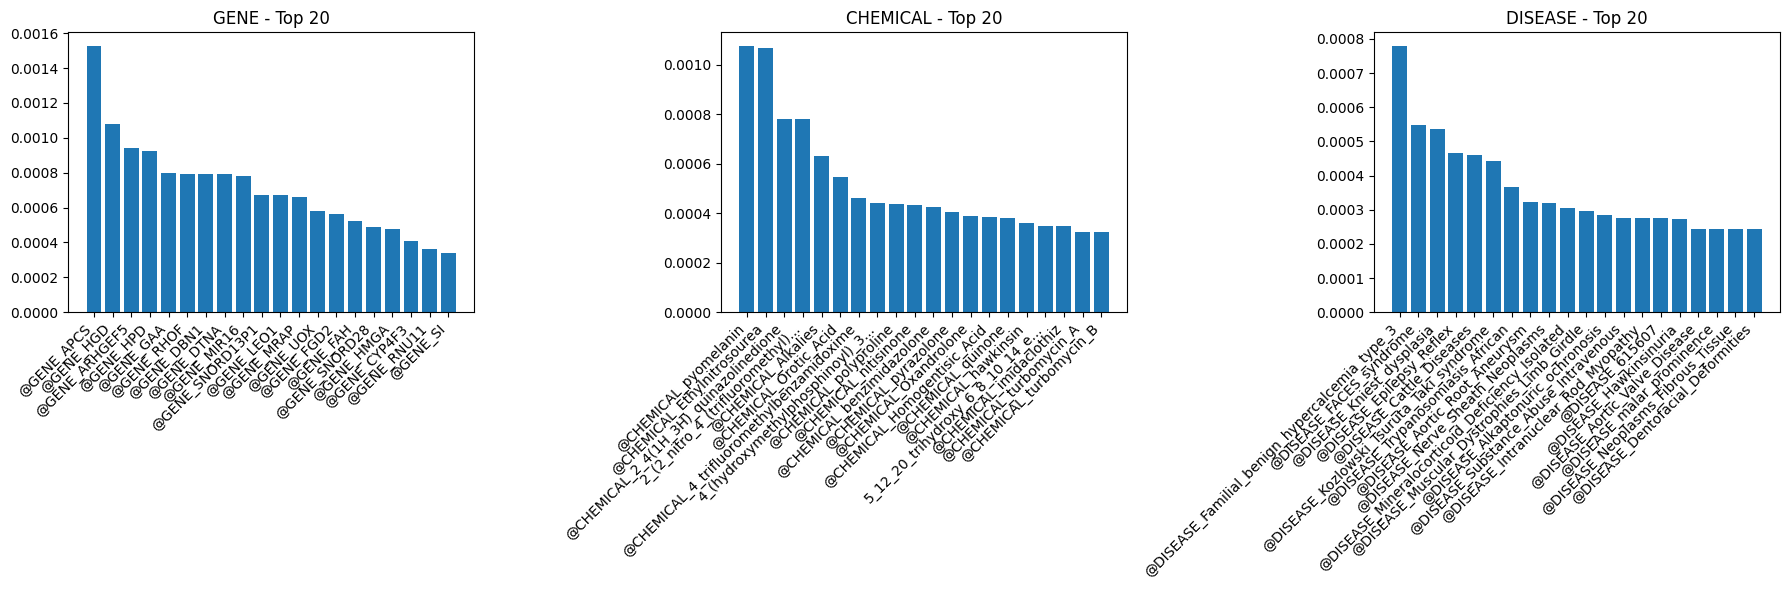

In [180]:
plot_top_k(excorPPR, k=20, title="Top-k Entities by Degree-Corrected PPR")

In [181]:
cpprexgraph, cpprexselected = topk_subgraph_by_prefix(
    extendGraph,
    excorPPR,
    k={"@CHEMICAL": 20, "@GENE": 20, "@DISEASE": 20},
    prefixes=("@CHEMICAL", "@GENE", "@DISEASE"),
    node_of_interest='@DISEASE_Alkaptonuria'
)

In [182]:
save_html_graph(cpprexgraph, entity_color, relation_color, '../HTMLs/cpprexsubgraph.html')

Graph with legend saved to ../HTMLs/cpprexsubgraph.html


### High-confidence network 

In [166]:
hicorPPR = degree_corrected_ppr(highconfgraph, source='@DISEASE_Alkaptonuria', alpha=0.15, weight='score')

In [167]:
del hicorPPR['@DISEASE_Alkaptonuria']

/var/folders/01/v0p4sfw945j32p3yvg67p6cc0000gn/T/ipykernel_27313/2491794532.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(keys, rotation=45, ha="right")
/var/folders/01/v0p4sfw945j32p3yvg67p6cc0000gn/T/ipykernel_27313/2491794532.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(keys, rotation=45, ha="right")
/var/folders/01/v0p4sfw945j32p3yvg67p6cc0000gn/T/ipykernel_27313/2491794532.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(keys, rotation=45, ha="right")


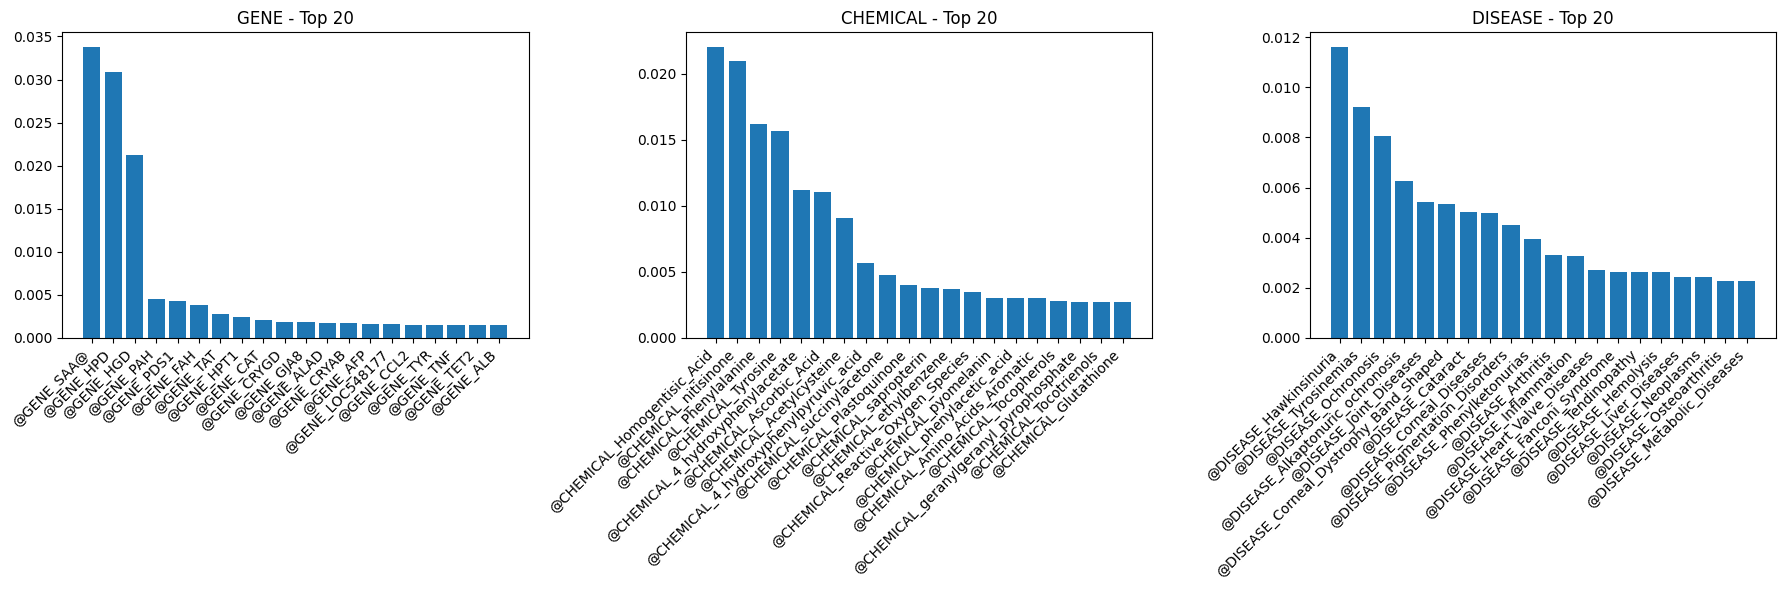

In [168]:
plot_top_k(hicorPPR, k=20, title="Top-k Entities by Degree-Corrected PPR")

In [183]:
cpprhigraph, cpprhiselected = topk_subgraph_by_prefix(
    highconfgraph,
    hicorPPR,
    k={"@CHEMICAL": 20, "@GENE": 20, "@DISEASE": 20},
    prefixes=("@CHEMICAL", "@GENE", "@DISEASE"),
    node_of_interest='@DISEASE_Alkaptonuria'
)

In [184]:
save_html_graph(cpprhigraph, entity_color, relation_color, '../HTMLs/cpprhigraph.html')

Graph with legend saved to ../HTMLs/cpprhigraph.html


## Maximum flow

### Define functions 

In [ ]:
import networkx as nx

def compute_max_flow_to_target_disease(G, target_disease, disease_prefix='@', weight='score', switch=False):
    """
    Compute maximum flow from each other disease node to a target disease in a directed, weighted graph.

    Parameters:
    - G: NetworkX DiGraph
    - target_disease: node name of the disease of interest (sink)
    - disease_prefix: prefix to identify disease nodes (default: '@DISEASE')
    - weight: edge weight attribute used as capacity (default: 'weight')

    Returns:
    - flow_results: dict {source_disease: max_flow_value}
    """
    if not G.is_directed():
        raise ValueError("Graph must be directed.")
    if target_disease not in G:
        raise ValueError("Target disease not found in graph.")

    flow_results = {}

    # Identify all disease nodes except the target
    source_diseases = [
        node for node in G.nodes()
        if str(node).startswith(disease_prefix) and node != target_disease
    ]
    counter = 0
    for source in source_diseases:
        if counter%101 == 0:
            print(f"Processing node {source} - {counter}-th")
        counter += 1
        try:
            if switch:
                # Switch source and target for max flow calculation
                flow_value, _ = nx.maximum_flow(G, target_disease, source, capacity=weight)
            else:
                # Normal max flow calculation
                flow_value, _ = nx.maximum_flow(G, source, target_disease, capacity=weight)
            flow_results[source] = flow_value
        except (nx.NetworkXError, nx.NetworkXUnfeasible):
            flow_results[source] = 0.0

    print("Maximum flow values to @DISEASE_Alkaptonuria:")
    # geneppr.items(), key=lambda item: item[1], reverse=True 
    flowtoalgene = dict()
    flowtoalchem = dict()
    flowtoaldi = dict()
    for node, flow in dict(sorted(flow_results.items(), key=lambda item: item[1], reverse=True)).items():
        if node.startswith("@GENE"):
            flowtoalgene[node] = flow 
        if node.startswith("@CHEMICAL"):
            flowtoalchem[node] = flow
        if node.startswith("@DISEASE") and node != '@DISEASE_Alkaptonuria':
            flowtoaldi[node] = flow
            
    plot_top_20_entities_3dicts(flowtoalgene, flowtoalchem, flowtoaldi)
    return flow_results


### Extend network 

In [ ]:
exflow = compute_max_flow_to_target_disease(
    extendGraph.to_directed(),
    target_disease='@DISEASE_Alkaptonuria',
    disease_prefix='@',
    weight='score'
)

### High confidence network

In [ ]:
hiflow = compute_max_flow_to_target_disease(
    highconfgraph.to_directed(),
    target_disease='@DISEASE_Alkaptonuria',
    disease_prefix='@',
    weight='score'
)

In [ ]:
print(hiflow)

## Personalized Katz centrality

In [88]:
"""
Personalized Katz centrality

Dependencies: networkx, numpy

Usage example:
    G = nx.karate_club_graph()
    p = {n: 1.0 if n == 0 else 0.0 for n in G.nodes()}  # personalize on node 0
    scores = personalized_katz(G, personalization=p, alpha=None, beta=1.0, method='power')
    # scores is a dict mapping node -> Katz score
"""

import networkx as nx
import numpy as np

def personalized_katz(G,
                      personalization,
                      alpha=None,
                      beta=1.0,
                      tol=1e-8,
                      max_iter=10000,
                      method='power',
                      normalize=False,
                      verbose=False):
    """
    Compute personalized Katz centrality for graph G.

    Parameters
    ----------
    G : networkx.Graph or DiGraph
        Input graph. If directed, adjacency respects direction.
    personalization : dict
        Mapping node -> nonnegative weight (not necessarily normalized). At least one node
        must have positive weight.
    alpha : float or None
        Decay/attenuation factor. If None, a conservative default is chosen:
        alpha = 0.95 / lambda_max (if lambda_max can be computed); otherwise 0.1.
        Must satisfy alpha < 1/lambda_max for convergence in the linear-solve formula.
    beta : float
        Scaling factor multiplied to the personalization vector (default 1.0).
    tol : float
        Tolerance for iterative method convergence.
    max_iter : int
        Maximum iterations for iterative method.
    method : {'solve', 'power'}
        'solve'    : solve (I - alpha A) x = beta p with np.linalg.solve (exact).
        'power'    : iterate x_{t+1} = alpha A x_t + beta p until convergence.
    normalize : bool
        If True, returns scores normalized to sum to 1.
    verbose : bool
        If True, print progress / warnings.

    Returns
    -------
    scores : dict
        Mapping node -> personalized Katz score (float).

    Notes
    -----
    - The personalization dict will be mapped to the adjacency ordering of nodes.
    - For large graphs with thousands of nodes, 'power' is recommended.
    - If alpha is too large (>= 1/lambda_max), the linear solve diverges; the function
      will raise an error in that case (for 'solve') or may not converge for 'power'.
    """
    if len(G) == 0:
        return {}

    # Establish node ordering
    nodes = list(G.nodes())
    n = len(nodes)
    node_index = {node: i for i, node in enumerate(nodes)}

    # build personalization vector p (in node order)
    p_vec = np.zeros(n, dtype=float)
    found_positive = False
    for node, weight in personalization.items():
        if node not in node_index:
            raise KeyError(f"Personalization contains node {node!r} not in graph G.")
        idx = node_index[node]
        p_vec[idx] = float(weight)
        if weight > 0:
            found_positive = True
    if not found_positive:
        raise ValueError("Personalization vector must have at least one positive weight.")

    # Normalize p to sum 1 if you want relative personalization (optional)
    # but we keep raw p and scale by beta as specified
    # p_vec = p_vec / p_vec.sum()  # uncomment if you want automatic normalization

    # adjacency matrix (dense)
    A = nx.to_numpy_array(G, nodelist=nodes, dtype=float)

    # estimate spectral radius (largest eigenvalue) if feasible
    lambda_max = None
    try:
        # small-to-medium graphs: compute full eigenvalues
        if n <= 500:
            eigs = np.linalg.eigvals(A)
            lambda_max = max(np.abs(eigs))
        else:
            # for larger graphs we try a power-iteration approximation once
            # simple power-iteration:
            b = np.random.rand(n)
            b = b / np.linalg.norm(b)
            for _ in range(50):
                b = A.dot(b)
                normb = np.linalg.norm(b)
                if normb == 0:
                    break
                b = b / normb
            # Rayleigh quotient
            Ab = A.dot(b)
            lambda_max = float(np.dot(b, Ab))
    except Exception as e:
        if verbose:
            print("Warning: could not estimate spectral radius reliably:", e)
        lambda_max = None

    # choose default alpha if not provided
    if alpha is None:
        if lambda_max and lambda_max > 0:
            # conservative multiplier to stay well within convergence radius
            alpha = 0.95 / lambda_max
            if verbose:
                print(f"alpha not provided: set alpha = 0.95 / lambda_max = {alpha:.6g}")
        else:
            alpha = 0.1
            if verbose:
                print("alpha not provided and spectral radius unknown: using alpha = 0.1")

    # warn if alpha might be too large
    if lambda_max and alpha >= 1.0 / lambda_max:
        raise ValueError(f"alpha must be < 1/lambda_max (~ {1.0/lambda_max:.6g}); got alpha={alpha}")

    # Solve by linear algebra: x = beta * (I - alpha A)^{-1} p
    if method == 'solve':
        I = np.eye(n)
        try:
            M = I - alpha * A
            # solve M x = beta * p_vec
            rhs = beta * p_vec
            x = np.linalg.solve(M, rhs)
        except np.linalg.LinAlgError as e:
            raise RuntimeError("Linear solve failed; matrix may be singular or alpha too large.") from e

    # Iterative power method: x_{t+1} = alpha A x_t + beta p
    elif method == 'power':
        x = np.zeros(n, dtype=float)
        rhs = beta * p_vec
        for it in range(1, max_iter + 1):
            x_new = alpha * A.dot(x) + rhs
            err = np.linalg.norm(x_new - x, ord=1)
            x = x_new
            if err < tol:
                if verbose:
                    print(f"Converged after {it} iterations (L1 change = {err:.3e}).")
                break
        else:
            if verbose:
                print(f"Warning: power method did not converge after {max_iter} iterations (last err={err:.3e}).")
    else:
        raise ValueError("method must be 'solve' or 'power'")

    # map back to nodes
    scores = {node: float(x[node_index[node]]) for node in nodes}

    if normalize:
        s = sum(scores.values())
        if s > 0:
            scores = {k: v / s for k, v in scores.items()}

    return scores


In [89]:
def getPersonal(G):
    personalization = {n: 1.0 if n == '@DISEASE_Alkaptonuria' else 0.0 for n in G.nodes()}
    return personalization

### Extended network

In [90]:
personalization = getPersonal(extendGraph)
perkatz = personalized_katz(extendGraph, personalization, verbose=True)

alpha not provided: set alpha = 0.95 / lambda_max = 0.0046578
Converged after 349 iterations (L1 change = 9.920e-09).


In [91]:
del perkatz['@DISEASE_Alkaptonuria']

/var/folders/01/v0p4sfw945j32p3yvg67p6cc0000gn/T/ipykernel_27313/2491794532.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(keys, rotation=45, ha="right")
/var/folders/01/v0p4sfw945j32p3yvg67p6cc0000gn/T/ipykernel_27313/2491794532.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(keys, rotation=45, ha="right")
/var/folders/01/v0p4sfw945j32p3yvg67p6cc0000gn/T/ipykernel_27313/2491794532.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(keys, rotation=45, ha="right")


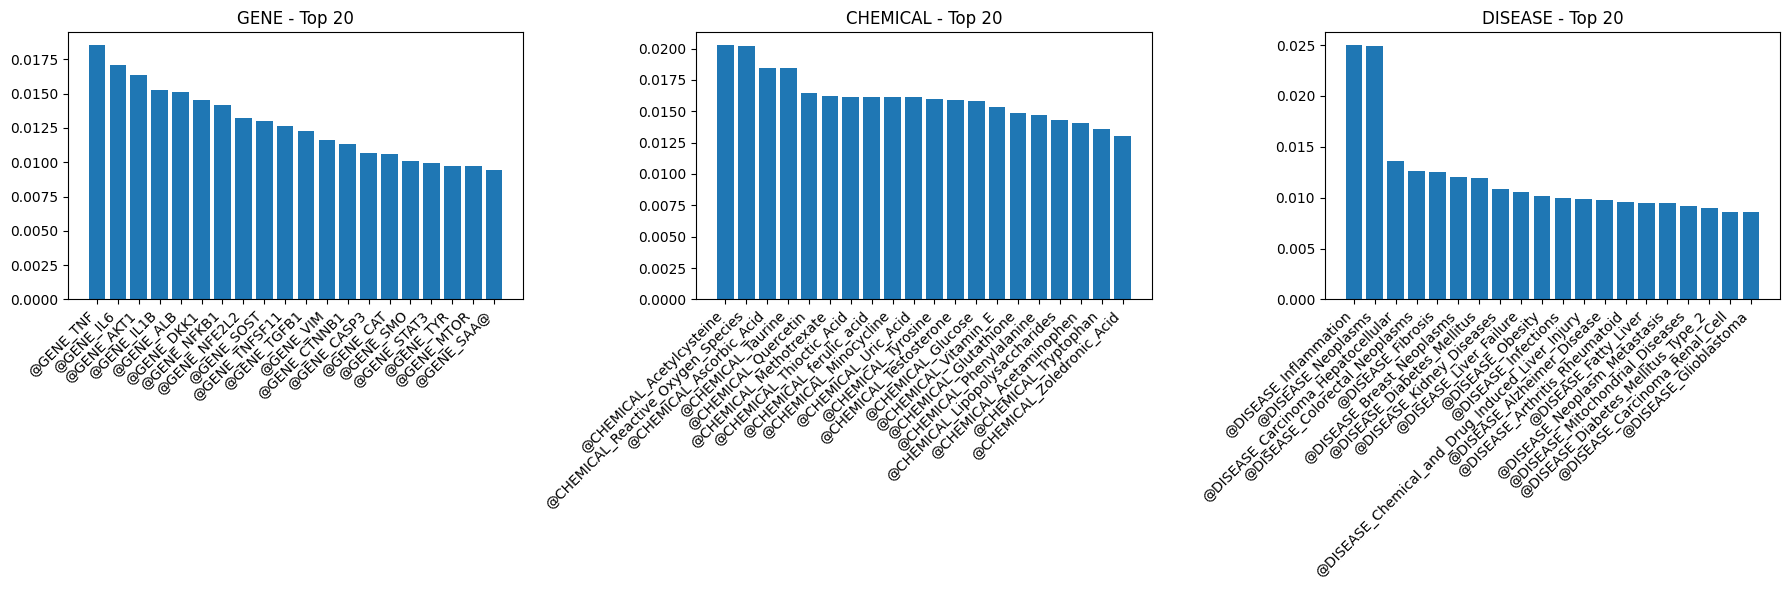

In [92]:
genekatz, chemkatz, dikatz = separateTypes(perkatz)
plot_top_20_entities_3dicts(genekatz, chemkatz, dikatz)

In [150]:
katzexgraph, katzexselected = topk_subgraph_by_prefix(
    extendGraph,
    perkatz,
    k={"@CHEMICAL": 20, "@GENE": 20, "@DISEASE": 20},
    prefixes=("@CHEMICAL", "@GENE", "@DISEASE"),
    node_of_interest='@DISEASE_Alkaptonuria'
)

In [154]:
save_html_graph(katzexgraph, entity_color, relation_color, '../HTMLs/exKatzsubgraph.html')

Graph with legend saved to ../HTMLs/exKatzsubgraph.html


### High-confidence network 

In [93]:
hipersonalization = getPersonal(highconfgraph)
hiperkatz = personalized_katz(highconfgraph, hipersonalization, verbose=True)

alpha not provided: set alpha = 0.95 / lambda_max = 0.0405739
Converged after 339 iterations (L1 change = 9.623e-09).


In [94]:
del hiperkatz['@DISEASE_Alkaptonuria']

/var/folders/01/v0p4sfw945j32p3yvg67p6cc0000gn/T/ipykernel_27313/2491794532.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(keys, rotation=45, ha="right")
/var/folders/01/v0p4sfw945j32p3yvg67p6cc0000gn/T/ipykernel_27313/2491794532.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(keys, rotation=45, ha="right")
/var/folders/01/v0p4sfw945j32p3yvg67p6cc0000gn/T/ipykernel_27313/2491794532.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(keys, rotation=45, ha="right")


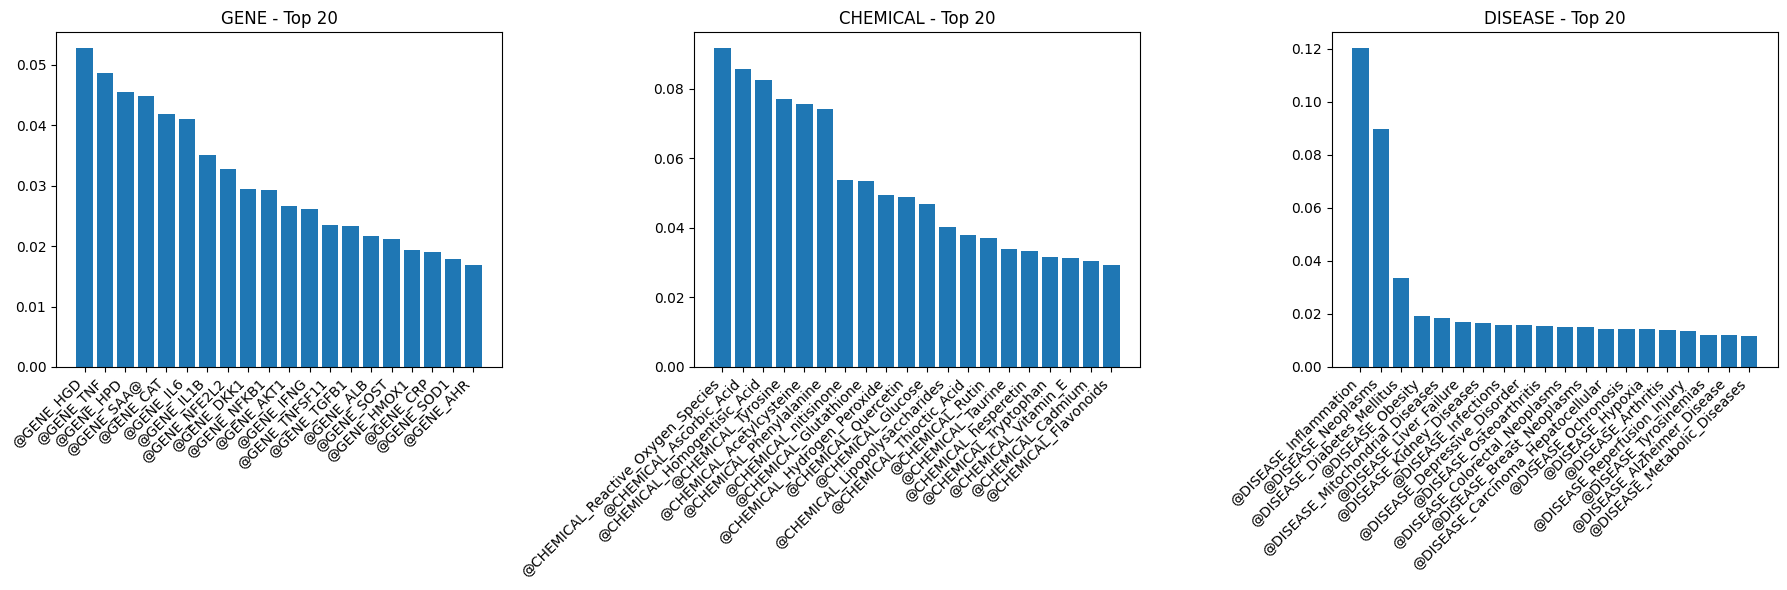

In [95]:
higenekatz, hichemkatz, hidikatz = separateTypes(hiperkatz)
plot_top_20_entities_3dicts(higenekatz, hichemkatz, hidikatz)

In [ ]:
katzhigraph, katzhiselected = topk_subgraph_by_prefix(
    highconfgraph,
    hiperkatz,
    k={"@CHEMICAL": 20, "@GENE": 20, "@DISEASE": 20},
    prefixes=("@CHEMICAL", "@GENE", "@DISEASE"),
    node_of_interest='@DISEASE_Alkaptonuria'
)
save_html_graph(katzhigraph, entity_color, relation_color, '../HTMLs/hiKatzsubgraph.html')

In [156]:
save_html_graph(katzhigraph, entity_color, relation_color, '../HTMLs/hiKatzsubgraph.html')

Graph with legend saved to ../HTMLs/hiKatzsubgraph.html


## Corrected Katz

In [186]:
import networkx as nx
import numpy as np

def normalize_katz_by_degree(G, katz_scores, power=1.0, eps=1e-12):
    """
    Normalize personalized Katz centrality scores by node degree.

    Parameters
    ----------
    G : networkx.Graph
        The input graph.
    katz_scores : dict
        Mapping {node: katz_score}.
    power : float, optional (default=1.0)
        Exponent for degree correction. 
        - 1.0  -> divide by degree (strong correction)
        - 0.5  -> divide by sqrt(degree) (moderate correction)
        - 0.0  -> no correction.
    eps : float, optional
        Small constant to avoid division by zero.

    Returns
    -------
    dict
        Degree-corrected and normalized Katz scores.
    """
    deg = dict(G.degree())
    corrected = {v: katz_scores[v] / (deg[v] ** power + eps) for v in katz_scores}

    # optional: rescale to sum to 1
    total = sum(corrected.values())
    if total > 0:
        corrected = {v: val / total for v, val in corrected.items()}
    return corrected


### Extended graph

In [200]:
exCorKatz = normalize_katz_by_degree(extendGraph, perkatz, power=0.5)

/var/folders/01/v0p4sfw945j32p3yvg67p6cc0000gn/T/ipykernel_27313/2491794532.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(keys, rotation=45, ha="right")
/var/folders/01/v0p4sfw945j32p3yvg67p6cc0000gn/T/ipykernel_27313/2491794532.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(keys, rotation=45, ha="right")
/var/folders/01/v0p4sfw945j32p3yvg67p6cc0000gn/T/ipykernel_27313/2491794532.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(keys, rotation=45, ha="right")


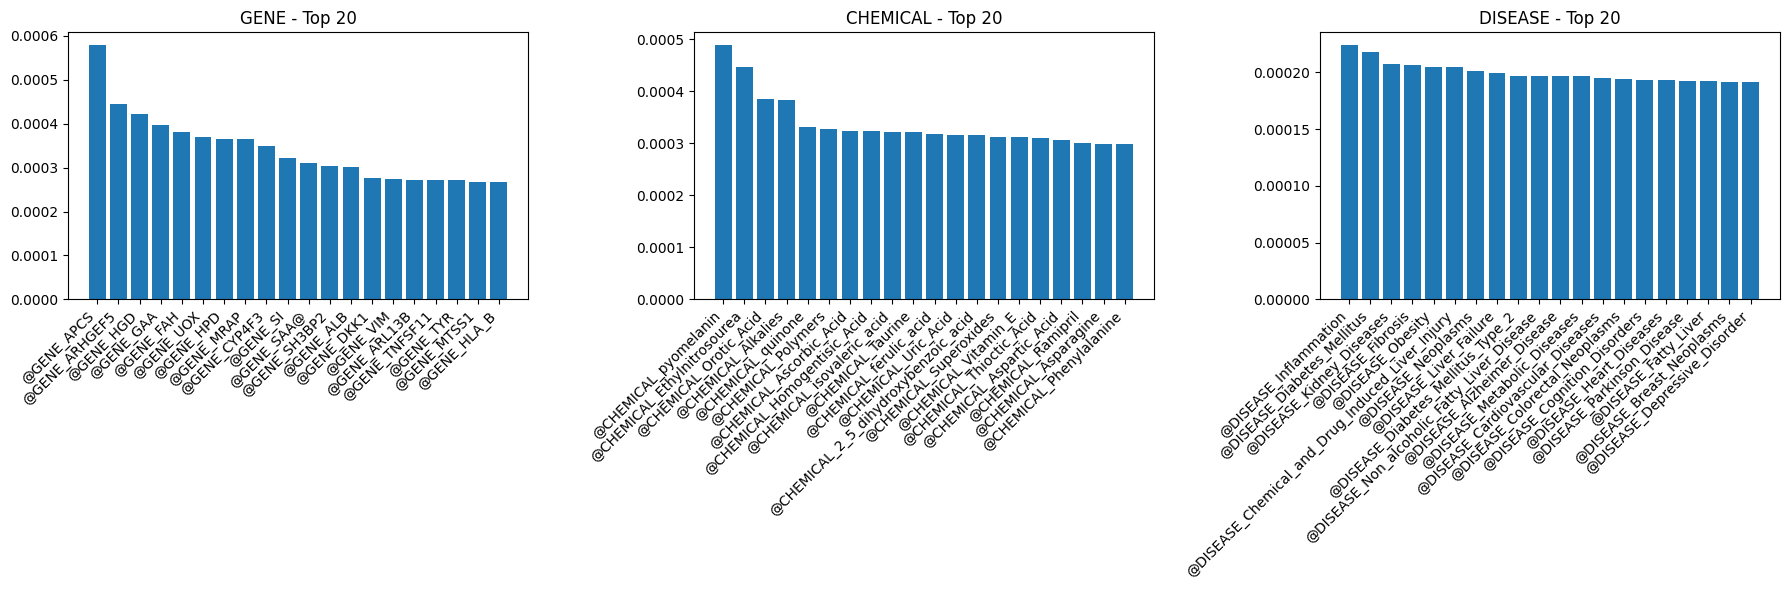

In [201]:
plot_top_k(exCorKatz, k=20, title="Top-k Entities by Degree-Corrected Personalized Katz Centrality")

In [204]:
ckatzexgraph, ckatzexselected = topk_subgraph_by_prefix(
    extendGraph,
    exCorKatz,
    k={"@CHEMICAL": 20, "@GENE": 20, "@DISEASE": 20},
    prefixes=("@CHEMICAL", "@GENE", "@DISEASE"),
    node_of_interest='@DISEASE_Alkaptonuria'
)
save_html_graph(ckatzexgraph, entity_color, relation_color, '../HTMLs/cKatzsubgraph.html')

Graph with legend saved to ../HTMLs/cKatzsubgraph.html


### High-confidence

In [202]:
hiCorKatz = normalize_katz_by_degree(highconfgraph, hiperkatz, power=0.5)

/var/folders/01/v0p4sfw945j32p3yvg67p6cc0000gn/T/ipykernel_27313/2491794532.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(keys, rotation=45, ha="right")
/var/folders/01/v0p4sfw945j32p3yvg67p6cc0000gn/T/ipykernel_27313/2491794532.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(keys, rotation=45, ha="right")
/var/folders/01/v0p4sfw945j32p3yvg67p6cc0000gn/T/ipykernel_27313/2491794532.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(keys, rotation=45, ha="right")


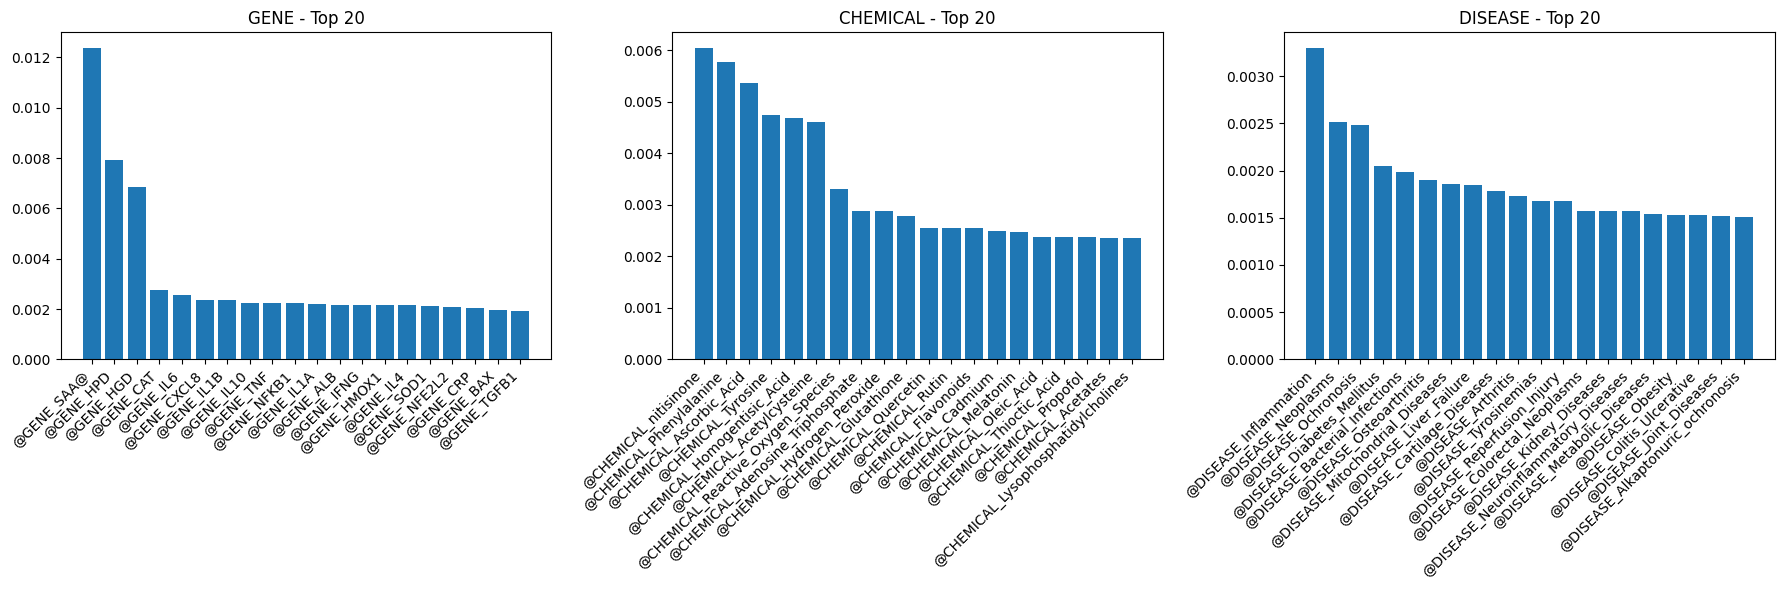

In [203]:
plot_top_k(hiCorKatz, k=20, title="Top-k Entities by Degree-Corrected Personalized Katz Centrality")

In [205]:
ckatzhigraph, ckatzhiselected = topk_subgraph_by_prefix(
    highconfgraph,
    hiCorKatz,
    k={"@CHEMICAL": 20, "@GENE": 20, "@DISEASE": 20},
    prefixes=("@CHEMICAL", "@GENE", "@DISEASE"),
    node_of_interest='@DISEASE_Alkaptonuria'
)
save_html_graph(ckatzhigraph, entity_color, relation_color, '../HTMLs/hicKatzsubgraph.html')

Graph with legend saved to ../HTMLs/hicKatzsubgraph.html


## Local

In [192]:
import networkx as nx

def jaccard_scores(G, u):
    # returns dict v -> Jaccard(u,v)
    preds = nx.jaccard_coefficient(G, [(u, v) for v in G if v != u and not G.has_edge(u, v)])
    return {v: p for _, v, p in preds}

def adamic_adar_scores(G, u):
    preds = nx.adamic_adar_index(G, [(u, v) for v in G if v != u and not G.has_edge(u, v)])
    return {v: p for _, v, p in preds}

def resource_allocation_scores(G, u):
    preds = nx.resource_allocation_index(G, [(u, v) for v in G if v != u and not G.has_edge(u, v)])
    return {v: p for _, v, p in preds}


### Extend

/var/folders/01/v0p4sfw945j32p3yvg67p6cc0000gn/T/ipykernel_27313/2491794532.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(keys, rotation=45, ha="right")
/var/folders/01/v0p4sfw945j32p3yvg67p6cc0000gn/T/ipykernel_27313/2491794532.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(keys, rotation=45, ha="right")
/var/folders/01/v0p4sfw945j32p3yvg67p6cc0000gn/T/ipykernel_27313/2491794532.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(keys, rotation=45, ha="right")


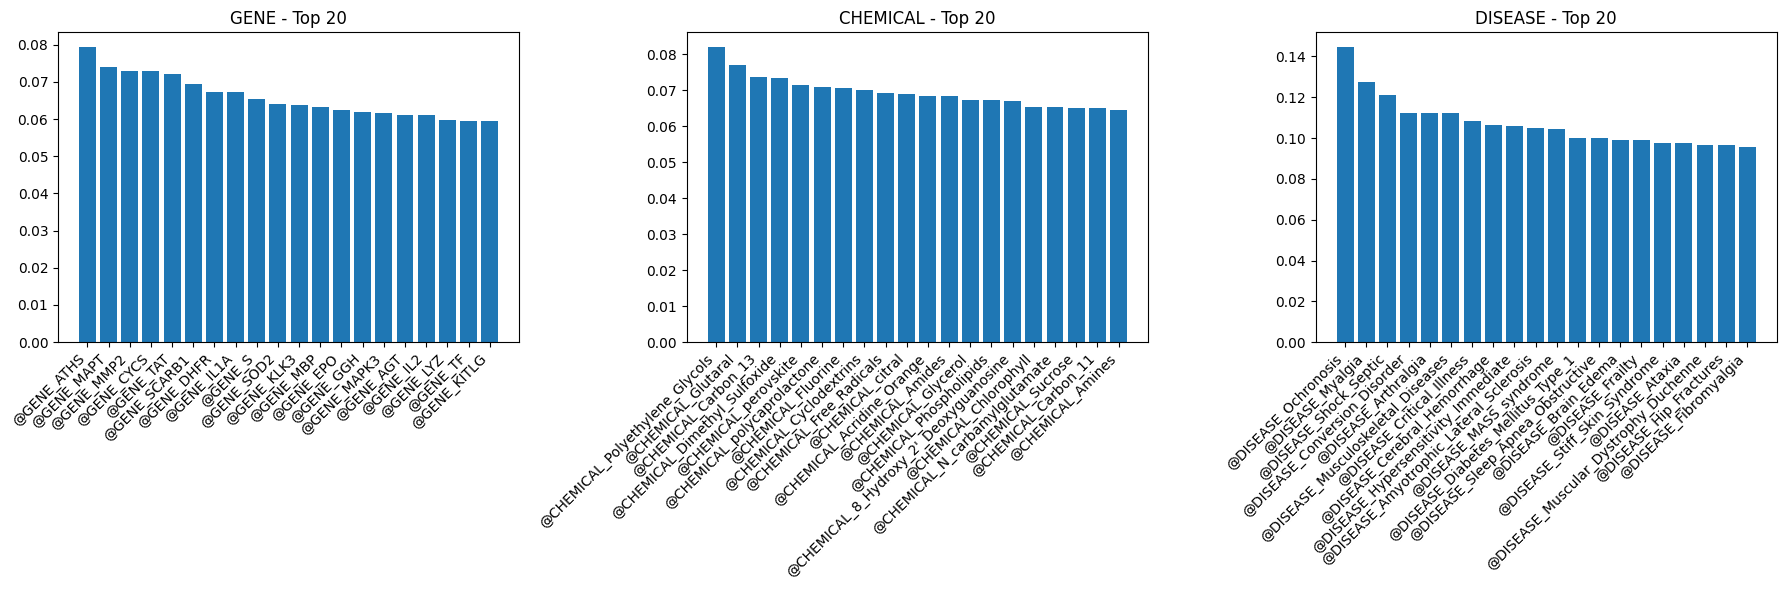

In [194]:
jaccex = jaccard_scores(extendGraph, '@DISEASE_Alkaptonuria')
# del jaccex['@DISEASE_Alkaptonuria']
plot_top_k(jaccex, k=20, title="Top-k Entities by Jaccard Score")

/var/folders/01/v0p4sfw945j32p3yvg67p6cc0000gn/T/ipykernel_27313/2491794532.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(keys, rotation=45, ha="right")
/var/folders/01/v0p4sfw945j32p3yvg67p6cc0000gn/T/ipykernel_27313/2491794532.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(keys, rotation=45, ha="right")
/var/folders/01/v0p4sfw945j32p3yvg67p6cc0000gn/T/ipykernel_27313/2491794532.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(keys, rotation=45, ha="right")


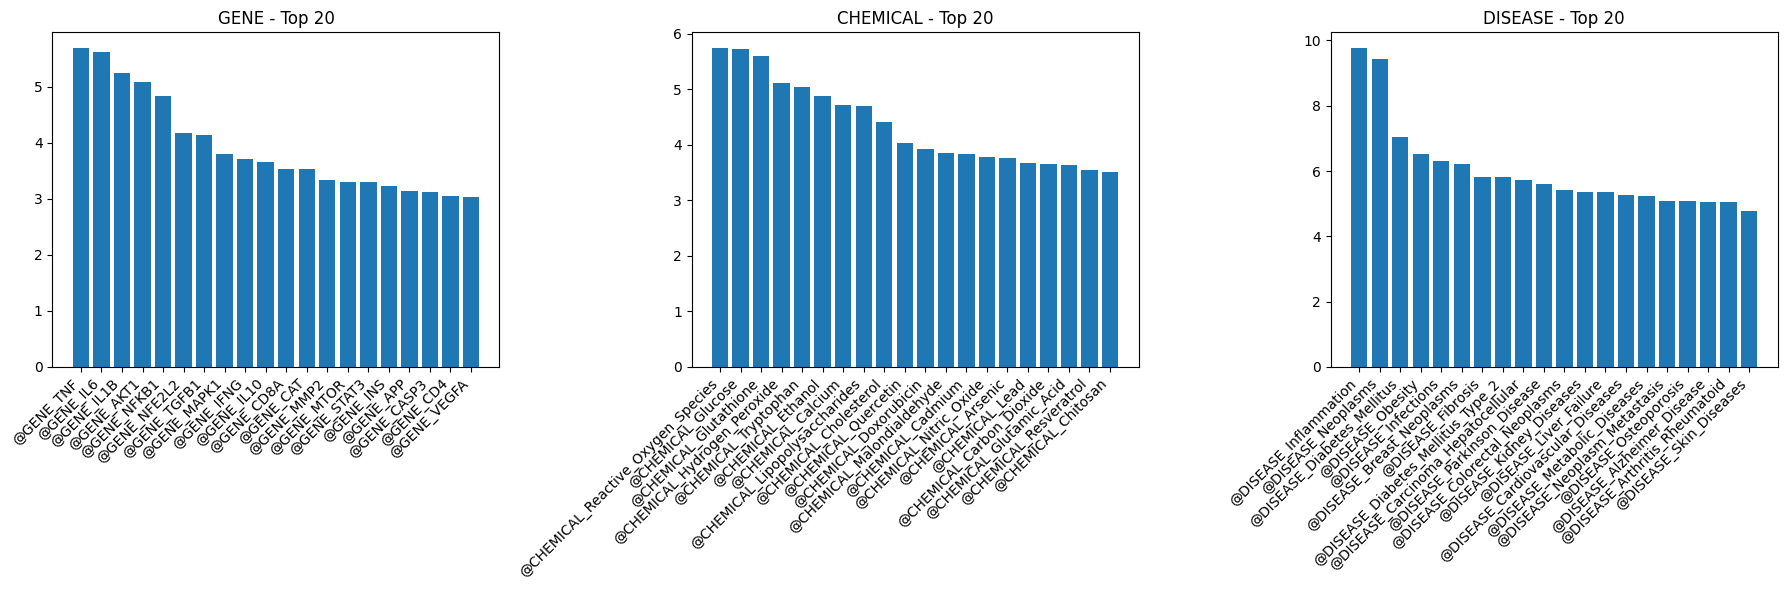

In [195]:
aaex = adamic_adar_scores(extendGraph, '@DISEASE_Alkaptonuria')
# del aaex['@DISEASE_Alkaptonuria']
plot_top_k(aaex, k=20, title="Top-k Entities by Adamic-Adar Score")

/var/folders/01/v0p4sfw945j32p3yvg67p6cc0000gn/T/ipykernel_27313/2491794532.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(keys, rotation=45, ha="right")
/var/folders/01/v0p4sfw945j32p3yvg67p6cc0000gn/T/ipykernel_27313/2491794532.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(keys, rotation=45, ha="right")
/var/folders/01/v0p4sfw945j32p3yvg67p6cc0000gn/T/ipykernel_27313/2491794532.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(keys, rotation=45, ha="right")


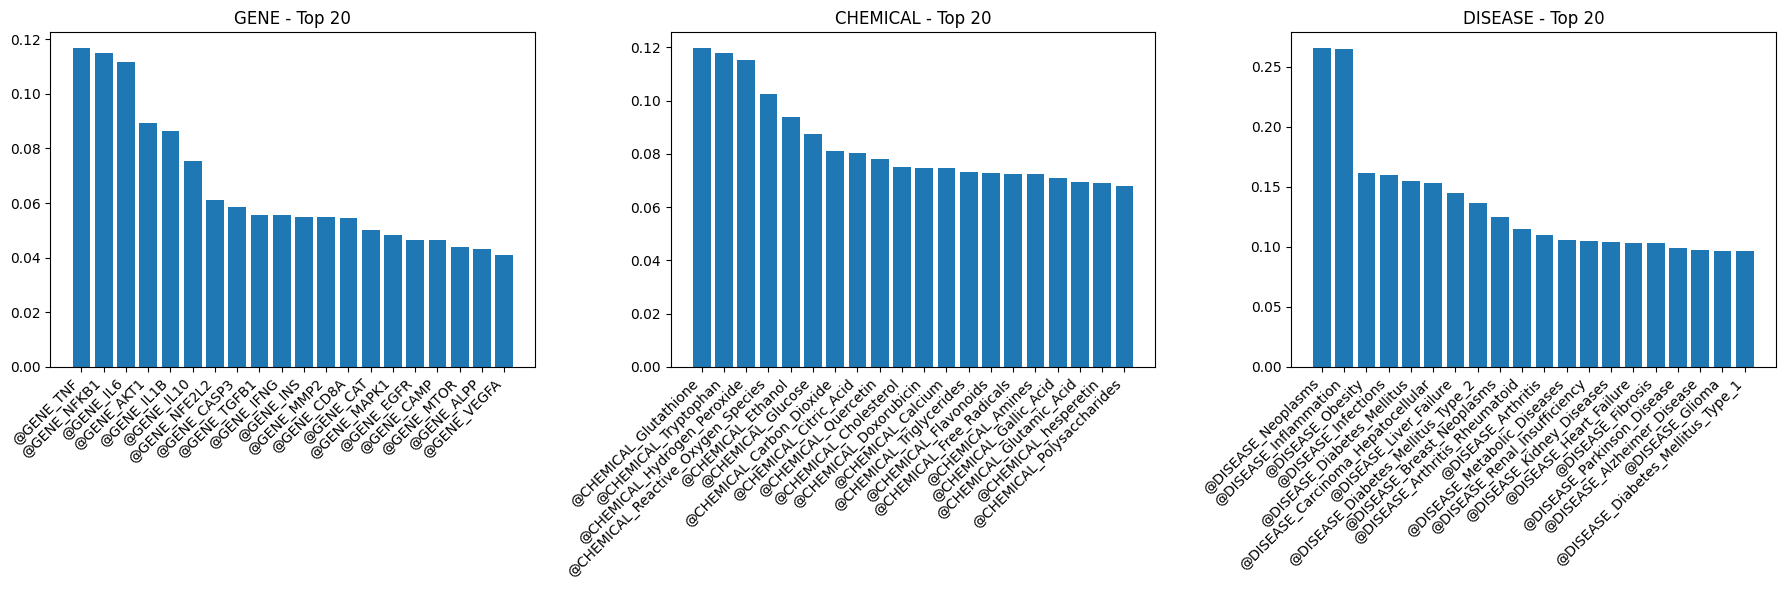

In [196]:
RAex = resource_allocation_scores(extendGraph, '@DISEASE_Alkaptonuria')
# del RAex['@DISEASE_Alkaptonuria']
plot_top_k(RAex, k=20, title="Top-k Entities by Resource Allocation Score")

### High-confidence 

/var/folders/01/v0p4sfw945j32p3yvg67p6cc0000gn/T/ipykernel_27313/2491794532.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(keys, rotation=45, ha="right")
/var/folders/01/v0p4sfw945j32p3yvg67p6cc0000gn/T/ipykernel_27313/2491794532.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(keys, rotation=45, ha="right")
/var/folders/01/v0p4sfw945j32p3yvg67p6cc0000gn/T/ipykernel_27313/2491794532.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(keys, rotation=45, ha="right")


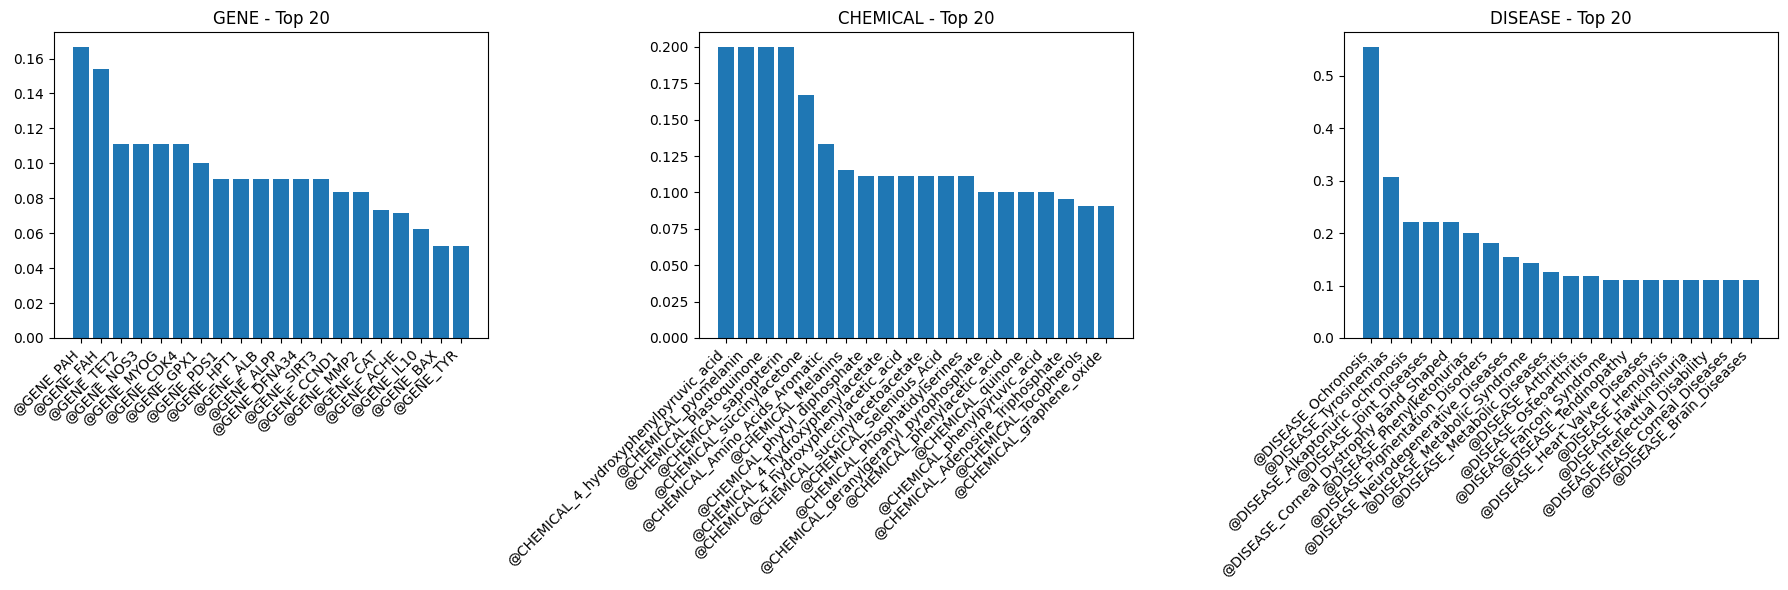

In [197]:
hijacc = jaccard_scores(highconfgraph, '@DISEASE_Alkaptonuria')
# del hijacc['@DISEASE_Alkaptonuria']
plot_top_k(hijacc, k=20, title="Top-k Entities by Jaccard Score")

/var/folders/01/v0p4sfw945j32p3yvg67p6cc0000gn/T/ipykernel_27313/2491794532.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(keys, rotation=45, ha="right")
/var/folders/01/v0p4sfw945j32p3yvg67p6cc0000gn/T/ipykernel_27313/2491794532.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(keys, rotation=45, ha="right")
/var/folders/01/v0p4sfw945j32p3yvg67p6cc0000gn/T/ipykernel_27313/2491794532.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(keys, rotation=45, ha="right")


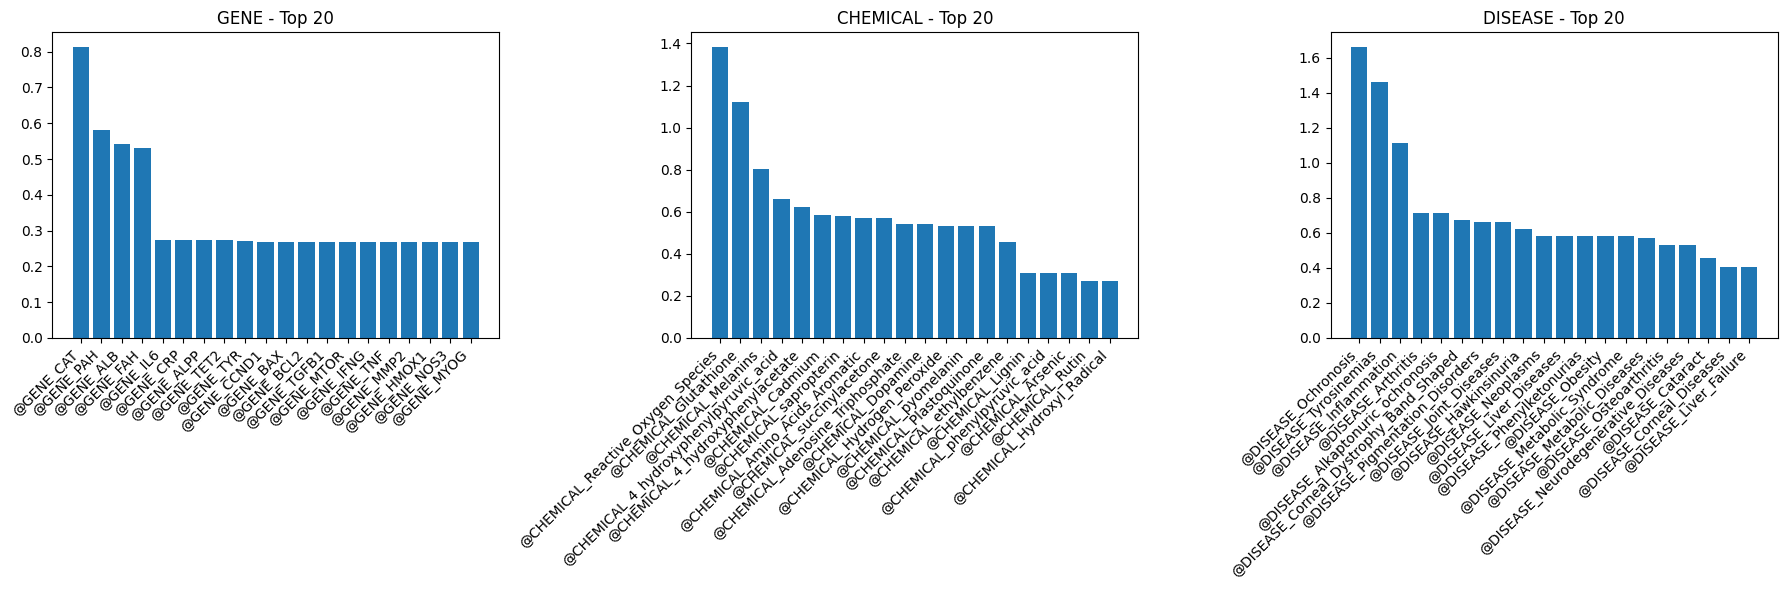

In [198]:
hiaa = adamic_adar_scores(highconfgraph, '@DISEASE_Alkaptonuria')
# del hiaa['@DISEASE_Alkaptonuria']
plot_top_k(hiaa, k=20, title="Top-k Entities by Adamic-Adar Score")

/var/folders/01/v0p4sfw945j32p3yvg67p6cc0000gn/T/ipykernel_27313/2491794532.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(keys, rotation=45, ha="right")
/var/folders/01/v0p4sfw945j32p3yvg67p6cc0000gn/T/ipykernel_27313/2491794532.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(keys, rotation=45, ha="right")
/var/folders/01/v0p4sfw945j32p3yvg67p6cc0000gn/T/ipykernel_27313/2491794532.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(keys, rotation=45, ha="right")


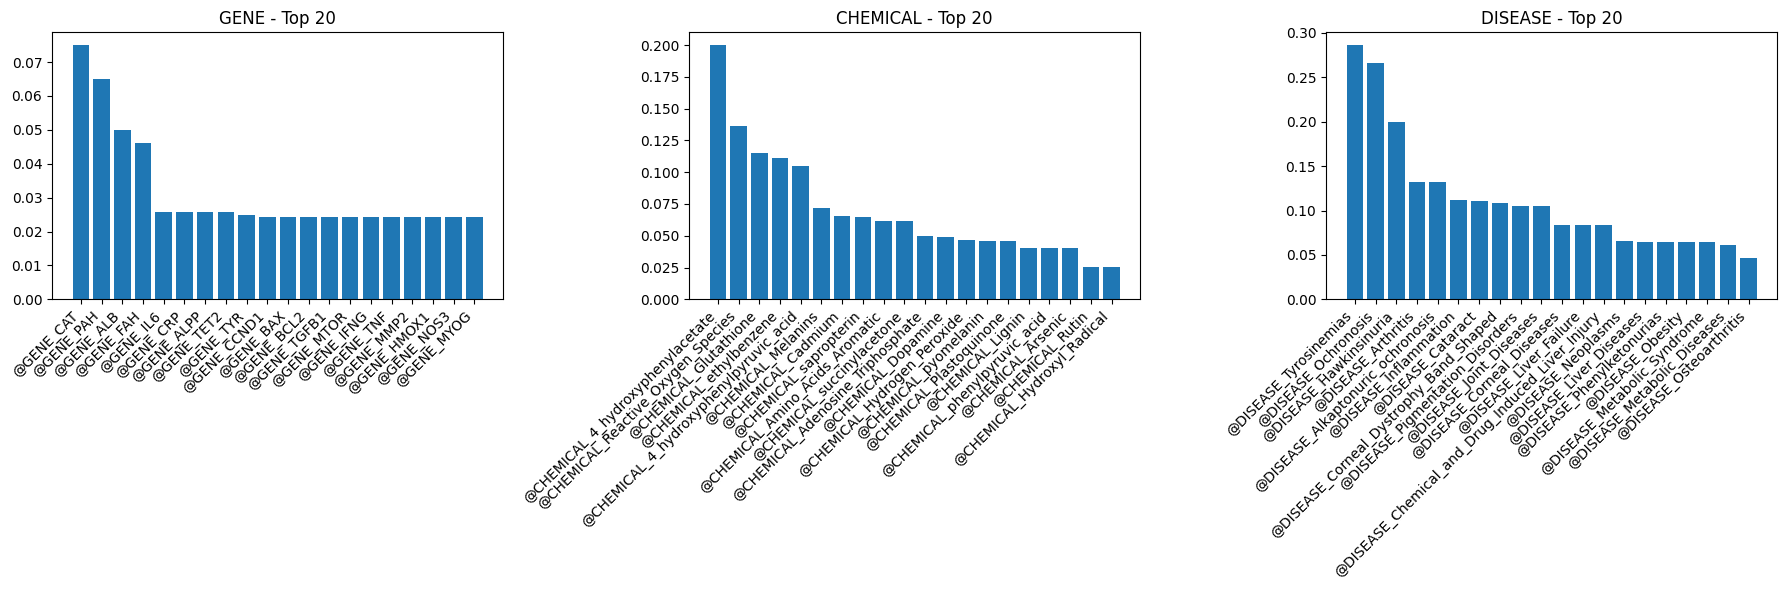

In [199]:
hira = resource_allocation_scores(highconfgraph, '@DISEASE_Alkaptonuria')
# del hira['@DISEASE_Alkaptonuria']
plot_top_k(hira, k=20, title="Top-k Entities by Resource Allocation Score")

## Betweenness 

In [ ]:
import networkx as nx
from collections import defaultdict

def top_pairs_by_betweenness_contribution(G, node_of_interest, top_k=20):
    """
    Find node pairs (s, t) whose shortest paths most rely on the given node.

    Parameters
    ----------
    G : networkx.Graph
        Undirected graph
    node_of_interest : node
        The node whose pairwise betweenness contributions we want
    top_k : int
        Number of top pairs to return

    Returns
    -------
    contributions : list of tuples
        ( (s, t), fraction_through_node )
        Sorted by descending contribution
    """

    if node_of_interest not in G:
        raise ValueError(f"{node_of_interest} not in graph")

    contributions = []
    nodes = list(G.nodes())

    # iterate over all unique pairs (s, t)
    for i, s in enumerate(nodes):
        for t in nodes[i+1:]:
            if s == node_of_interest or t == node_of_interest:
                continue
            try:
                # all shortest paths between s and t
                all_paths = list(nx.all_shortest_paths(G, s, t))
                total_paths = len(all_paths)
                # count how many go through node_of_interest
                through = sum(1 for p in all_paths if node_of_interest in p[1:-1])
                if through > 0:
                    frac = through / total_paths
                    contributions.append(((s, t), frac))
            except nx.NetworkXNoPath:
                continue

    # sort by contribution descending
    contributions.sort(key=lambda x: x[1], reverse=True)
    return contributions[:top_k]

# # Example usage:
# # G = your graph
# node_of_interest = "@DISEASE_Alkaptonuria"
# top_pairs = top_pairs_by_betweenness_contribution(G, node_of_interest, top_k=10)

# for (s, t), frac in top_pairs:
#     print(f"{s} ↔ {t} : {frac:.3f}")


In [ ]:
import matplotlib.pyplot as plt
import networkx as nx

def plot_top_betweenness_pairs(pairs, node_of_interest, top_k=10):
    """
    Compute and plot the top node pairs (s, t) for which 'node_of_interest'
    lies on the largest fraction of shortest paths.
    """

    # --- compute contributions
    # top_pairs = top_pairs_by_betweenness_contribution(G, node_of_interest, top_k=top_k)
    top_pairs = pairs

    if not top_pairs:
        print(f"No paths depend on {node_of_interest}")
        return

    # --- prepare data
    pair_labels = [f"{s}–{t}" for (s, t), _ in top_pairs]
    fractions = [frac for _, frac in top_pairs]

    # --- plot
    plt.figure(figsize=(10, 5))
    bars = plt.bar(range(len(pair_labels)), fractions, color='skyblue', edgecolor='black')
    plt.xticks(range(len(pair_labels)), pair_labels, rotation=45, ha='right')
    plt.ylabel("Fraction of shortest paths through node")
    plt.xlabel("Node pairs (s, t)")
    plt.title(f"Top node pairs dependent on {node_of_interest}")
    plt.ylim(0, 1)

    # --- highlight the maximum bar in another color
    max_idx = fractions.index(max(fractions))
    bars[max_idx].set_color('orange')

    plt.tight_layout()
    plt.show()


# Example usage
# Assuming you have already defined:
#   - G (your undirected network)
#   - node_of_interest = "@DISEASE_Alkaptonuria"
#   - and you’ve defined the function top_pairs_by_betweenness_contribution

# plot_top_betweenness_pairs(G, "@DISEASE_Alkaptonuria", top_k=10)


### Extended network 

In [ ]:
top_pairs = top_pairs_by_betweenness_contribution(extendGraph, '@DISEASE_Alkaptonuria')

### High-confidence network

In [ ]:
plot_top_betweenness_pairs(highconfgraph, '@DISEASE_Alkaptonuria', top_k=20)

## Metapath Chemical-Gene-Disease analysis 

### Define functions

In [96]:
import math
import numpy as np
import networkx as nx
from typing import Dict, List, Tuple, Optional, Iterable

# ----------------------------
# Helpers
# ----------------------------

def _node_type(n: str) -> Optional[str]:
    """Infer type from name prefix."""
    if isinstance(n, str):
        for pfx, t in [("@CHEMICAL", "chemical"),
                       ("@GENE", "gene"),
                       ("@DISEASE", "disease"),
                       ("@VARIANT", "variant")]:
            if n.startswith(pfx):
                return t
    return None

def _collect_by_type(G: nx.Graph) -> Dict[str, List[str]]:
    types = {"chemical": [], "gene": [], "disease": [], "variant": []}
    for n in G.nodes():
        t = _node_type(n)
        if t in types:
            types[t].append(n)
    return types

def _row_normalize(A: np.ndarray) -> np.ndarray:
    A = A.astype(float, copy=True)
    rs = A.sum(axis=1, keepdims=True)
    rs[rs == 0] = 1.0  # keep zero-rows as zeros
    return A / rs

def _build_bipartite_matrix(
    G: nx.Graph,
    left_nodes: List[str],
    right_nodes: List[str],
    weight_attr: Optional[str] = None
) -> np.ndarray:
    """Construct a (|left| x |right|) adjacency matrix using edge weights or 1s."""
    li = {n: i for i, n in enumerate(left_nodes)}
    rj = {n: j for j, n in enumerate(right_nodes)}
    A = np.zeros((len(left_nodes), len(right_nodes)), dtype=float)

    # For directed graphs, we allow either direction (C<->G, G<->D) as 'connected'
    # since the metapath semantics are type-based. Adjust if you need directionality.
    def add_edge(u, v, w):
        if u in li and v in rj:
            A[li[u], rj[v]] += w
        if v in li and u in rj:
            A[li[v], rj[u]] += w

    for u, v, data in G.edges(data=True):
        if u not in li and u not in rj and v not in li and v not in rj:
            continue
        w = float(data.get(weight_attr, 1.0)) if weight_attr else 1.0
        if w <= 0:
            continue
        add_edge(u, v, w)

    return A

# ----------------------------
# Core: HeteSim for C–G–D
# ----------------------------

def hete_cgd_rank(
    G: nx.Graph,
    target_disease: str,
    *,
    weight_attr: Optional[str] = 'score',
    exclude_variants: bool = True,
    top_k: Optional[int] = None
) -> List[Tuple[str, float]]:
    """
    Rank chemicals for a target disease using HeteSim along the C–G–D metapath.

    Parameters
    ----------
    G : nx.Graph or nx.DiGraph
        Heterogeneous graph whose node names start with '@CHEMICAL', '@GENE', '@DISEASE', '@VARIANT'.
    target_disease : str
        Node name of the target disease (must start with '@DISEASE').
    weight_attr : str or None
        Edge attribute to use as edge weight (strength). None => unweighted (1s).
    exclude_variants : bool
        If True, nodes starting with '@VARIANT' are ignored.
    top_k : int or None
        Return only the top-k chemicals (sorted by score). None => all.

    Returns
    -------
    List[Tuple[chemical_node, hete_score]]
        Sorted in descending score. Zero scores are kept (you can filter them out if desired).
    """
    if not isinstance(target_disease, str) or not target_disease.startswith("@DISEASE"):
        raise ValueError("target_disease must be a string node starting with '@DISEASE'.")

    groups = _collect_by_type(G)
    chemicals = groups["chemical"]
    genes = groups["gene"]
    diseases = groups["disease"]

    if exclude_variants:
        # Just ignore variants; metapath is C–G–D
        pass

    if target_disease not in diseases:
        raise ValueError(f"Target disease '{target_disease}' not found among disease nodes.")

    if not chemicals or not genes:
        return []

    # Build adjacency for C-G and G-D
    A_CG = _build_bipartite_matrix(G, chemicals, genes, weight_attr=weight_attr)
    # print(A_CG)
    A_GD = _build_bipartite_matrix(G, genes, diseases,  weight_attr=weight_attr)
    # print(A_GD)

    # Transition probabilities
    P_CG = _row_normalize(A_CG)        # C -> G
    P_DG = _row_normalize(A_GD.T)      # D -> G  (reverse of G->D)

    # Build one-hot for target disease
    d_index = {d: j for j, d in enumerate(diseases)}[target_disease]
    e_d = np.zeros((1, len(diseases)), dtype=float)
    e_d[0, d_index] = 1.0

    # Right-half distribution (disease to genes along reverse half)
    R_d = e_d @ P_DG  # shape: 1 x |G|

    # Pre-normalize R_d for cosine (avoid divide-by-zero)
    r_norm = np.linalg.norm(R_d)
    # If target has no G connections, all scores are zero.
    if r_norm == 0.0:
        return [(c, 0.0) for c in chemicals]

    # Compute scores for all chemicals
    scores: List[Tuple[str, float]] = []
    for i, c in enumerate(chemicals):
        # Left-half distribution (chemical to genes)
        L_c = P_CG[i:i+1, :]  # 1 x |G|
        l_norm = np.linalg.norm(L_c)
        if l_norm == 0.0:
            sim = 0.0
        else:
            sim = float((L_c @ R_d.T) / (l_norm * r_norm))  # cosine similarity
        # Numerical guard
        if not math.isfinite(sim):
            sim = 0.0
        scores.append((c, sim))

    scores.sort(key=lambda x: x[1], reverse=True)
    return scores[:top_k] if (top_k is not None and top_k > 0) else scores


# ----------------------------
# Optional: full CxD score matrix
# ----------------------------

def hete_cgd_matrix(
    G: nx.Graph,
    *,
    weight_attr: Optional[str] = None,
    exclude_variants: bool = True
) -> Tuple[np.ndarray, List[str], List[str]]:
    """
    Compute a full HeteSim score matrix for all (chemical, disease) pairs along C–G–D.

    Returns
    -------
    M : np.ndarray  (|C| x |D|)
        HeteSim scores.
    chemicals : List[str]
    diseases : List[str]
    """
    groups = _collect_by_type(G)
    chemicals = groups["chemical"]
    genes = groups["gene"]
    diseases = groups["disease"]

    if exclude_variants:
        pass

    if not (chemicals and genes and diseases):
        return np.zeros((0, 0)), chemicals, diseases

    A_CG = _build_bipartite_matrix(G, chemicals, genes, weight_attr=weight_attr)
    A_GD = _build_bipartite_matrix(G, genes, diseases,  weight_attr=weight_attr)

    P_CG = _row_normalize(A_CG)   # C -> G
    P_DG = _row_normalize(A_GD.T) # D -> G

    # Cosine similarity between each row of P_CG and each row of P_DG
    # Normalize rows
    def safe_norm_rows(M):
        norms = np.linalg.norm(M, axis=1, keepdims=True)
        norms[norms == 0] = 1.0
        return M / norms

    L = safe_norm_rows(P_CG)  # |C| x |G|
    R = safe_norm_rows(P_DG)  # |D| x |G|
    # HeteSim(C,D) = cosine( L_c , R_d )
    # => M = L @ R^T
    M = L @ R.T
    return M, chemicals, diseases

In [211]:
def metapath_ana_visualize(graph, top_n=20):
    # Rank chemicals for a target disease
    scores = hete_cgd_rank(graph, "@DISEASE_Alkaptonuria", top_k=None)
    hetesimdict = dict()
    for chem, s in scores:
        print(chem, round(s, 4))
        hetesimdict[chem] = round(s, 4)


    # Full matrix
    M, C, D = hete_cgd_matrix(graph)
    print("\nChemicals:", C)
    print("Diseases :", D)
    print("Score matrix (rows=C, cols=D):\n", np.round(M, 4))
    plot_top_and_specific_entities(hetesimdict, [], top_n=top_n, title="")
    return hetesimdict

In [221]:
import networkx as nx

def build_topk_cgd_subgraph(
    G: nx.Graph,
    disease: str,
    hetesim_scores: dict,
    k: int = 10,
    undirected: bool = True,
):
    """
    Build subgraph of top-k chemicals (by HeteSim) connected to the disease
    through metapath C-G-D.

    Parameters
    ----------
    G : networkx.Graph
        Your heterogeneous graph.
    disease : str
        Disease node of interest (must exist in G).
    hetesim_scores : dict
        Mapping {chemical_node: heteSim_score}.
    k : int, optional (default=10)
        Number of top chemicals to include.
    undirected : bool, optional (default=True)
        Whether to treat the graph as undirected for neighbor lookups.

    Returns
    -------
    H : nx.Graph
        Subgraph containing top-k chemicals, their connecting genes, and the disease node.
    """
    if disease not in G:
        raise ValueError(f"Disease node '{disease}' not found in graph.")

    # pick top-k chemicals by score
    top_chems = sorted(
        [c for c in hetesim_scores if c in G],
        key=lambda x: hetesim_scores[x],
        reverse=True
    )[:k]

    # define neighbor access
    neigh = G.neighbors if undirected or not isinstance(G, nx.DiGraph) else G.successors

    # get genes linked to disease
    disease_genes = {g for g in neigh(disease) if str(g).startswith("@GENE")}

    H = nx.Graph()
    H.add_node(disease, **G.nodes[disease])

    for chem in top_chems:
        if not str(chem).startswith("@CHEMICAL"):
            continue

        chem_genes = {g for g in neigh(chem) if str(g).startswith("@GENE")}
        shared_genes = chem_genes & disease_genes

        if not shared_genes:
            continue

        H.add_node(chem, **G.nodes[chem])
        for g in shared_genes:
            H.add_node(g, **G.nodes[g])
            H.add_edge(chem, g, **G.edges[chem,g])
            H.add_edge(g, disease, **G.edges[g, disease])

    return H


def add_visual_attrs(H: nx.Graph):
    color_map = {"CHEMICAL": "#3B82F6", "GENE": "#10B981", "DISEASE": "#EF4444"}
    size_map = {"CHEMICAL": 18, "GENE": 12, "DISEASE": 24}
    for n, d in H.nodes(data=True):
        t = d.get("type", "GENE")
        H.nodes[n]["color"] = color_map.get(t, "#9CA3AF")
        H.nodes[n]["size"]  = size_map.get(t, 12)
    return H


### Extended graph

/var/folders/01/v0p4sfw945j32p3yvg67p6cc0000gn/T/ipykernel_27313/1665326467.py:148: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  sim = float((L_c @ R_d.T) / (l_norm * r_norm))  # cosine similarity


@CHEMICAL_Homogentisic_Acid 0.4337
@CHEMICAL_baysilon 0.3464
@CHEMICAL_PEDOT_PSS 0.3464
@CHEMICAL_hydrazine 0.3464
@CHEMICAL_Acetylene 0.3464
@CHEMICAL_4_methoxy_2_2_6_6_tetramethylpiperidinyl_1_oxy 0.3464
@CHEMICAL_hawkinsin 0.3457
@CHEMICAL_2_4(1H_3H)_quinazolinedione 0.3457
@CHEMICAL_2_(2_nitro_4_(trifluoromethyl)benzoyl)_4_4_6_6_tetramethylcyclohexane_1_3_5_trione 0.3457
@CHEMICAL_benzimidazolone 0.3457
@CHEMICAL_Butoxamine 0.3068
@CHEMICAL_Glutaral 0.3002
@CHEMICAL_romosozumab 0.2702
@CHEMICAL_Pyrazines 0.2603
@CHEMICAL_3_hydroxyolean_12_en_27_oic_acid 0.2603
@CHEMICAL_neoeriocitrin 0.2505
@CHEMICAL_nitisinone 0.249
@CHEMICAL_ethyl_linoleate 0.248
@CHEMICAL_Polyelectrolytes 0.2454
@CHEMICAL_Piperazine 0.2454
@CHEMICAL_HCoO2 0.2454
@CHEMICAL_ascorbic_acid_2_O_glucoside 0.2454
@CHEMICAL_monooxyethylene_trimethylolpropane_tristearate 0.2452
@CHEMICAL_Dimyristoylphosphatidylcholine 0.2449
@CHEMICAL_sulcotrione 0.2445
@CHEMICAL_Glycocholic_Acid 0.2445
@CHEMICAL_pyrazolone 0.2445
@CHEMI

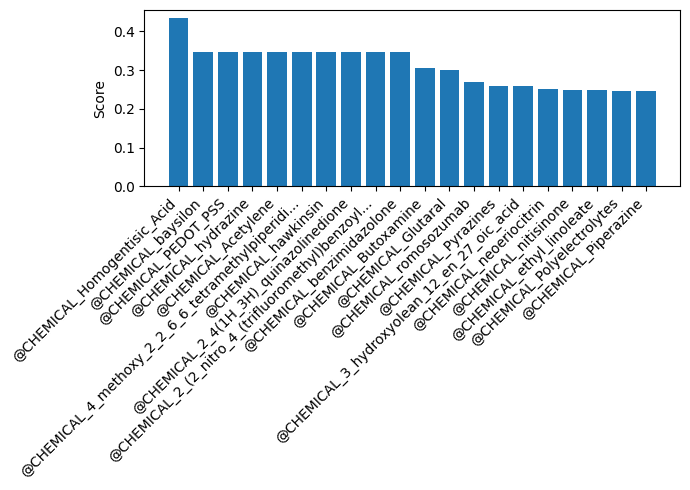

In [212]:
exhete = metapath_ana_visualize(extendGraph)

In [223]:
exhetegraph = build_topk_cgd_subgraph(
    extendGraph,
    disease='@DISEASE_Alkaptonuria',
    hetesim_scores=exhete,
    k=20,
    undirected=True
)

In [224]:
save_html_graph(exhetegraph, entity_color, relation_color, '../HTMLs/exHeteSimsubgraph.html')

Graph with legend saved to ../HTMLs/exHeteSimsubgraph.html


### High confidence graph

@CHEMICAL_Homogentisic_Acid 0.7217
@CHEMICAL_ethylbenzene 0.5785
@CHEMICAL_4_hydroxyphenylacetate 0.5762
@CHEMICAL_Phenylalanine 0.4153
@CHEMICAL_Tyrosine 0.2811
@CHEMICAL_nitisinone 0.0
@CHEMICAL_Ascorbic_Acid 0.0
@CHEMICAL_Acetylcysteine 0.0
@CHEMICAL_Dihematoporphyrin_Ether 0.0
@CHEMICAL_Argon 0.0
@CHEMICAL_Aminolevulinic_Acid 0.0
@CHEMICAL_Omeprazole 0.0
@CHEMICAL_Methylene_Blue 0.0
@CHEMICAL_Phosphorus 0.0
@CHEMICAL_Tocotrienols 0.0
@CHEMICAL_4_hydroxyphenylpyruvic_acid 0.0
@CHEMICAL_pyomelanin 0.0
@CHEMICAL_Melanins 0.0
@CHEMICAL_Amino_Acids_Aromatic 0.0
@CHEMICAL_succinylacetone 0.0
@CHEMICAL_geranylgeranyl_pyrophosphate 0.0
@CHEMICAL_Tocopherols 0.0
@CHEMICAL_phenylacetic_acid 0.0
@CHEMICAL_Plastoquinone 0.0
@CHEMICAL_quinone 0.0
@CHEMICAL_Reactive_Oxygen_Species 0.0
@CHEMICAL_Vitamin_E 0.0
@CHEMICAL_Hydrogen_Peroxide 0.0
@CHEMICAL_Creatinine 0.0
@CHEMICAL_phytyl_diphosphate 0.0
@CHEMICAL_Lugol's_solution 0.0
@CHEMICAL_Quercetin 0.0
@CHEMICAL_hesperetin 0.0
@CHEMICAL_nutlin_3 0

/var/folders/01/v0p4sfw945j32p3yvg67p6cc0000gn/T/ipykernel_27313/1665326467.py:148: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  sim = float((L_c @ R_d.T) / (l_norm * r_norm))  # cosine similarity


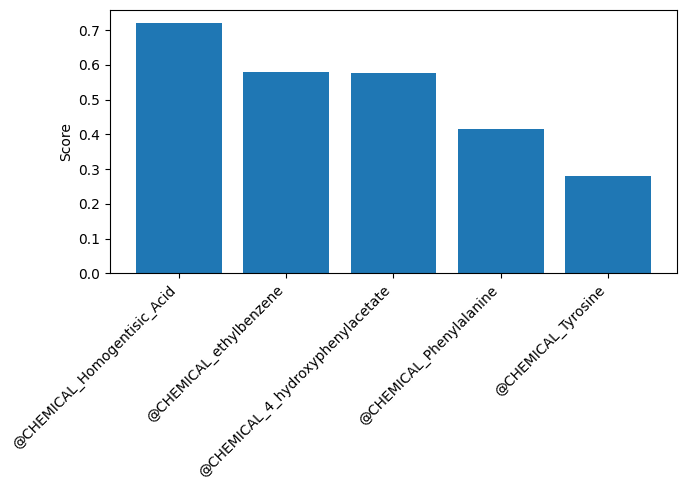

In [225]:
hihete = metapath_ana_visualize(highconfgraph, 5)

In [227]:
hihetegraph = build_topk_cgd_subgraph(
    highconfgraph,
    disease='@DISEASE_Alkaptonuria',
    hetesim_scores=hihete,
    k=20,
    undirected=True
)

In [228]:
save_html_graph(hihetegraph, entity_color, relation_color, '../HTMLs/hiHeteSimsubgraph.html')

Graph with legend saved to ../HTMLs/hiHeteSimsubgraph.html


## Disease Similarity 

### Define function

In [100]:
import math
import numpy as np
import networkx as nx
import scipy.sparse as sp
from sklearn.preprocessing import normalize
from sklearn.metrics.pairwise import cosine_similarity
from collections import defaultdict
from math import comb

# ---------- Helpers ----------

def _node_type(n):
    if isinstance(n, str):
        if n.startswith("@DISEASE"): return "disease"
        if n.startswith("@GENE"):    return "gene"
        if n.startswith("@CHEMICAL"):return "chemical"
    return None

def _collect_neighbors(G, node, kinds, in_edges=True, out_edges=True):
    """Return neighbors of specified kinds, respecting direction options."""
    neigh = []
    if G.is_directed():
        if in_edges:
            for u, v, data in G.in_edges(node, data=True):
                if _node_type(u) in kinds:
                    neigh.append((u, data))
        if out_edges:
            for u, v, data in G.out_edges(node, data=True):
                if _node_type(v) in kinds:
                    neigh.append((v, data))
    else:
        for nbr, data in G[node].items():
            if _node_type(nbr) in kinds:
                neigh.append((nbr, data))
    return neigh

def _build_incidence(G, diseases, items, item_kind,
                     in_edges=True, out_edges=True,
                     use_weights=False, signed=False):
    """Build D x I sparse matrix: rows=diseases, cols=items (genes or chemicals)."""
    d2i = {d:i for i,d in enumerate(diseases)}
    i2j = {it:j for j,it in enumerate(items)}
    rows, cols, vals = [], [], []

    for d in diseases:
        row = d2i[d]
        neigh = _collect_neighbors(G, d, {item_kind}, in_edges=in_edges, out_edges=out_edges)
        agg = defaultdict(float)
        for nbr, data in neigh:
            val = 1.0
            if use_weights and 'score' in data:
                # print("Use score")
                val = float(data['score'])
            if signed and 'sign' in data:
                s = data['sign']
                if isinstance(s, str):
                    s = 1.0 if s.lower().startswith('+') else -1.0
                val *= float(s)
            agg[nbr] += val
        for nbr, v in agg.items():
            if nbr in i2j:
                rows.append(row)
                cols.append(i2j[nbr])
                vals.append(v)

    mat = sp.coo_matrix((vals, (rows, cols)), shape=(len(diseases), len(items)))
    return mat.tocsr()

def _tfidf_rows(X):
    # L2 row-normalize (TF)
    X_tf = normalize(X, norm='l2', axis=1, copy=True)
    # IDF on columns
    df = np.asarray((X > 0).sum(axis=0)).ravel()
    idf = np.log((X.shape[0]) / (1.0 + df))
    return X_tf @ sp.diags(idf)

def _cosine_sim(X, tfidf=False):
    Xw = _tfidf_rows(X) if tfidf else normalize(X, norm='l2', axis=1, copy=True)
    return cosine_similarity(Xw, dense_output=False)  # sparse

def _pathsim(A):
    # A: D x I (weights allowed). M = A A^T
    M = (A @ A.T).tocsr()
    diag = M.diagonal()
    rows, cols = M.nonzero()
    data = M.data
    ps_vals = []
    for v, i, j in zip(data, rows, cols):
        denom = diag[i] + diag[j]
        ps_vals.append(0.0 if denom == 0 else 2.0 * v / denom)
    return sp.csr_matrix((ps_vals, (rows, cols)), shape=M.shape)

def _hypergeom_overlap(A):
    """
    Binary overlap significance (via items). A is D x I binary.
    Uses survival function approximation for moderate sizes.
    Weight = -log10(p-value). Non-overlapping pairs omitted (weight=0).
    """
    A_bin = A.copy().astype(bool).astype(int).tocsr()
    M = (A_bin @ A_bin.T).tocsr()  # pair overlaps
    n_items = A.shape[1]
    diag = A_bin.sum(axis=1).A1  # set sizes

    rows, cols = M.nonzero()
    ks = M.data
    vals = []
    for k, i, j in zip(ks, rows, cols):
        if i == j or k == 0:
            vals.append(0.0)
            continue
        Ki = diag[i]; Kj = diag[j]
        # compute P(X >= k) for Hypergeom(N=n_items, K=Ki, n=Kj)
        # naive sum of pmf tails; OK for typical sparse projections
        p = 0.0
        max_x = int(min(Ki, Kj))
        # guard small combinatorics; use logs if needed
        for x in range(k, max_x+1):
            num = comb(Ki, x) * comb(n_items - Ki, Kj - x)
            den = comb(n_items, Kj)
            p += num / den
        vals.append(0.0 if p <= 0 else -math.log10(p))
    return sp.csr_matrix((vals, (rows, cols)), shape=M.shape)

def _combine(mats, weights=None):
    mats = [m.tocsr() for m in mats if m is not None]
    if not mats: return None
    if weights is None:
        weights = [1.0/len(mats)]*len(mats)
    out = mats[0].multiply(weights[0])
    for m, w in zip(mats[1:], weights[1:]):
        out = out + m.multiply(w)
    return out

def _topk_per_row(S, k):
    if k is None: return S.tocsr()
    S = S.tolil()
    n = S.shape[0]
    for i in range(n):
        row = S.rows[i]; data = S.data[i]
        # drop self-loop
        for idx, j in enumerate(row):
            if j == i:
                row.pop(idx); data.pop(idx)
                break
        if len(row) > k:
            idxs = np.argpartition(data, -k)[-k:]
            keep = set(np.array(row)[idxs])
            mask = [j in keep for j in row]
            S.rows[i] = list(np.array(row)[mask])
            S.data[i] = list(np.array(data)[mask])
    return S.tocsr()

# ---------- Main entry ----------

def build_disease_similarity(
    G: nx.Graph,
    via=("gene","chemical"),                  # which channels to use
    method=("cosine_tfidf", "pathsim"),      # similarity methods to combine
    in_edges=True, out_edges=True,           # direction handling
    use_weights=True, signed=False,         # edge attributes: weight/sign
    weights_by_channel=None,                 # e.g., {"gene":0.6,"chemical":0.4}
    weights_by_method=None,                  # e.g., {"cosine_tfidf":0.5,"pathsim":0.5}
    hypergeom_binary=False,                  # if True, use hypergeometric for a channel (binary)
    topk=20                                  # keep top-k neighbors per disease (None to skip)
):
    """
    Returns:
      H (nx.Graph): disease–disease weighted similarity graph
      S (scipy.sparse.csr_matrix): similarity matrix aligned to disease order
      diseases (list): disease node order used in S
    """
    # collect nodes
    diseases = [n for n in G.nodes if _node_type(n) == "disease"]
    genes    = [n for n in G.nodes if _node_type(n) == "gene"]
    chems    = [n for n in G.nodes if _node_type(n) == "chemical"]

    if not diseases:
        raise ValueError("No @DISEASE nodes found.")
    if not genes and "gene" in via:
        via = tuple(x for x in via if x != "gene")
    if not chems and "chemical" in via:
        via = tuple(x for x in via if x != "chemical")
    if not via:
        raise ValueError("No projection channels available (no genes/chemicals present).")

    # default weights
    if weights_by_channel is None:
        weights_by_channel = {ch: 1.0/len(via) for ch in via}
    if weights_by_method is None:
        unique_methods = tuple(method) if isinstance(method, (list, tuple)) else (method,)
        weights_by_method = {m: 1.0/len(unique_methods) for m in unique_methods}

    # build per-channel similarity
    channel_sims = []
    for ch in via:
        if ch == "gene":
            A = _build_incidence(G, diseases, genes, "gene",
                                 in_edges, out_edges, use_weights, signed)
        elif ch == "chemical":
            A = _build_incidence(G, diseases, chems, "chemical",
                                 in_edges, out_edges, use_weights, signed)
        else:
            continue

        per_methods = []
        mlist = tuple(method) if isinstance(method, (list, tuple)) else (method,)

        for m in mlist:
            if m == "cosine":
                per_methods.append(_cosine_sim(A, tfidf=False))
            elif m == "cosine_tfidf":
                per_methods.append(_cosine_sim(A, tfidf=True))
            elif m == "pathsim":
                per_methods.append(_pathsim(A))
            elif m == "hypergeom":
                per_methods.append(_hypergeom_overlap(A))
            else:
                raise ValueError(f"Unknown method: {m}")

        # combine methods for this channel
        m_weights = [weights_by_method[m] for m in mlist]
        ch_sim = _combine(per_methods, m_weights)
        # optional: mark weight by channel
        channel_sims.append(ch_sim.multiply(weights_by_channel[ch]))

    # combine channels
    S = _combine(channel_sims, None)
    if S is None:
        raise RuntimeError("Could not build any similarity matrix.")

    # sparsify (top-k) and symmetrize to be safe
    S = _topk_per_row(S, topk)
    S = 0.5 * (S + S.T)

    # build NetworkX graph
    H = nx.Graph()
    H.add_nodes_from(diseases)
    rows, cols = S.nonzero()
    for i, j, w in zip(rows, cols, S.data):
        if i < j and w > 0:
            H.add_edge(diseases[i], diseases[j], weight=float(w))

    return H, S.tocsr(), diseases


In [101]:
import numpy as np
import scipy.sparse as sp
import matplotlib.pyplot as plt

def _find_disease_index(diseases, focal_name="Alkaptonuria"):
    # exact (case-insensitive)
    for i, d in enumerate(diseases):
        if d.lower() == focal_name.lower():
            return i
    # exact after stripping prefix
    for i, d in enumerate(diseases):
        if d.replace("@DISEASE:", "").lower() == focal_name.lower():
            return i
    # substring fallback
    cand = [i for i, d in enumerate(diseases)
            if focal_name.lower() in d.lower()
            or focal_name.lower() in d.replace("@DISEASE:", "").lower()]
    if len(cand) == 1:
        return cand[0]
    if cand:
        names = [diseases[i] for i in cand]
        raise ValueError(f"Ambiguous '{focal_name}'. Candidates: {names}")
    raise ValueError(f"'{focal_name}' not found in diseases list.")

def plot_top_similar_diseases_vertical(
    S,
    diseases,
    focal_name="Alkaptonuria",
    k=15,
    min_sim=None,
    exclude_self=True,
    annotate=True,
    rotation=45,          # <— rotate x tick labels
    figsize=(12, 6),
    save_path=None,
):
    n = len(diseases)
    i = _find_disease_index(diseases, focal_name)

    # pull similarity row
    if isinstance(S, np.ndarray):
        if S.shape != (n, n): raise ValueError("Dense S shape must be (n,n).")
        sims = S[i, :].astype(float).ravel()
    elif sp.isspmatrix(S):
        S = S.tocsr()
        if S.shape != (n, n): raise ValueError("Sparse S shape must be (n,n).")
        sims = np.full(n, -np.inf, dtype=float)
        row = S.getrow(i)
        sims[row.indices] = row.data
    else:
        raise TypeError("S must be a NumPy array or scipy.sparse matrix.")

    if exclude_self:
        sims[i] = -np.inf

    # optional threshold
    idxs = np.arange(n)
    if min_sim is not None:
        mask = np.isfinite(sims) & (sims >= float(min_sim))
        idxs, sims = idxs[mask], sims[mask]

    if len(idxs) == 0:
        raise ValueError("No similar diseases found with current filters.")

    # rank desc and take top-k
    order = np.argsort(sims)[::-1]
    if k is not None and k > 0:
        order = order[:k]
    top_idxs = idxs[order]
    top_vals = sims[order]
    top_names = [diseases[j].replace("@DISEASE:", "") for j in top_idxs]

    # vertical bars
    fig, ax = plt.subplots(figsize=figsize)
    x = np.arange(len(top_names))
    bars = ax.bar(x, top_vals)   # default style/colors

    ax.set_xticks(x)
    ax.set_xticklabels(top_names, rotation=rotation, ha="right")  # <— rotated ticks
    ax.set_ylabel("Similarity")
    ax.set_title(f"Top similar nodes to {focal_name}")
    ax.margins(x=0.01)

    if annotate:
        for xi, v in zip(x, top_vals):
            ax.text(xi, v, f"{v:.3f}", va="bottom", ha="center")

    fig.tight_layout()
    if save_path:
        fig.savefig(save_path, bbox_inches="tight", dpi=150)

    return fig, ax, list(zip(top_names, top_vals))


In [102]:
def find_sim_di_visual(graph, top_n=20):
    H, S, exdimaps = build_disease_similarity(graph)
    plot_top_similar_diseases_vertical(
    S,
    exdimaps,
    focal_name="@DISEASE_Alkaptonuria",
    k=top_n,
    min_sim=None,
    exclude_self=True,
    annotate=True,
    figsize=(9, 6),
    save_path=None,
)

### Extend network

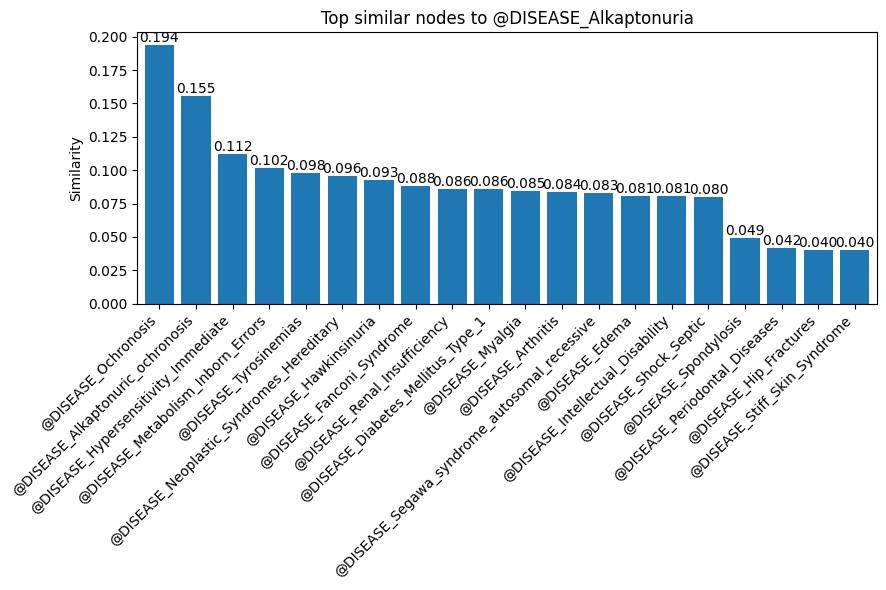

In [103]:
find_sim_di_visual(extendGraph)

### High confidence network

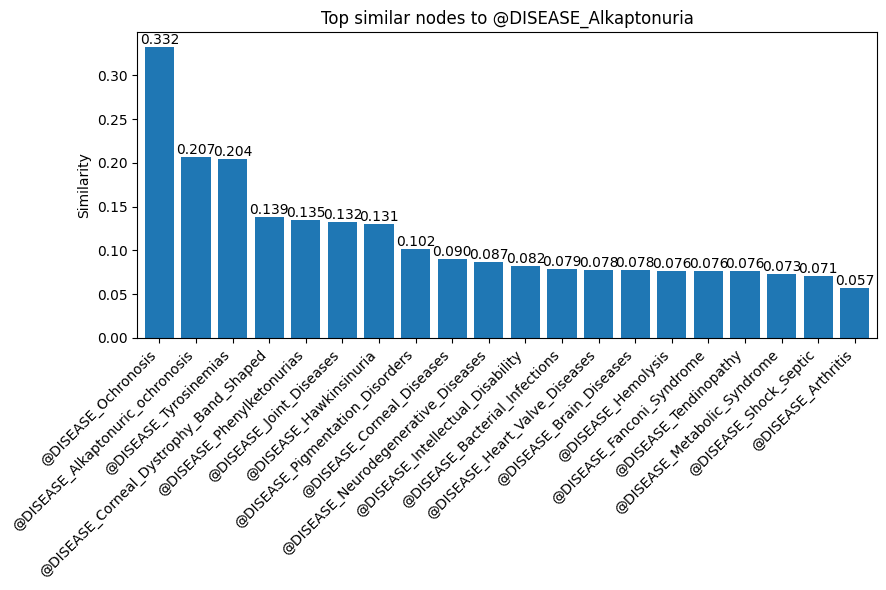

In [104]:
find_sim_di_visual(highconfgraph)

## Chemical similarity

### Define functions 

In [105]:
import networkx as nx
import scipy.sparse as sp

def build_chemical_similarity(
    G: nx.Graph,
    via=("gene","disease"),               # channels: C–G–C and/or C–D–C
    method=("cosine_tfidf", "pathsim"),   # combine similarity methods
    in_edges=True, out_edges=True,        # respect edge direction if G is directed
    use_weights=False, signed=False,      # use edge['weight'] / edge['sign'] if present
    weights_by_channel=None,              # e.g., {"gene":0.6,"disease":0.4}
    weights_by_method=None,               # e.g., {"cosine_tfidf":0.5,"pathsim":0.5}
    topk=20                               # keep top-k neighbors per chemical (None to skip)
):
    """
    Project a heterogeneous graph into a Chemical–Chemical similarity network.

    Returns:
      Hc (nx.Graph): chemical–chemical weighted similarity graph
      S (scipy.sparse.csr_matrix): similarity matrix aligned to `chemicals` order
      chemicals (list): chemical node order used in S
    """
    # Collect node sets by prefix/type
    chemicals = [n for n in G.nodes if _node_type(n) == "chemical"]
    genes     = [n for n in G.nodes if _node_type(n) == "gene"]
    diseases  = [n for n in G.nodes if _node_type(n) == "disease"]

    if not chemicals:
        raise ValueError("No @CHEMICAL nodes found.")

    # Prune unavailable channels
    via = tuple(via)
    if "gene" in via and not genes:
        via = tuple(x for x in via if x != "gene")
    if "disease" in via and not diseases:
        via = tuple(x for x in via if x != "disease")
    if not via:
        raise ValueError("No projection channels available (no genes/diseases present).")

    # Default weights
    if weights_by_channel is None:
        weights_by_channel = {ch: 1.0/len(via) for ch in via}
    mlist = tuple(method) if isinstance(method, (list, tuple)) else (method,)
    if weights_by_method is None:
        weights_by_method = {m: 1.0/len(mlist) for m in mlist}

    # Build per-channel similarity
    channel_sims = []
    for ch in via:
        if ch == "gene":
            # C x G incidence
            A = _build_incidence(G, chemicals, genes, "gene",
                                 in_edges=in_edges, out_edges=out_edges,
                                 use_weights=use_weights, signed=signed)
        elif ch == "disease":
            # C x D incidence
            A = _build_incidence(G, chemicals, diseases, "disease",
                                 in_edges=in_edges, out_edges=out_edges,
                                 use_weights=use_weights, signed=signed)
        else:
            raise ValueError(f"Unknown channel: {ch}")

        # Methods for this channel
        per_methods = []
        for m in mlist:
            if m == "cosine":
                per_methods.append(_cosine_sim(A, tfidf=False))
            elif m == "cosine_tfidf":
                per_methods.append(_cosine_sim(A, tfidf=True))
            elif m == "pathsim":
                per_methods.append(_pathsim(A))
            elif m == "hypergeom":
                per_methods.append(_hypergeom_overlap(A))
            else:
                raise ValueError(f"Unknown method: {m}")

        # Combine methods within channel
        m_weights = [weights_by_method[m] for m in mlist]
        ch_sim = _combine(per_methods, m_weights).multiply(weights_by_channel[ch])
        channel_sims.append(ch_sim)

    # Combine channels
    S = _combine(channel_sims, None)
    if S is None:
        raise RuntimeError("Failed to build any similarity matrix.")

    # Sparsify (top-k per row) and symmetrize
    S = _topk_per_row(S, topk)
    S = 0.5 * (S + S.T)

    # Build NetworkX graph
    Hc = nx.Graph()
    Hc.add_nodes_from(chemicals)
    rows, cols = S.nonzero()
    for i, j, w in zip(rows, cols, S.data):
        if i < j and w > 0:
            Hc.add_edge(chemicals[i], chemicals[j], weight=float(w))

    return Hc, S.tocsr(), chemicals


In [106]:
def find_sim_chem_visual(graph, top_n=20):
    Hc, Sc, chemicals = build_chemical_similarity(
    graph,
    via=("gene","disease"),
    method=("cosine_tfidf","pathsim"),
    in_edges=True, out_edges=True,
    use_weights=True, signed=True,
    topk=25
    )
    plot_top_similar_diseases_vertical(
    Sc,
    chemicals,
    focal_name="@CHEMICAL_nitisinone",
    k=top_n,
    min_sim=None,
    exclude_self=True,
    annotate=True,
    figsize=(9, 7),
    save_path=None,
    )
    

### Extended graph

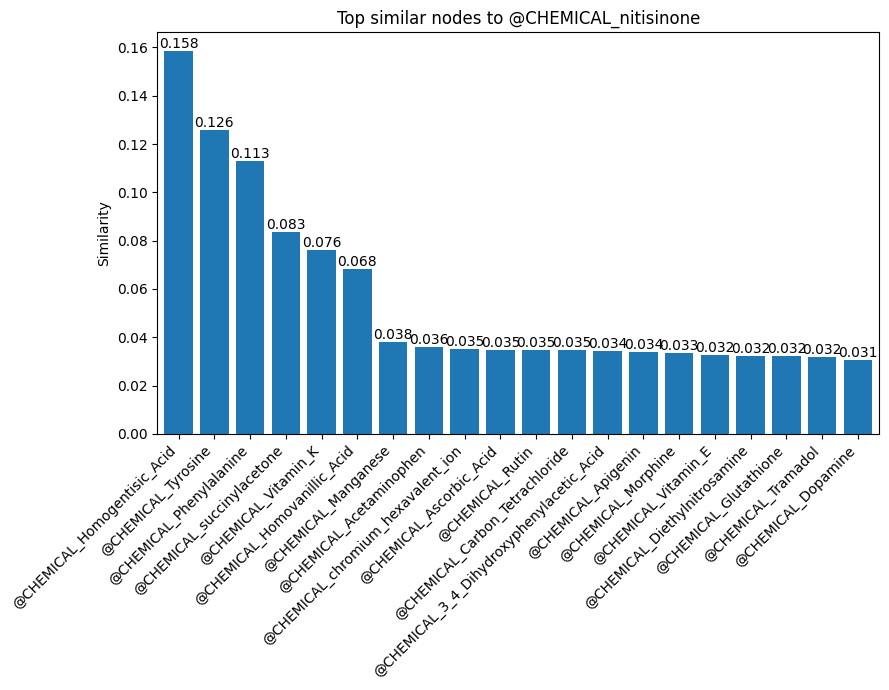

In [107]:
find_sim_chem_visual(extendGraph)

### High confidence graph

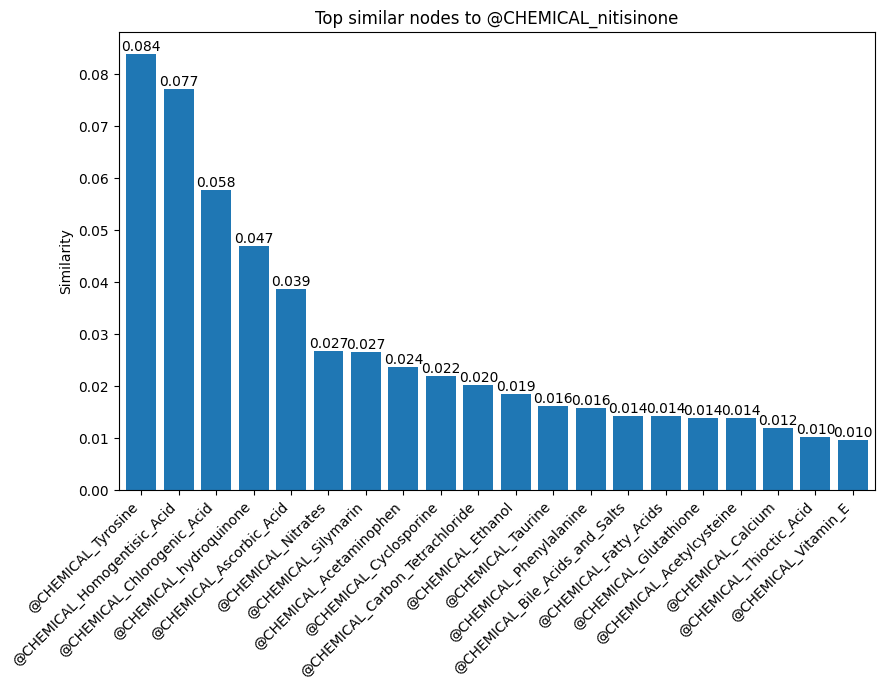

In [108]:
find_sim_chem_visual(highconfgraph)